# Integrated PFAS toxicogenomics analysis

This notebook connects data provenance, reconstruction of the initial analytical approach,
methodological correction, uncertainty-aware module discovery, functional interpretation,
backend-independent workflow classification, and evidence-grounded analysis planning. The ten
canonical edgeR result tables are the only inputs to biological inference. Synthetic workflow
requests verify software behavior and never enter PFAS conclusions.

Decisions remain traceable to source files, executed cells, versioned artifacts, and explicit
status fields. Human scientific review is required before an accepted plan is executed or an
exploratory association is reported as a conclusion.

## 1. Research Context and Analytical Objectives

The study asks which transcriptional responses are shared across ten PFAS exposures and which
are condition-associated in *C. elegans*. The analytical contract uses the measured 13,852-gene
universe, preserves continuous effect sizes, separates detection thresholds from magnitudes,
and quantifies optimizer and resampling uncertainty separately. The multi-fit consensus is the
recommended module assignment. Raw five-module percentage correlations are not valid evidence
of chemical similarity. Corrected residual pair tests control BH FDR across 45 pairs separately
at each tested k, but remain exploratory because clustering uncertainty and external validation
are unresolved.

## 2. Reproducible Environment and Data Provenance

The setup resolves project paths, records the runtime, and verifies all ten canonical DGE tables
before analysis begins. This is the single execution notebook. Maintained helper modules, input data,
and generated outputs stay mapped to their project locations so the notebook does not duplicate or
silently diverge from tested source code.

| Role | Mapped location relative to `K-spaces Analysis` |
|---|---|
| Ten canonical edgeR inputs | `../Data/DEGs/{CHEM}vsControl_DGE_results.csv` |
| Scientific helper code | `src/pfas_master/` |
| Workflow and RAG code | `../integrated_system/src/pfas_workflow/` and `../integrated_system/llm_system/` |
| Tables and gene lists | `output/` |
| Figures, trees, and UpSet plots | `output/figures/` |

Launch Jupyter from the repository root or the `K-spaces Analysis` directory. If a different
working directory is required, set `PFAS_KSPACES_DIR` to the repository's analysis directory.

In [1]:
from pathlib import Path
import hashlib, json, os, platform, subprocess, sys
import pandas as pd

configured_root = os.environ.get('PFAS_KSPACES_DIR')
candidates = [
    Path(configured_root).expanduser() if configured_root else None,
    Path.cwd().resolve(),
    Path.cwd().resolve() / 'K-spaces Analysis',
    Path.cwd().resolve().parent / 'K-spaces Analysis',
]
ROOT = next((path.resolve() for path in candidates if path and (path / 'build_notebook.py').exists()), None)
if ROOT is None:
    raise RuntimeError(
        'Set PFAS_KSPACES_DIR to the K-spaces Analysis folder that contains build_notebook.py'
    )
PROJECT = ROOT.parent
SYSTEM_ROOT = PROJECT / 'integrated_system'
for required in (ROOT / 'src', SYSTEM_ROOT, SYSTEM_ROOT / 'src'):
    if str(required) not in sys.path:
        sys.path.insert(0, str(required))

environment = {
    'python': platform.python_version(),
    'analysis_root': str(ROOT),
    'system_root': str(SYSTEM_ROOT),
    'canonical_builder_sha256': hashlib.sha256((ROOT / 'build_notebook.py').read_bytes()).hexdigest(),
}
display(pd.Series(environment, name='value').to_frame())

,value
python,3.13.14
analysis_root,${HOME}/Documents/pfas-toxicogen...
system_root,${HOME}/Documents/pfas-toxicogen...
canonical_builder_sha256,38ea48856c5e62d5375672c1ec07ddbc186b552bec3cf4...


### Setup

In [2]:

import warnings
warnings.filterwarnings("ignore")

import os
import io
import contextlib
import time
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Image

import kspaces
from importlib.metadata import version
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

# kspaces draws its EM initializations from numpy's *global* RNG state (not a
# seeded Generator), so this notebook is only reproducible run-to-run if that
# global state is fixed once, up front, before any kspaces call.
GLOBAL_SEED = 0
np.random.seed(GLOBAL_SEED)

# Set PFAS_KSPACES_DIR if Jupyter is launched from another directory.
# Otherwise, launch Jupyter from the folder containing this notebook.
ROOT = Path(os.environ.get("PFAS_KSPACES_DIR", Path.cwd())).expanduser().resolve()
PROJECT_DIR = ROOT.parent
DEGS_DIR = PROJECT_DIR / "Data" / "DEGs"
EXT_DIR = ROOT / "data_external"
FIG_DIR = ROOT / "output" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CHEMICALS = ["PFOSA", "PFBSA", "PFOS", "PFNA", "PFOA", "GenX", "PFEESA", "PFBS", "PFPeA", "PFBA"]
FDR_THRESHOLD = 0.05

FILE_MAP = {
    "notebook_directory": ROOT,
    "dge_inputs": DEGS_DIR,
    "go_annotation": EXT_DIR / "wb.gaf",
    "go_ontology": EXT_DIR / "go-basic.obo",
    "generated_outputs": ROOT / "output",
}
print("File map:")
for label, path in FILE_MAP.items():
    print(f"  {label:20s} -> {path}")

missing_dge = [DEGS_DIR / f"{chem}vsControl_DGE_results.csv" for chem in CHEMICALS
               if not (DEGS_DIR / f"{chem}vsControl_DGE_results.csv").exists()]
if missing_dge:
    raise FileNotFoundError(
        "Missing DGE inputs. Launch Jupyter from the K-spaces Analysis directory "
        "or set PFAS_KSPACES_DIR to that directory. Missing: "
        + ", ".join(str(path) for path in missing_dge)
    )
print("kspaces version:", version("kspaces"))


File map:
  notebook_directory   -> ${REPO_ROOT}/K-spaces Analysis
  dge_inputs           -> ${REPO_ROOT}/Data/DEGs
  go_annotation        -> ${REPO_ROOT}/K-spaces Analysis/data_external/wb.gaf
  go_ontology          -> ${REPO_ROOT}/K-spaces Analysis/data_external/go-basic.obo
  generated_outputs    -> ${REPO_ROOT}/K-spaces Analysis/output
kspaces version: 0.1.5


### Build the gene x chemical matrix

**Input:** `Data/DEGs/{CHEM}vsControl_DGE_results.csv` : 10 files, one per
PFAS chemical, each the output of an edgeR `glmQLFTest` (columns: gene id,
`logFC`, `logCPM`, `F`, `PValue`, `FDR`). All 10 files were confirmed to
share the identical 13,852-gene filtered universe (CPM > 1 in >= 4 samples),
so they merge cleanly on gene id.


In [3]:

def load_chemical(chem: str) -> pd.DataFrame:
    path = DEGS_DIR / f"{chem}vsControl_DGE_results.csv"
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.str.strip('"').rename("WB_id")
    return df[["logFC", "FDR"]].rename(columns={"logFC": f"logFC_{chem}", "FDR": f"FDR_{chem}"})

frames = [load_chemical(c) for c in CHEMICALS]
merged = frames[0]
for f in frames[1:]:
    merged = merged.join(f, how="inner")

assert len(merged) == 13852, f"expected 13852 shared genes, got {len(merged)}"
for c in CHEMICALS:
    assert not merged[f"logFC_{c}"].isna().any(), f"unexpected NaNs in {c}"

print(f"merged_wide: {merged.shape[0]} genes x {len(CHEMICALS)} chemicals (logFC + FDR columns)")
merged.to_csv(ROOT / "output" / "merged_wide.csv")
merged.head()


merged_wide: 13852 genes x 10 chemicals (logFC + FDR columns)


,logFC_PFOSA,FDR_PFOSA,logFC_PFBSA,FDR_PFBSA,logFC_PFOS,FDR_PFOS,logFC_PFNA,FDR_PFNA,logFC_PFOA,FDR_PFOA,logFC_GenX,FDR_GenX,logFC_PFEESA,FDR_PFEESA,logFC_PFBS,FDR_PFBS,logFC_PFPeA,FDR_PFPeA,logFC_PFBA,FDR_PFBA
WB_id,,,,,,,,,,,,,,,,,,,,
WBGene00011673,8.706907,2.128197e-27,8.362001,3.816196e-27,8.698914,2.193311e-27,8.913629,1.025083e-27,6.529083,3.135595e-23,7.264106,2.326435e-25,8.694606,2.223639e-27,9.120432,5.051551e-28,9.617673,5.138015e-29,7.115824,1.560587e-24
WBGene00011671,9.750385,1.820361e-24,8.119626,6.107268e-22,8.285340,5.171087e-22,7.620013,1.224422e-20,6.526454,2.595378e-17,8.942970,1.958956e-22,8.922419,1.487758e-23,8.745629,4.513882e-23,9.850984,3.069510e-25,4.388902,6.013669e-10
WBGene00007231,6.160456,1.837755e-24,1.174566,2.861979e-03,0.824469,3.447046e-01,0.846384,1.823454e-01,0.674507,7.890250e-01,0.166363,9.460874e-01,0.944873,3.853222e-02,0.409201,5.864970e-01,1.530656,1.961543e-05,0.077572,9.990773e-01
WBGene00010413,9.056009,7.527532e-24,1.641036,5.832392e-01,2.417996,9.991393e-01,3.511913,2.419808e-01,2.853517,9.080502e-01,-0.099747,9.936718e-01,1.865912,6.447897e-01,0.059007,9.928055e-01,4.132850,3.922387e-03,0.805234,9.990773e-01
WBGene00044514,7.487190,1.156561e-23,0.286541,7.636255e-01,2.063619,1.091992e-03,5.170614,3.248471e-17,4.483889,2.108326e-14,-0.139034,9.789474e-01,-0.243875,8.820507e-01,-0.567480,7.168806e-01,0.277838,6.977547e-01,-0.850933,9.576105e-01


**Sanity check** : DEG counts per chemical (FDR < 0.05) against the numbers reported in `Data/Initial RNA-seqy Analysis_Plots.docx`:

In [4]:

deg_counts = pd.DataFrame([
    {"chemical": c, "n_DEGs_FDR0.05": int((merged[f"FDR_{c}"] < FDR_THRESHOLD).sum())}
    for c in CHEMICALS
]).sort_values("n_DEGs_FDR0.05", ascending=False).reset_index(drop=True)
deg_counts.to_csv(ROOT / "output" / "deg_counts.csv", index=False)
display(deg_counts)


,chemical,n_DEGs_FDR0.05
0,PFOSA,9161
1,PFPeA,5997
2,PFBSA,2601
3,PFEESA,1038
4,PFBS,716
5,GenX,446
6,PFNA,357
7,PFOS,190
8,PFBA,184
9,PFOA,154


## 3. Data Integrity and Quality Assessment

Quality control distinguishes the complete measured universe from threshold-defined detection
sets. Continuous log-fold changes feed module discovery. The initial zero-masked matrix is
reconstructed only to expose ties introduced when non-significance was treated as zero effect.

### Gene selection strategy

The number of DEGs ranges from 154 (PFOA) to 9,161 (PFOSA) : nearly a
60-fold spread. Feeding raw log2 fold-changes into k-spaces as-is lets the
highest-DEG-count chemicals dominate module discovery purely by magnitude.

**Primary strategy (proposed default):** restrict to the union of genes DE
(FDR<0.05) in >= 1 chemical, retain each chemical's continuous logFC, then
z-score each gene's row across the 10 chemicals. This captures response
*shape* without replacing measured effect-size spacing with ranks.

**Sensitivity variants** (run later in this notebook, per the planning
document's own suggestion): signed within-chemical percentile ranks followed
by row z-scoring, and top-N-per-chemical gene selection for N in {500, 1000}.


In [5]:

def zscore_rows(df: pd.DataFrame) -> pd.DataFrame:
    mean = df.mean(axis=1)
    sd = df.std(axis=1, ddof=0).replace(0, np.nan)
    return df.sub(mean, axis=0).div(sd, axis=0)

logfc = merged[[f"logFC_{c}" for c in CHEMICALS]].rename(columns=lambda x: x.replace("logFC_", ""))
fdr = merged[[f"FDR_{c}" for c in CHEMICALS]].rename(columns=lambda x: x.replace("FDR_", ""))
de_union_idx = fdr.index[(fdr < FDR_THRESHOLD).any(axis=1)]
print(f"DE union (FDR<0.05 in >=1 chemical): {len(de_union_idx)} genes")

sub = logfc.loc[de_union_idx]
matrix_primary = zscore_rows(sub).dropna()
matrix_primary.to_csv(ROOT / "output" / "matrix_primary_zlogfc.csv")

pct = sub.rank(pct=True, method="average")
matrix_sens_pctrank = zscore_rows(pct).dropna()
matrix_sens_pctrank.to_csv(ROOT / "output" / "matrix_sensitivity_pctrank.csv")

def build_topn_variant(n: int) -> pd.DataFrame:
    genes = set()
    for c in CHEMICALS:
        s = merged[[f"FDR_{c}", f"logFC_{c}"]].copy()
        s["abs_logFC"] = s[f"logFC_{c}"].abs()
        top = s.sort_values([f"FDR_{c}", "abs_logFC"], ascending=[True, False]).head(n)
        genes.update(top.index)
    idx = pd.Index(sorted(genes))
    return zscore_rows(logfc.loc[idx]).dropna()

matrix_top500 = build_topn_variant(500)
matrix_top1000 = build_topn_variant(1000)
matrix_top500.to_csv(ROOT / "output" / "matrix_topN_500.csv")
matrix_top1000.to_csv(ROOT / "output" / "matrix_topN_1000.csv")

print(f"matrix_primary (continuous row-z-logFC): {matrix_primary.shape}")
print(f"matrix_sens_pctrank (rank sensitivity):  {matrix_sens_pctrank.shape}")
print(f"matrix_top500:                          {matrix_top500.shape}")
print(f"matrix_top1000:                         {matrix_top1000.shape}")
matrix_primary.head()


DE union (FDR<0.05 in >=1 chemical): 10255 genes


matrix_primary (continuous row-z-logFC): (10255, 10)
matrix_sens_pctrank (rank sensitivity):  (10255, 10)
matrix_top500:                          (2331, 10)
matrix_top1000:                         (4562, 10)


,PFOSA,PFBSA,PFOS,PFNA,PFOA,GenX,PFEESA,PFBS,PFPeA,PFBA
WB_id,,,,,,,,,,
WBGene00011673,0.429307,0.063330,0.420826,0.648659,-1.881569,-1.101640,0.416255,0.868097,1.395716,-1.258981
WBGene00011671,1.053168,0.002804,0.109540,-0.318994,-1.023350,0.533116,0.519879,0.406010,1.117963,-2.400136
WBGene00007231,2.905135,-0.063311,-0.271748,-0.258700,-0.361031,-0.663564,-0.200063,-0.518986,0.148694,-0.716427
WBGene00010413,2.554779,-0.390602,-0.081977,0.352549,0.091021,-1.082077,-0.301276,-1.019016,0.599198,-0.722599
WBGene00044514,2.062006,-0.547284,0.096674,1.222551,0.973703,-0.701499,-0.739490,-0.856754,-0.550438,-0.959469


In [6]:
from pfas_master.science import (
    build_detection_evidence,
    build_legacy_zero_masked_matrix,
    load_and_validate_dge,
)
dge_frames, provenance = load_and_validate_dge(PROJECT / 'Data' / 'DEGs')
assert provenance['rows'].eq(13852).all()
evidence, threshold_sensitivity = build_detection_evidence(dge_frames)
legacy_matrix, legacy_diagnostics = build_legacy_zero_masked_matrix(dge_frames)
display(provenance)
display(threshold_sensitivity)
display(legacy_diagnostics)

,chemical,path,rows,sha256
0,PFOSA,${HOME}/Documents/pfas-toxicogen...,13852,c4172e1238c6eeea06db48148756ab402e9f10251655f2...
1,PFBSA,${HOME}/Documents/pfas-toxicogen...,13852,921a11ebb11b148b3dff2498836b15eacfae0a33f73cd3...
2,PFOS,${HOME}/Documents/pfas-toxicogen...,13852,b538146b1da3ce8978a2121212988049e03fe4197da5ec...
3,PFNA,${HOME}/Documents/pfas-toxicogen...,13852,bf01fed8bdc73e31f1d7524a18d9fd69c1b7a7e4512a6c...
4,PFOA,${HOME}/Documents/pfas-toxicogen...,13852,406d5bc5ec3d91db5e8e0b939c9aa1445b680f3b63f87b...
5,GenX,${HOME}/Documents/pfas-toxicogen...,13852,afd9a67684a684920d384ade5fb7c1283dad7282fa1345...
6,PFEESA,${HOME}/Documents/pfas-toxicogen...,13852,4465b95f24b370e6ba9b08a3a39ae13f7f756de5153382...
7,PFBS,${HOME}/Documents/pfas-toxicogen...,13852,b2b67bb39f8138acdef5ca95a4a8f04c4f084c5428f05b...
8,PFPeA,${HOME}/Documents/pfas-toxicogen...,13852,6127f10646bd43bce41d21f3e8e5ab8c1ff125306ee245...
9,PFBA,${HOME}/Documents/pfas-toxicogen...,13852,e083f2cdfdc4c0a9142797da0e6ac43a014b63bd1542dc...


,fdr_threshold,detected_union,detected_exclusively_one,detected_all_10
0,0.01,8757,4481,21
1,0.05,10255,4225,29
2,0.10,11034,3897,30


,chemical,genes,forced_zero_fraction,nonzero_effects_forced_to_zero,zero_tie_size
0,PFOSA,5520,0.150725,832,832
1,PFBSA,5520,0.528804,2919,2919
2,PFOS,5520,0.965580,5330,5330
3,PFNA,5520,0.935326,5163,5163
4,PFOA,5520,0.972101,5366,5366
5,GenX,5520,0.919203,5074,5074
6,PFEESA,5520,0.811957,4482,4482
7,PFBS,5520,0.870290,4804,4804
8,PFPeA,5520,0.257428,1421,1421
9,PFBA,5520,0.966667,5336,5336


### Exact DEG intersections and per-chemical detection composition

The original UpSet and unique-versus-shared analyses asked useful questions, but their categories
depend on the FDR threshold. The corrected version preserves all continuous effects in the primary
matrix and uses FDR below 0.05 only to describe exact detection intersections. “Exclusive” means
detected in exactly one of these ten contrasts; it does not mean biologically absent elsewhere.

,chemical,detected_total,detected_exclusively_here,detected_and_shared
0,PFOSA,9161,3541,5620
1,PFBSA,2601,164,2437
2,PFOS,190,0,190
3,PFNA,357,5,352
4,PFOA,154,0,154
5,GenX,446,9,437
6,PFEESA,1038,22,1016
7,PFBS,716,19,697
8,PFPeA,5997,463,5534
9,PFBA,184,2,182


,chemical_a,chemical_b,overlap_genes,jaccard,overlap_coefficient,concordant_sign_pct,fisher_odds_ratio,p_raw,q_bh_45_pairs
0,PFOSA,PFPeA,5177,0.518686,0.863265,95.615221,6.134344,0.000000e+00,0.000000e+00
1,PFBSA,PFPeA,2076,0.318307,0.798155,96.772640,7.392225,0.000000e+00,0.000000e+00
2,PFEESA,PFBS,429,0.323774,0.599162,98.601399,30.747172,9.881313e-324,1.482197e-322
3,PFOS,PFNA,167,0.439474,0.878947,100.000000,514.833867,1.023606e-256,1.151557e-255
4,GenX,PFBS,264,0.293987,0.591928,98.106061,41.571720,1.114313e-236,1.002882e-235
5,PFNA,PFEESA,267,0.236702,0.747899,98.876404,48.959620,1.926145e-232,1.444609e-231
6,PFNA,PFBS,239,0.286571,0.669468,98.326360,55.276658,1.093184e-231,7.027611e-231
7,GenX,PFEESA,277,0.229495,0.621076,98.194946,27.234991,5.283435e-206,2.971932e-205
8,PFEESA,PFPeA,904,0.147447,0.870906,99.225664,10.227359,9.527793e-205,4.763897e-204
9,PFBSA,PFEESA,605,0.199407,0.582852,97.851240,7.572755,4.091338e-194,1.841102e-193


,PFOSA,PFBSA,PFOS,PFNA,PFOA,GenX,PFEESA,PFBS,PFPeA,PFBA,gene_count,degree,intersection
0,True,False,False,False,False,False,False,False,False,False,3541,1,PFOSA
1,True,False,False,False,False,False,False,False,True,False,2910,2,PFOSA & PFPeA
2,True,True,False,False,False,False,False,False,True,False,1265,3,PFOSA & PFBSA & PFPeA
3,False,False,False,False,False,False,False,False,True,False,463,1,PFPeA
4,True,True,False,False,False,False,False,False,False,False,265,2,PFOSA & PFBSA
5,False,True,False,False,False,False,False,False,False,False,164,1,PFBSA
6,True,True,False,False,False,False,True,False,True,False,155,4,PFOSA & PFBSA & PFEESA & PFPeA
7,True,False,False,False,False,False,True,False,True,False,150,3,PFOSA & PFEESA & PFPeA
8,False,True,False,False,False,False,False,False,True,False,94,2,PFBSA & PFPeA
9,False,True,False,False,False,False,True,False,True,False,72,3,PFBSA & PFEESA & PFPeA


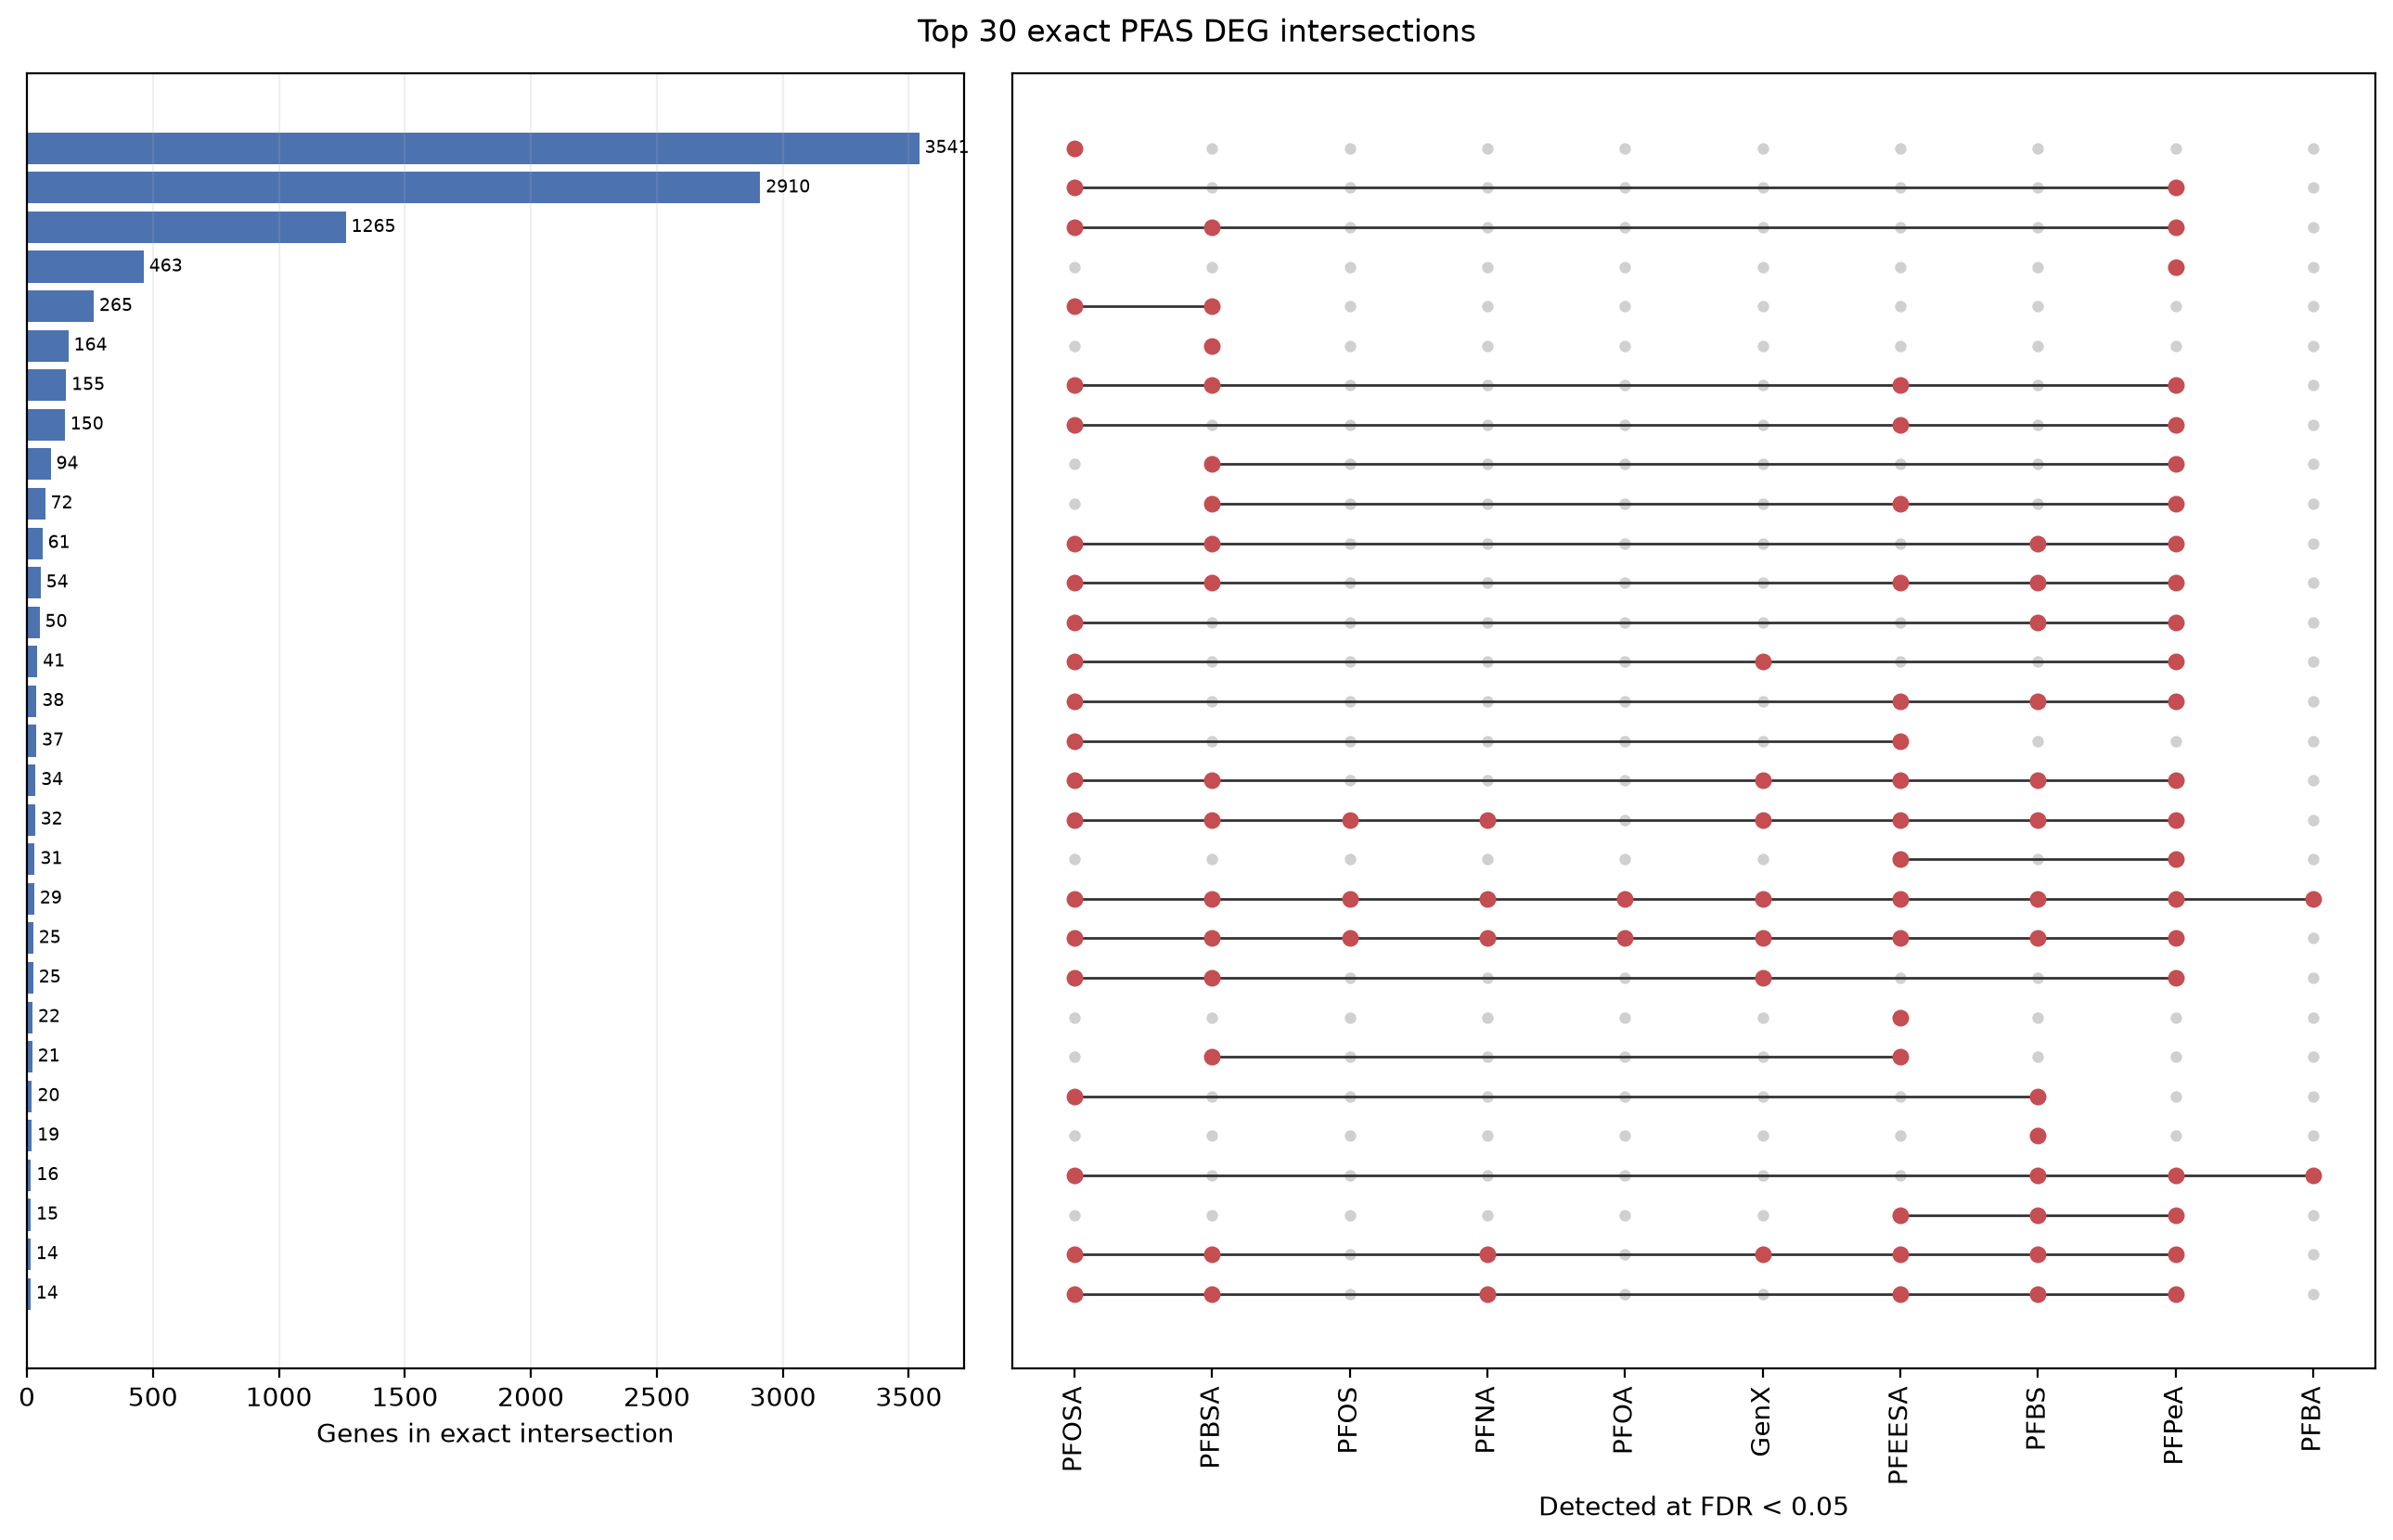

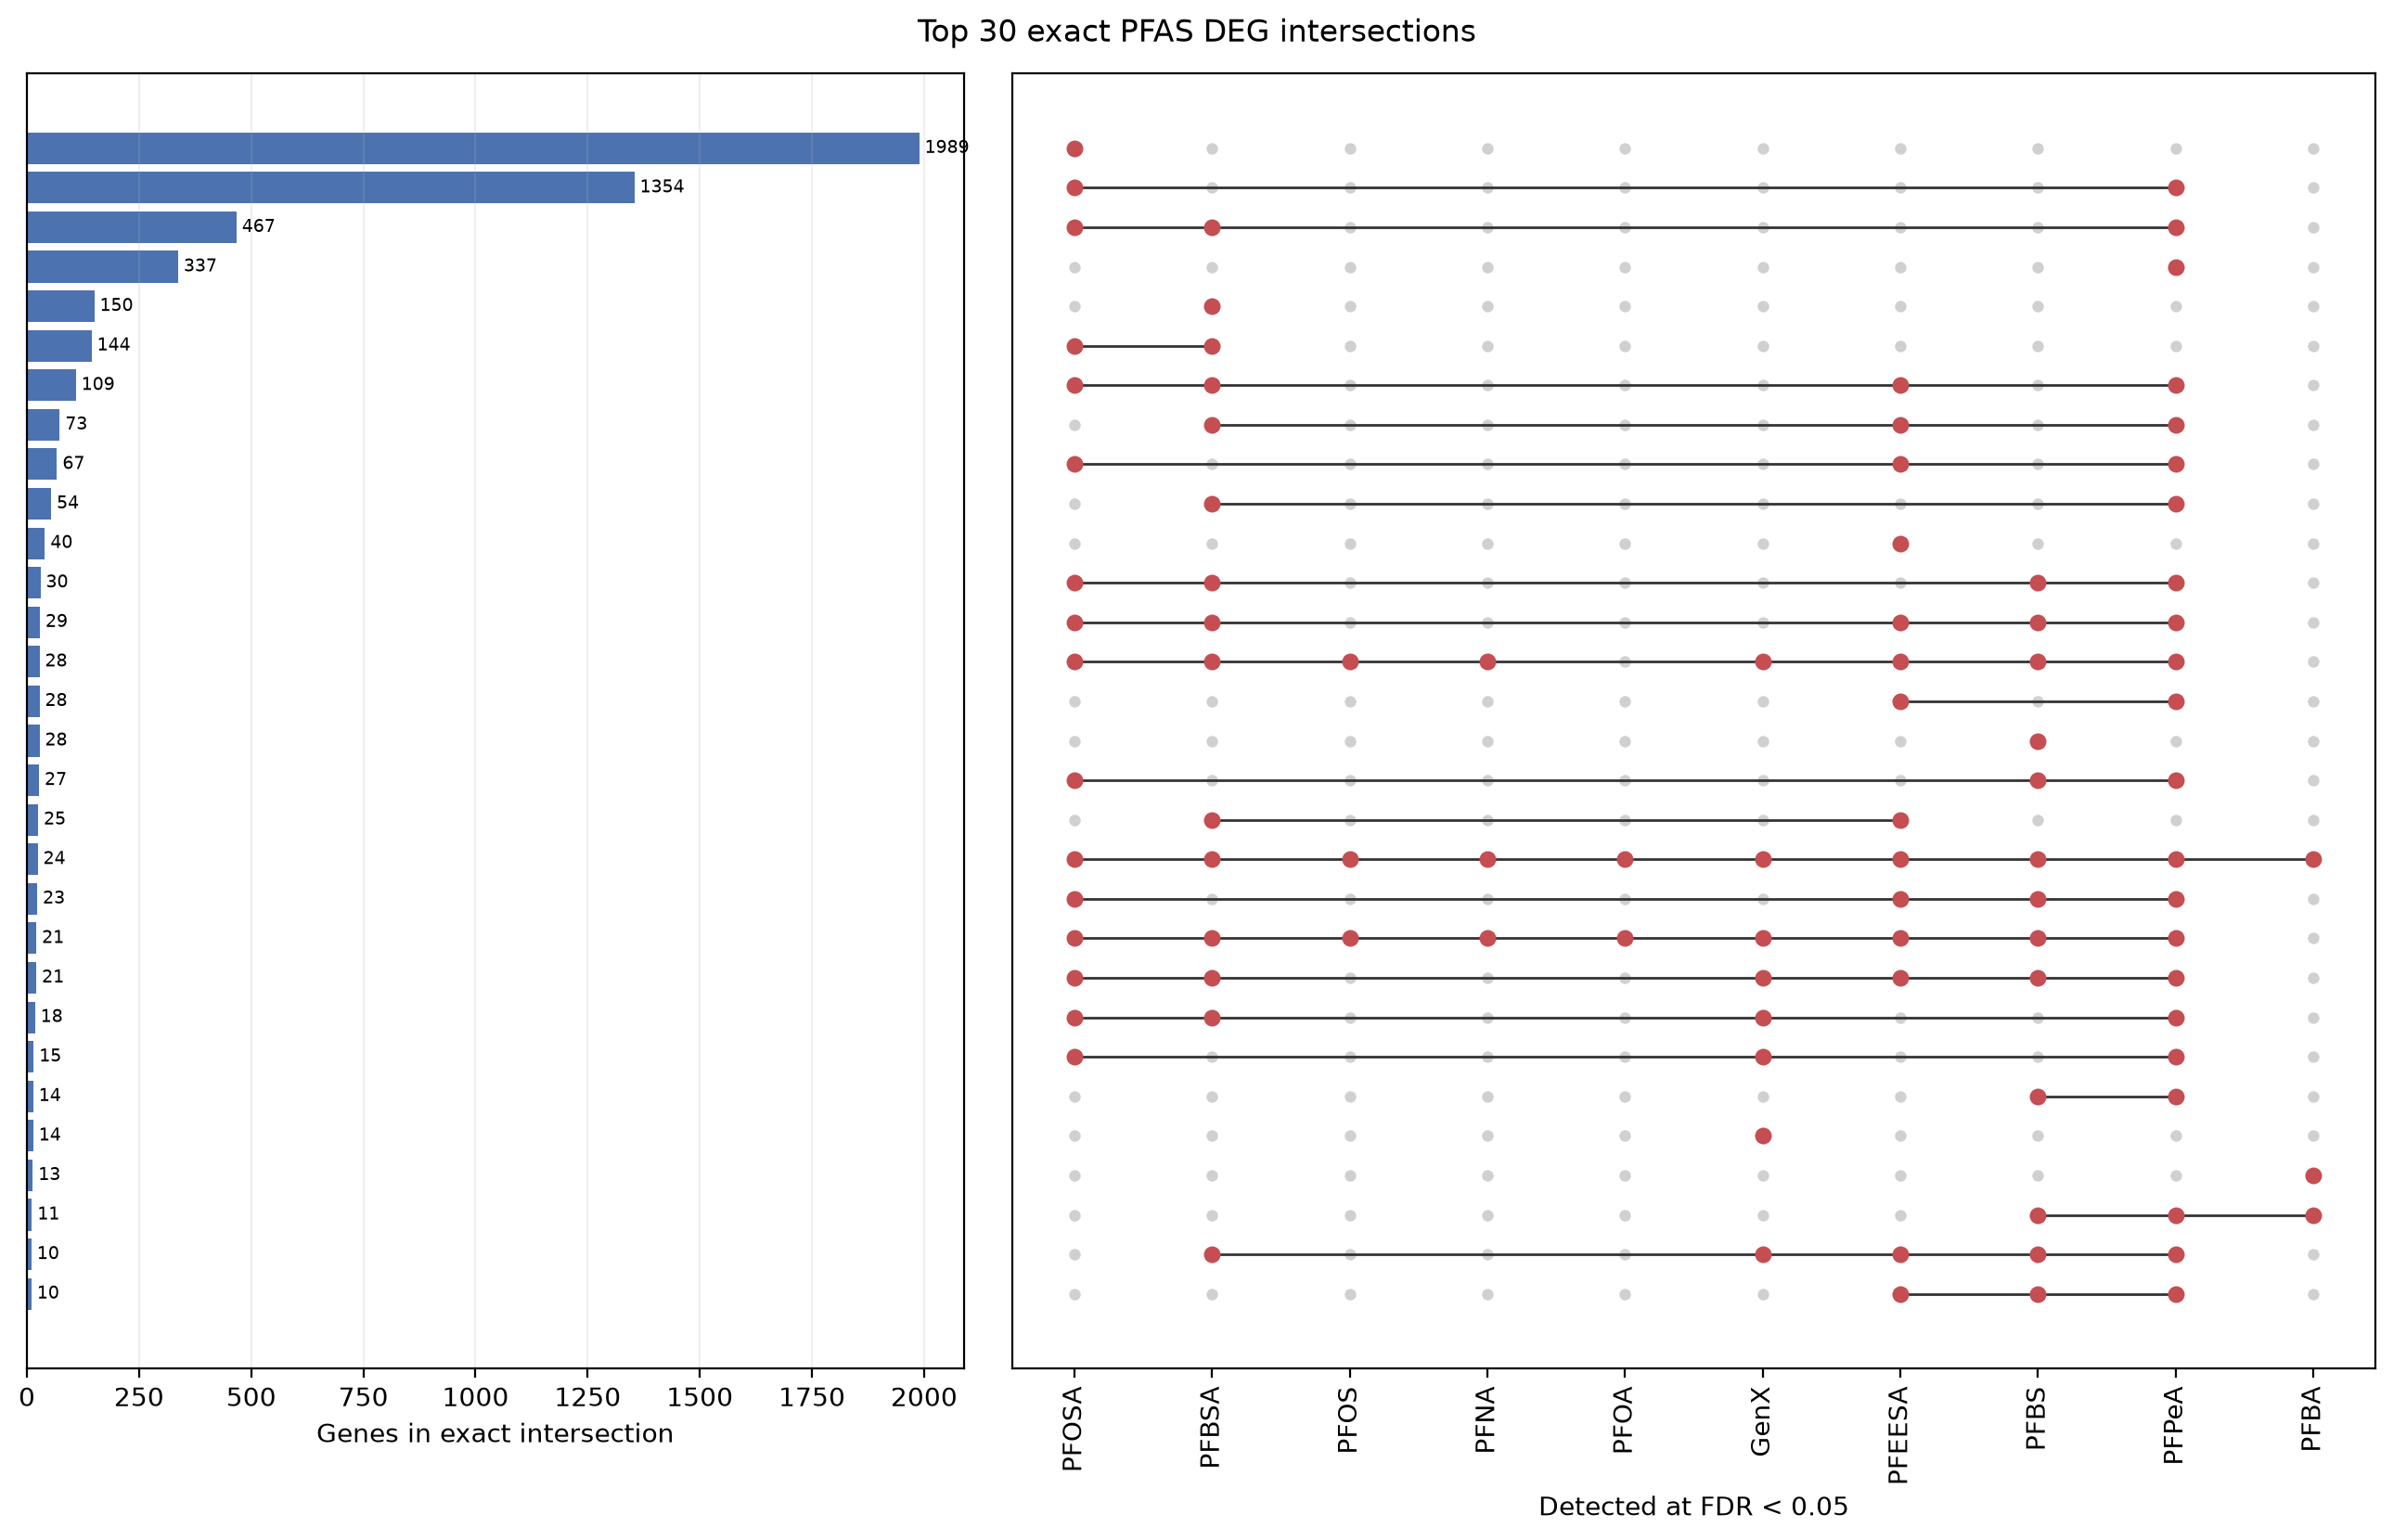

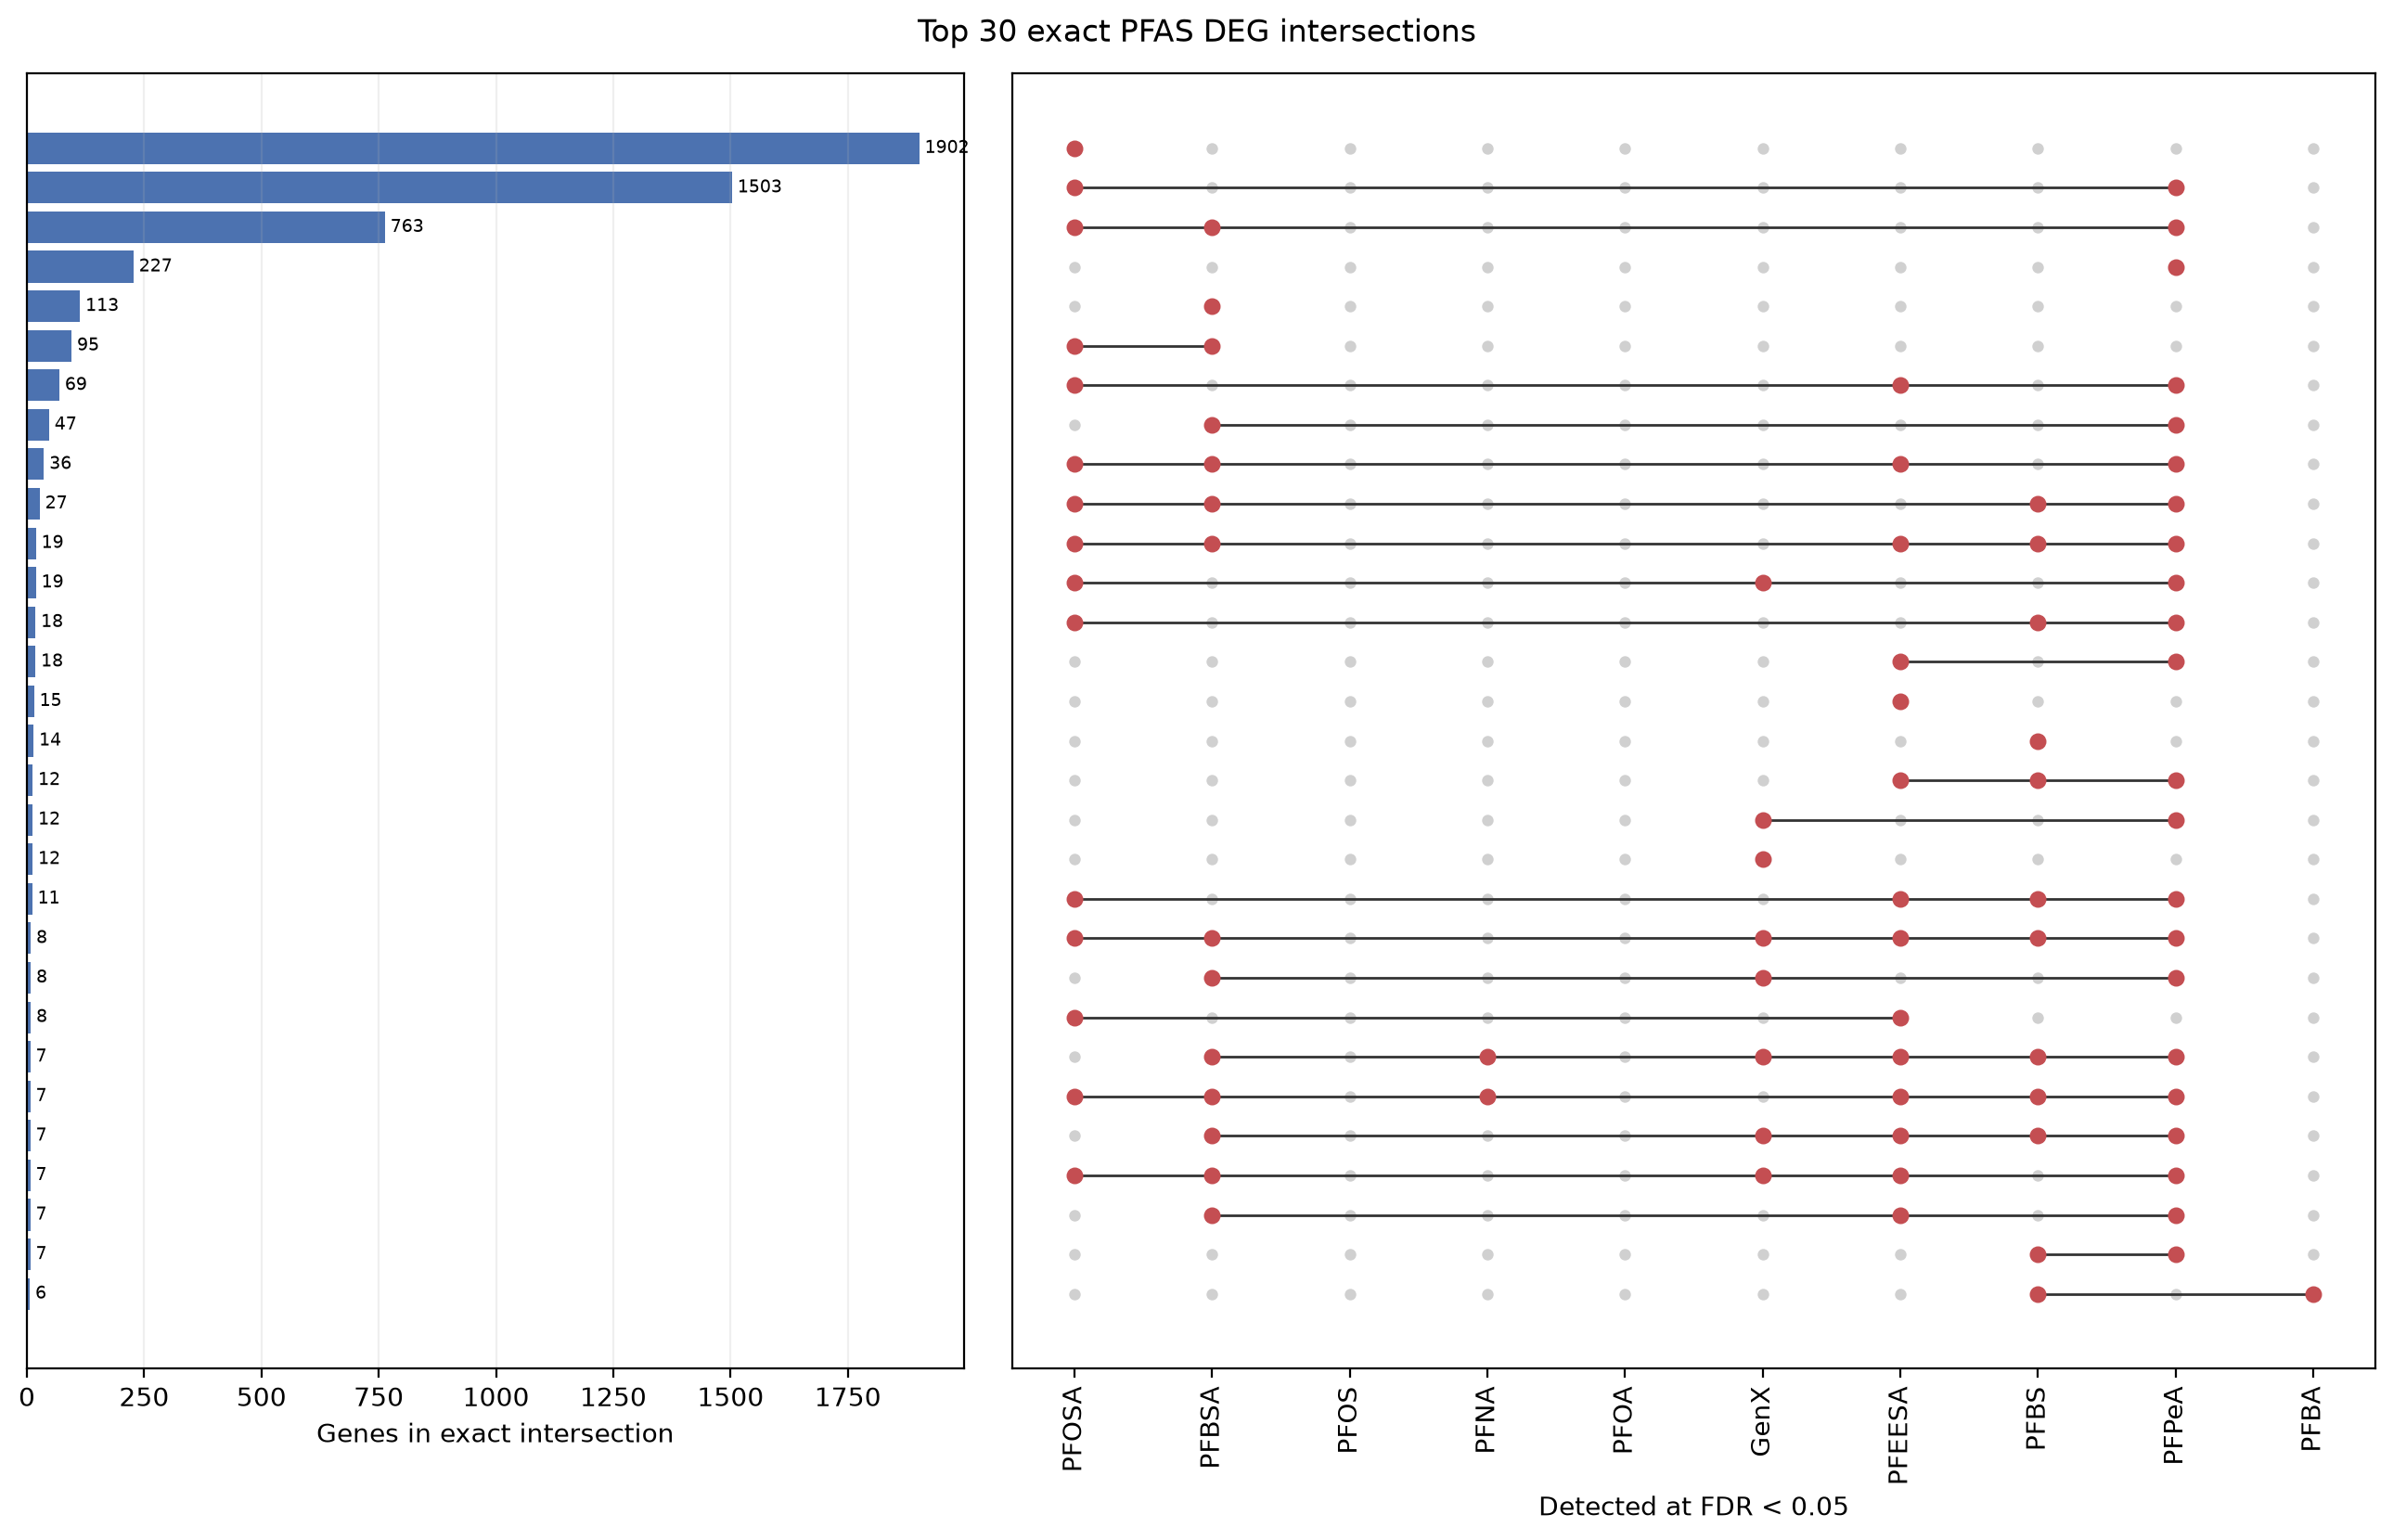

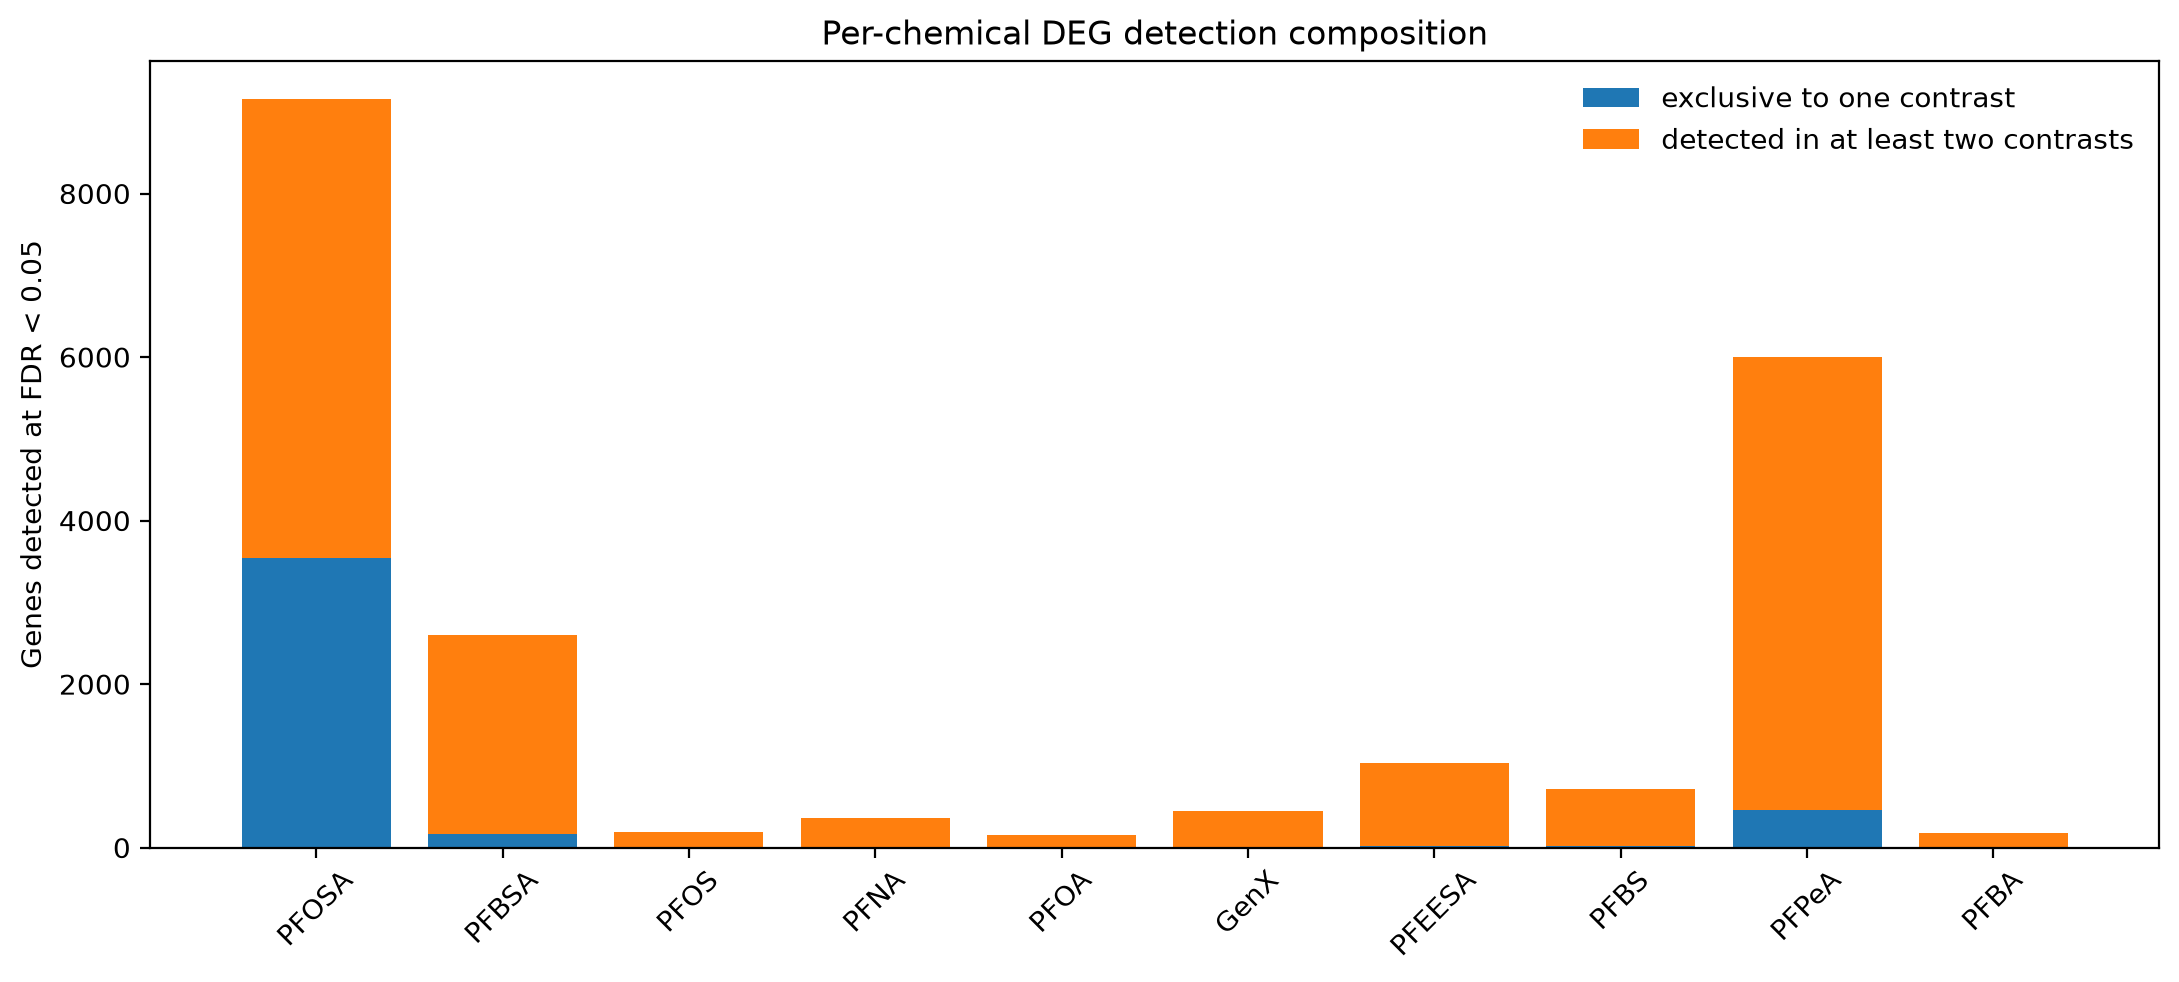

In [7]:
from pfas_master.deep_analysis import (
    detection_matrix,
    exact_intersection_table,
    plot_detection_composition,
    plot_upset,
    pairwise_detection_overlap,
    unique_shared_gene_sets,
)

deep_output = ROOT / 'output' / 'deep_analysis'
deep_figures = FIG_DIR / 'deep_analysis'
deep_output.mkdir(parents=True, exist_ok=True)
deep_figures.mkdir(parents=True, exist_ok=True)

detected_matrix = detection_matrix(dge_frames, threshold=FDR_THRESHOLD)
exact_intersections = exact_intersection_table(detected_matrix)
unique_gene_sets, shared_gene_sets, detection_composition = unique_shared_gene_sets(detected_matrix)
pairwise_overlap = pairwise_detection_overlap(dge_frames, detected_matrix)

up_detected_matrix = pd.DataFrame({
    chemical: detected_matrix[chemical] & dge_frames[chemical].logFC.gt(0)
    for chemical in CHEMICALS
})
down_detected_matrix = pd.DataFrame({
    chemical: detected_matrix[chemical] & dge_frames[chemical].logFC.lt(0)
    for chemical in CHEMICALS
})
up_intersections = exact_intersection_table(up_detected_matrix)
down_intersections = exact_intersection_table(down_detected_matrix)

exact_intersections.to_csv(deep_output / 'exact_DEG_intersections.csv', index=False)
up_intersections.to_csv(deep_output / 'exact_upregulated_DEG_intersections.csv', index=False)
down_intersections.to_csv(deep_output / 'exact_downregulated_DEG_intersections.csv', index=False)
detection_composition.to_csv(deep_output / 'per_chemical_unique_shared_counts.csv', index=False)
pairwise_overlap.to_csv(deep_output / 'pairwise_DEG_overlap_and_sign_concordance.csv', index=False)
detected_matrix.astype(int).to_csv(deep_output / 'gene_by_chemical_detection_matrix.csv')

exclusive_rows = []
for owner, genes in unique_gene_sets.items():
    for gene in sorted(genes):
        row = {'WB_id': gene, 'exclusive_detection_contrast': owner}
        for chemical in CHEMICALS:
            row[f'logFC_{chemical}'] = dge_frames[chemical].loc[gene, 'logFC']
            row[f'FDR_{chemical}'] = dge_frames[chemical].loc[gene, 'FDR']
        exclusive_rows.append(row)
exclusive_continuous_evidence = pd.DataFrame(exclusive_rows)
exclusive_continuous_evidence.to_csv(
    deep_output / 'exclusive_detection_genes_with_all_continuous_effects.csv', index=False
)
plot_upset(exact_intersections, deep_figures / 'upset_exact_DEG_intersections.png', top_n=30)
plot_upset(up_intersections, deep_figures / 'upset_exact_upregulated_intersections.png', top_n=30)
plot_upset(down_intersections, deep_figures / 'upset_exact_downregulated_intersections.png', top_n=30)
plot_detection_composition(detection_composition, deep_figures / 'per_chemical_DEG_composition.png')

display(detection_composition)
display(pairwise_overlap)
display(exact_intersections.head(30))
display(Image(filename=str(deep_figures / 'upset_exact_DEG_intersections.png')))
display(Image(filename=str(deep_figures / 'upset_exact_upregulated_intersections.png')))
display(Image(filename=str(deep_figures / 'upset_exact_downregulated_intersections.png')))
display(Image(filename=str(deep_figures / 'per_chemical_DEG_composition.png')))

## 4. Reconstruction of the Original Analytical Workflow

The original model-selection and stability steps are retained for auditability. Their outputs
are diagnostic records, not final scientific findings. The initial resampling code discarded
subset labels and measured repeated full-data optimizer variation instead of gene-subsample
stability. The revised strategy keeps shared-gene labels and reports optimizer and sampling
variation separately.

### k-spaces model selection: does BIC pick a sensible k?

Each module is fit as a **1-D affine subspace** (a line through the 10-D
chemical-response space) rather than a 0-D point/centroid: a line captures a
*direction* of coordinated response (which chemicals move together, and how
strongly), analogous to a WGCNA "module eigengene." d=0 (point) models are
fit as a null comparison at every k.


In [8]:

def fit_and_score(data, kd, initializations=10):
    spaces, probs = kspaces.run_EM(
        data, kd, assignment="soft", initializations=initializations,
        max_iter=100, tol=5e-2, silent=True,
    )
    if not spaces:
        return None
    ll = kspaces.total_log_likelihood(data, spaces)
    df = kspaces.model_selection_.get_df(spaces, eq_noise=False)
    n = data.shape[0]
    bic = kspaces.get_BIC(df, n, ll)
    icl = kspaces.get_ICL(probs, data, spaces, eq_noise=False)
    return {"df": df, "log_likelihood": ll, "BIC": bic, "ICL": icl, "spaces": spaces, "probs": probs}

data_primary = matrix_primary.values
t0 = time.time()
rows = []
for k in range(2, 26):
    for label, dim in [("d1_lines", 1), ("d0_points", 0)]:
        kd = [dim] * k
        r = fit_and_score(data_primary, kd, initializations=10)
        if r is None:
            continue
        rows.append({"k": k, "config": label, "df": r["df"], "log_likelihood": r["log_likelihood"],
                      "BIC": r["BIC"], "ICL": r["ICL"]})
model_selection_df = pd.DataFrame(rows)
model_selection_df.to_csv(ROOT / "output" / "kspaces_runs" / "primary_model_selection.csv", index=False)
print(f"Sweep over k=2..25, d in {{0,1}}: {len(model_selection_df)} models fit in {time.time()-t0:.0f}s")
model_selection_df.sort_values("BIC").head(10)


Sweep over k=2..25, d in {0,1}: 48 models fit in 75s


,k,config,df,log_likelihood,BIC,ICL
44,24,d1_lines,504.0,-79049.821766,162754.345951,168153.983118
46,25,d1_lines,525.0,-79070.352045,162989.352443,168581.710973
40,22,d1_lines,462.0,-79613.238846,163493.288241,168847.186380
42,23,d1_lines,483.0,-79564.715711,163590.187905,168852.494212
38,21,d1_lines,441.0,-79802.558873,163677.982362,169018.790163
34,19,d1_lines,399.0,-80219.208334,164123.389415,169051.584406
36,20,d1_lines,420.0,-80408.190878,164695.300438,169688.251413
30,17,d1_lines,357.0,-80701.704385,164700.489649,169371.414309
32,18,d1_lines,378.0,-80710.077020,164911.180854,169559.343671
28,16,d1_lines,336.0,-81398.588947,165900.312840,170235.543753


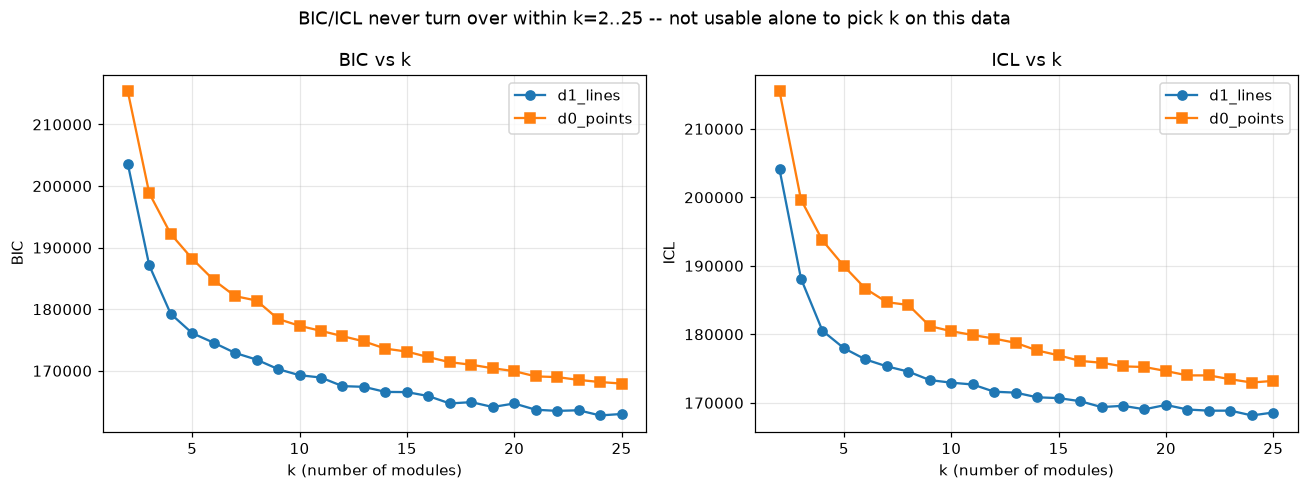

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label, marker in [("d1_lines", "o"), ("d0_points", "s")]:
    sub = model_selection_df[model_selection_df["config"] == label].sort_values("k")
    axes[0].plot(sub["k"], sub["BIC"], marker=marker, label=label)
    axes[1].plot(sub["k"], sub["ICL"], marker=marker, label=label)
axes[0].set_xlabel("k (number of modules)"); axes[0].set_ylabel("BIC"); axes[0].set_title("BIC vs k")
axes[1].set_xlabel("k (number of modules)"); axes[1].set_ylabel("ICL"); axes[1].set_title("ICL vs k")
for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("BIC/ICL never turn over within k=2..25 -- not usable alone to pick k on this data")
fig.tight_layout()
fig.savefig(FIG_DIR / "bic_icl_vs_k.png", dpi=150)
plt.show()


**Finding:** BIC and ICL both decrease monotonically all the way to
k=25 for the d=1 ("lines") configuration, with no interior minimum. This is
a known failure mode when the number of genes (N=10,255) vastly exceeds the
number of features (D=10 chemicals): there is enough room for arbitrarily
many subspaces to each grab a small likelihood gain. **BIC/ICL alone cannot
select k here** : a different criterion is needed (Section 4).

Note d=1 ("lines") beats d=0 ("points", i.e. plain centroid/k-means-like
clustering) on BIC at **every** k tested : the extra directional flexibility
is earning its complexity cost in raw fit quality, which is revisited
adversarially in Section 9.


## 5. Methodological Corrections and Validation Strategy

The revised workflow uses continuous effects, independent repeated fits, true gene subsamples,
null simulations, consensus voting, chemical-level jackknife checks, and permutation tests.
Threshold categories describe detection evidence and are not chemical-specific mechanisms.

### Choosing k via bootstrap stability instead of BIC

The planning document calls bootstrap stability "essential" validation.
For each k, fit a reference model, then repeatedly refit on gene-resampled
(with replacement) bootstraps and measure how well each bootstrap's module
structure reproduces the reference model's assignment on the **original**
data (Adjusted Rand Index). Mean ARI across bootstraps is the stability
score for that k.


In [10]:

def hard_labels(probs):
    return probs.argmax(axis=1)

def kspaces_fit(data, kd, initializations=10):
    spaces, probs = kspaces.run_EM(
        data, kd, assignment="soft", initializations=initializations,
        max_iter=100, tol=5e-2, silent=True,
    )
    return spaces, probs

n = data_primary.shape[0]
rng = np.random.default_rng(0)
stab_rows = []
t0 = time.time()
N_BOOT = 15
for k in range(3, 16):
    kd = [1] * k
    ref_spaces, ref_probs = kspaces_fit(data_primary, kd)
    if not ref_spaces:
        continue
    ref_labels = hard_labels(ref_probs)
    aris = []
    for _ in range(N_BOOT):
        boot_idx = rng.integers(0, n, size=n)
        boot_spaces, _ = kspaces_fit(data_primary[boot_idx], kd, initializations=5)
        if not boot_spaces:
            continue
        boot_probs_on_full = kspaces.E_step(data_primary, boot_spaces, assignment="soft")
        aris.append(adjusted_rand_score(ref_labels, hard_labels(boot_probs_on_full)))
    stab_rows.append({"k": k, "mean_ARI": np.mean(aris), "sd_ARI": np.std(aris), "n_boot_ok": len(aris)})

stability_df = pd.DataFrame(stab_rows).merge(
    model_selection_df[model_selection_df["config"] == "d1_lines"][["k", "BIC"]], on="k", how="left"
)
stability_df.to_csv(ROOT / "output" / "kspaces_runs" / "primary_stability.csv", index=False)
print(f"Bootstrap stability sweep k=3..15, {N_BOOT} resamples each: {time.time()-t0:.0f}s")
stability_df


Bootstrap stability sweep k=3..15, 15 resamples each: 204s


,k,mean_ARI,sd_ARI,n_boot_ok,BIC
0,3,0.903591,0.042961,15,187119.331960
1,4,0.905206,0.053722,15,179252.594335
2,5,0.749596,0.138165,15,176115.011749
3,6,0.738738,0.087707,15,174562.505744
4,7,0.506288,0.084302,15,172900.973327
5,8,0.559297,0.090561,15,171813.680388
6,9,0.504716,0.064173,15,170273.076954
7,10,0.428184,0.050318,15,169284.985051
8,11,0.485239,0.062992,15,168905.060678
9,12,0.455617,0.053751,15,167512.086952


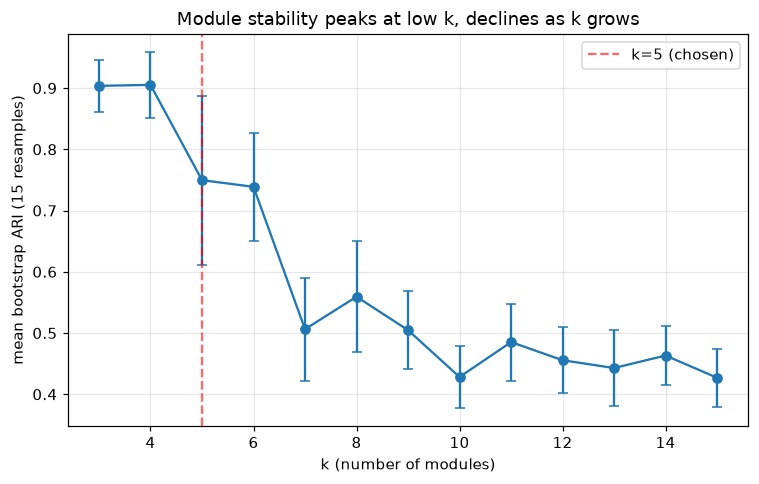

In [11]:

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(stability_df["k"], stability_df["mean_ARI"], yerr=stability_df["sd_ARI"], marker="o", capsize=3)
ax.axvline(5, color="red", linestyle="--", alpha=0.6, label="k=5 (chosen)")
ax.set_xlabel("k (number of modules)")
ax.set_ylabel("mean bootstrap ARI (15 resamples)")
ax.set_title("Module stability peaks at low k, declines as k grows")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "stability_vs_k.png", dpi=150)
plt.show()


In [12]:

print(f"Stability ARI range across k=3..15: {stability_df['mean_ARI'].min():.2f}-{stability_df['mean_ARI'].max():.2f}")
print(f"Best k by stability: k={stability_df.loc[stability_df['mean_ARI'].idxmax(), 'k']:.0f} "
      f"(ARI={stability_df['mean_ARI'].max():.3f})")
print(f"k=5 stability: ARI={stability_df.loc[stability_df['k']==5, 'mean_ARI'].values[0]:.3f}")


Stability ARI range across k=3..15: 0.43-0.91
Best k by stability: k=4 (ARI=0.905)
k=5 stability: ARI=0.750


**Finding:** reproducibility is moderate-to-weak everywhere (see
range printed above) and is generally highest at the low end of the k range
tested, declining (noisily) as k grows. **k=5 is chosen as a pragmatic
balance** between stability and having enough modules to be a meaningful
"table of modules" : this is a flagged, reviewable choice, not a validated
optimum; the printed numbers above show exactly how much stability is given
up relative to the best-stability k.


### Audit-only single-fit reconstruction

The cell below recreates the primary single fit only because later corrected analyses require its
assignment for direct diagnostics. Raw module-percentage similarity tables, rankings, heatmaps,
and structure-activity figures are intentionally excluded. They are retained only in the internal
archive and must not be cited as scientific results.

In [13]:

def fit_module_profile(matrix_df: pd.DataFrame, k: int, seed_note: str = ""):
    data = matrix_df.values
    kd = [1] * k
    spaces, probs = kspaces.run_EM(
        data, kd, assignment="soft", initializations=20, max_iter=150, tol=5e-2, silent=True,
    )
    labels = probs.argmax(axis=1)
    assign = pd.Series(labels, index=matrix_df.index, name="module")

    mat_df = matrix_df.copy()
    mat_df["module"] = assign
    mean_value = mat_df.groupby("module")[list(matrix_df.columns)].mean().round(3)

    pct_rows = []
    for c in CHEMICALS:
        chem_degs = merged.index[merged[f"FDR_{c}"] < FDR_THRESHOLD]
        chem_degs_in_union = assign.loc[assign.index.intersection(chem_degs)]
        if len(chem_degs) == 0:
            continue
        counts = chem_degs_in_union.value_counts().reindex(range(k), fill_value=0)
        pct = (counts / len(chem_degs) * 100).round(1)
        pct.name = c
        pct_rows.append(pct)
    pct_table = pd.DataFrame(pct_rows)
    pct_table.index.name = "chemical"

    corr = pct_table.T.corr()
    return assign, mean_value, pct_table, corr

assign_primary, meanval_primary, pct_primary, corr_primary = fit_module_profile(matrix_primary, 5)
print("Module sizes:")
display(assign_primary.value_counts().sort_index().to_frame("n_genes"))


Module sizes:


,n_genes
module,
0,1336
1,2002
2,2490
3,2894
4,1533


## 6. PFAS Response Patterns and Statistical Evidence

Module profiles, sensitivity variants, consensus assignments, null-adjusted comparisons, and
structure-activity probes are interpreted together. The ten chemicals are conditions rather
than biological replicates, so panel-level patterns do not establish generalization or causality.

### Adversarial checks: is k-spaces actually the right tool here?

Everything above validates *internal* consistency. This section checks
against a null model and a much simpler baseline, using the identical
bootstrap-ARI protocol as Section 4 for direct comparability.

**(a) Null baseline**: independently shuffle each chemical's column across
genes (destroys gene-level co-response structure, keeps each chemical's own
marginal distribution). If the real data isn't meaningfully better than
this, there's no real structure being found.

**(b) Baseline comparison**: plain k-means(k=5) on the same matrix, same
protocol, directly comparable to k-spaces' bootstrap ARI.


In [14]:

K = 5
N_BOOT_ADV = 15
perm_rng = np.random.default_rng(1)
perm_data = data_primary.copy()
for j in range(perm_data.shape[1]):
    perm_data[:, j] = perm_rng.permutation(perm_data[:, j])

real_spaces, real_probs = kspaces_fit(data_primary, [1] * K, initializations=20)
real_ll = kspaces.total_log_likelihood(data_primary, real_spaces)
real_bic = kspaces.get_BIC(kspaces.model_selection_.get_df(real_spaces, eq_noise=False), n, real_ll)

perm_spaces, perm_probs = kspaces_fit(perm_data, [1] * K, initializations=20)
perm_ll = kspaces.total_log_likelihood(perm_data, perm_spaces)
perm_bic = kspaces.get_BIC(kspaces.model_selection_.get_df(perm_spaces, eq_noise=False), n, perm_ll)

print(f"real data:      logL={real_ll:12.1f}  BIC={real_bic:12.1f}")
print(f"permuted null:  logL={perm_ll:12.1f}  BIC={perm_bic:12.1f}")
print(f"delta logL (real - null): {real_ll - perm_ll:.1f}  (higher = real data fits better than null)")


real data:      logL=    -87560.5  BIC=    176090.6
permuted null:  logL=   -120112.2  BIC=    241194.1
delta logL (real - null): 32551.7  (higher = real data fits better than null)


In [15]:

def bootstrap_ari(fit_fn, assign_fn, data, n, rng, n_boot=N_BOOT_ADV):
    ref_labels = assign_fn(fit_fn(data))
    aris = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_model = fit_fn(data[idx])
        aris.append(adjusted_rand_score(ref_labels, assign_fn(boot_model, data)))
    return float(np.mean(aris)), float(np.std(aris))

def ks_fit_fn(d):
    s, _ = kspaces_fit(d, [1] * K, initializations=8)
    return s

def ks_assign_fn_real(spaces, on_data=None):
    target = on_data if on_data is not None else data_primary
    return kspaces.E_step(target, spaces, assignment="soft").argmax(axis=1)

def ks_assign_fn_perm(spaces, on_data=None):
    target = on_data if on_data is not None else perm_data
    return kspaces.E_step(target, spaces, assignment="soft").argmax(axis=1)

t0 = time.time()
real_ari_mean, real_ari_sd = bootstrap_ari(ks_fit_fn, ks_assign_fn_real, data_primary, n, np.random.default_rng(0))
null_ari_mean, null_ari_sd = bootstrap_ari(ks_fit_fn, ks_assign_fn_perm, perm_data, n, np.random.default_rng(0))
print(f"real data k-spaces stability:      mean_ARI={real_ari_mean:.3f} sd={real_ari_sd:.3f}")
print(f"permuted null k-spaces stability:  mean_ARI={null_ari_mean:.3f} sd={null_ari_sd:.3f}")
print(f"({time.time()-t0:.0f}s)")


real data k-spaces stability:      mean_ARI=0.802 sd=0.127
permuted null k-spaces stability:  mean_ARI=0.677 sd=0.172
(24s)


In [16]:

def km_fit_fn(d):
    km = KMeans(n_clusters=K, n_init=10, random_state=0)
    km.fit(d)
    return km

def km_assign_fn(model, on_data=None):
    target = on_data if on_data is not None else data_primary
    return model.predict(target)

t0 = time.time()
km_ari_mean, km_ari_sd = bootstrap_ari(km_fit_fn, km_assign_fn, data_primary, n, np.random.default_rng(0))
ref_kspaces_labels = ks_assign_fn_real(real_spaces)
km_ref = km_fit_fn(data_primary)
agreement_ari = adjusted_rand_score(ref_kspaces_labels, km_assign_fn(km_ref))

adv_summary = pd.DataFrame([
    {"check": "real_vs_null_logL_delta", "value": real_ll - perm_ll},
    {"check": "real_vs_null_BIC_delta", "value": perm_bic - real_bic},
    {"check": "real_data_kspaces_stability_ARI", "value": real_ari_mean},
    {"check": "permuted_null_kspaces_stability_ARI", "value": null_ari_mean},
    {"check": "kmeans_stability_ARI", "value": km_ari_mean},
    {"check": "kmeans_vs_kspaces_agreement_ARI", "value": agreement_ari},
])
adv_summary.to_csv(ROOT / "output" / "kspaces_runs" / "adversarial_baseline_checks.csv", index=False)
print(f"k-means(k=5) stability:  mean_ARI={km_ari_mean:.3f} sd={km_ari_sd:.3f}  ({time.time()-t0:.0f}s)")
print(f"k-spaces(k=5, d=1) stability (from above): mean_ARI={real_ari_mean:.3f}")
print(f"ARI(k-means labels vs k-spaces labels) on real data: {agreement_ari:.3f}")
print(f"\nk-means is {km_ari_mean/real_ari_mean:.1f}x more stable than k-spaces on this data.")
display(adv_summary)


k-means(k=5) stability:  mean_ARI=0.896 sd=0.059  (2s)
k-spaces(k=5, d=1) stability (from above): mean_ARI=0.802
ARI(k-means labels vs k-spaces labels) on real data: 0.362

k-means is 1.1x more stable than k-spaces on this data.


,check,value
0,real_vs_null_logL_delta,32551.732068
1,real_vs_null_BIC_delta,65103.464136
2,real_data_kspaces_stability_ARI,0.802081
3,permuted_null_kspaces_stability_ARI,0.676559
4,kmeans_stability_ARI,0.895984
5,kmeans_vs_kspaces_agreement_ARI,0.361599


**(a) Real data vs. null**: the log-likelihood delta and BIC delta
printed above (both strongly favoring real data) and the stability
comparison (real data ARI well above the permuted-null ARI) together show
**k-spaces is finding real, non-null structure**, not just fitting noise.

**(b) k-spaces vs. k-means**: the ratio printed above quantifies it :
**k-means is meaningfully more stable than k-spaces** on this exact data,
and the agreement ARI between the two methods' labels shows they find
genuinely different partitions, not minor variants of the same one. This is
a real bias-variance tradeoff: d=1 lines already showed better raw fit
(lower BIC) than d=0 points at every k (Section 3), because fitting a
*direction* (coordinated response shape) is a richer model than fitting a
centroid : but that same flexibility makes it more sensitive to exactly
which genes land in a given resample.

**Bottom line: k-spaces is not obviously "the best" method by a
reproducibility metric : k-means is more stable on this data.** Whether
k-spaces' extra directional information is worth the stability cost is a
judgment call for whoever is driving the biological interpretation.


### Beyond bootstrap: consensus clustering, chemical-level jackknife, and a formal permutation test

Bootstrap resampling (Sections 4 and 11) only diagnoses how much a single
fit wobbles under resampling : it doesn't build anything better, and it only
probes one axis of fragility (which genes happen to be in the dataset). This
section goes further on three fronts, each targeting a different weakness:

1. **Consensus clustering** (Monti et al. 2003): fit k-spaces many times with
   independent random restarts on the *same* full dataset, align each run's
   module labels to a reference via the Hungarian algorithm (label identity
   is arbitrary between runs), then take each gene's majority-vote label
   across all runs as a **consensus module assignment** : plus a per-gene
   **consensus strength** (the fraction of runs agreeing with that majority),
   which flags which genes are core, trustworthy module members versus
   ambiguous boundary cases. This directly answers the earlier open question
   of whether a single arbitrary EM fit was understating real structure by
   landing in a mediocre local optimum.
2. **Chemical-level jackknife**: drop one chemical at a time (9 remain), fit
   the same consensus procedure, and compare to the full 10-chemical
   consensus. This tests a different fragility than gene bootstrap : whether
   the whole module structure hinges on any single chemical's presence.
3. **A real permutation p-value**: run many (not one) column-permuted null
   fits and report the empirical p-value and z-score of real data's
   log-likelihood against that null distribution, rather than a single delta.

We also tested deterministic annealing (`DA=True`) and more EM
initializations as ways to reduce optimization noise directly, with an
honest negative result on one of them : shown below rather than omitted.


In [17]:

from scipy.optimize import linear_sum_assignment
from scipy.stats import mode as scipy_mode

# --- deterministic annealing / initializations check (reported honestly, including the negative result) ---
def fit_ll_for_config(d, seed, **kwargs):
    np.random.seed(seed)
    kwargs.setdefault("max_iter", 150)
    spaces, probs = kspaces.run_EM(d, [1] * K, assignment="soft", tol=5e-2, silent=True, **kwargs)
    return kspaces.total_log_likelihood(d, spaces)

da_check_rows = []
for label, kwargs in [("init=20, DA=False", dict(initializations=20, DA=False)),
                       ("init=50, DA=False", dict(initializations=50, DA=False)),
                       ("init=20, DA=True",  dict(initializations=20, DA=True))]:
    lls = [fit_ll_for_config(data_primary, 100 + trial, **kwargs) for trial in range(5)]
    da_check_rows.append({"config": label, "best_logL": max(lls), "mean_logL": np.mean(lls), "sd_logL": np.std(lls)})
da_check_df = pd.DataFrame(da_check_rows)
print("EM configuration check (5 trials each, fixed seeds 100-104):")
display(da_check_df)
print("\nFinding: more initializations gives a small improvement in best-found fit;")
print("deterministic annealing (DA=True) does NOT help here -- it converges more")
print("consistently (lower sd) but to a WORSE optimum on average. Not adopted.")


EM configuration check (5 trials each, fixed seeds 100-104):


,config,best_logL,mean_logL,sd_logL
0,"init=20, DA=False",-87556.118987,-87577.995398,35.958625
1,"init=50, DA=False",-87543.008395,-87561.313442,13.837543
2,"init=20, DA=True",-87550.306077,-87554.037467,3.434634



Finding: more initializations gives a small improvement in best-found fit;
deterministic annealing (DA=True) does NOT help here -- it converges more
consistently (lower sd) but to a WORSE optimum on average. Not adopted.


#### Consensus clustering: a more stable module assignment than any single fit

In [18]:

def fit_labels_seeded(data, seed, kd, inits=20):
    np.random.seed(seed)
    spaces, probs = kspaces.run_EM(data, kd, assignment="soft", initializations=inits, max_iter=150, tol=5e-2, silent=True)
    return probs.argmax(axis=1)

def align_to_reference(labels, ref_labels, k):
    cost = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            cost[i, j] = -np.sum((labels == i) & (ref_labels == j))
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = dict(zip(row_ind, col_ind))
    return np.array([mapping[l] for l in labels])

def consensus_cluster(data, k, R=30, base_seed=0, inits=20):
    ref_labels = fit_labels_seeded(data, base_seed, [1] * k, inits)
    runs = [ref_labels]
    for r in range(1, R):
        labels = fit_labels_seeded(data, base_seed + r, [1] * k, inits)
        runs.append(align_to_reference(labels, ref_labels, k))
    runs = np.array(runs)
    consensus_labels = scipy_mode(runs, axis=0, keepdims=False).mode
    consensus_strength = (runs == consensus_labels).mean(axis=0)
    return consensus_labels, consensus_strength, runs

t0 = time.time()
consensus_labels, consensus_strength, consensus_runs = consensus_cluster(data_primary, K, R=30, base_seed=0)
assign_consensus = pd.Series(consensus_labels, index=matrix_primary.index, name="module")
consensus_strength_s = pd.Series(consensus_strength, index=matrix_primary.index, name="consensus_strength")
print(f"30 independent k-spaces fits, aligned and majority-voted, in {time.time()-t0:.0f}s")
print("\nConsensus module sizes:")
display(assign_consensus.value_counts().sort_index().to_frame("n_genes"))
print(f"\nMean consensus strength (fraction of 30 runs agreeing with the majority label): {consensus_strength_s.mean():.3f}")
print(f"Genes with >=80% agreement across runs ('core' members): {(consensus_strength_s>=0.8).mean()*100:.1f}%")
print(f"Genes with <50% agreement (ambiguous boundary cases): {(consensus_strength_s<0.5).mean()*100:.1f}%")

single_run_aris = [adjusted_rand_score(consensus_labels, consensus_runs[r]) for r in range(len(consensus_runs))]
print(f"\nARI(any single run, consensus): mean={np.mean(single_run_aris):.3f} "
      f"(compare to Section 4's bootstrap ARI at k=5: {stability_df.loc[stability_df['k']==5,'mean_ARI'].values[0]:.3f} "
      f"-- consensus agrees with individual runs *more* than individual bootstrap runs agree with each other,\n"
      f"meaning consensus is capturing the shared signal across runs rather than just one run's idiosyncrasies)")

assign_consensus.to_csv(ROOT / "output" / "kspaces_runs" / "primary_k5_consensus_module_assignments.csv")
consensus_strength_s.to_csv(ROOT / "output" / "kspaces_runs" / "primary_k5_consensus_strength.csv")


30 independent k-spaces fits, aligned and majority-voted, in 42s

Consensus module sizes:


,n_genes
module,
0,1915
1,1496
2,2386
3,2944
4,1514



Mean consensus strength (fraction of 30 runs agreeing with the majority label): 0.951
Genes with >=80% agreement across runs ('core' members): 91.4%
Genes with <50% agreement (ambiguous boundary cases): 0.0%

ARI(any single run, consensus): mean=0.890 (compare to Section 4's bootstrap ARI at k=5: 0.750 -- consensus agrees with individual runs *more* than individual bootstrap runs agree with each other,
meaning consensus is capturing the shared signal across runs rather than just one run's idiosyncrasies)


In [19]:
def module_profile_from_assignment(assign: pd.Series, matrix_df: pd.DataFrame, k: int):
    mat_df = matrix_df.loc[assign.index].copy()
    mat_df['module'] = assign
    mean_value = mat_df.groupby('module')[list(matrix_df.columns)].mean().round(3)
    pct_rows = []
    for chemical in CHEMICALS:
        detected = merged.index[merged[f'FDR_{chemical}'] < FDR_THRESHOLD]
        detected_assignments = assign.loc[assign.index.intersection(detected)]
        counts = detected_assignments.value_counts().reindex(range(k), fill_value=0)
        row = (counts / len(detected) * 100).round(1)
        row.name = chemical
        pct_rows.append(row)
    pct_table = pd.DataFrame(pct_rows)
    pct_table.index.name = 'chemical'
    return mean_value, pct_table

meanval_consensus, pct_consensus = module_profile_from_assignment(
    assign_consensus, matrix_primary, K
)
core_mask = consensus_strength_s >= 0.8
assign_core = assign_consensus[core_mask]
print(f'Consensus profile prepared for {len(assign_consensus)} genes; '
      f'{core_mask.sum()} have at least 80% assignment agreement.')

Consensus profile prepared for 10255 genes; 9375 have at least 80% assignment agreement.


### Per-chemical and per-module gene contributions

Every chemical-by-module combination is regenerated from the consensus assignment. The detailed
gene table retains logFC, FDR, direction, detection status, module, and consensus strength. The
summary reports counts and proportions without treating thresholded non-detection as zero effect.
Separate CSV files make all 50 combinations inspectable outside the notebook.

,chemical,consensus_module,module_genes,detected_genes,up_detected,down_detected,mean_logFC,median_logFC,mean_consensus_strength,core_genes,pct_module_detected,pct_chemical_detected_in_module,pct_up_among_detected,pct_up_wilson_low,pct_up_wilson_high
0,GenX,0,1915,1,0,1,-0.085003,-0.050796,0.982785,1868,0.052219,0.224215,0.000000,0.000000,79.345069
1,GenX,1,1496,212,124,88,0.098851,0.009560,0.907242,1247,14.171123,47.533632,58.490566,51.764213,64.914696
2,GenX,2,2386,70,36,34,-0.034107,-0.028102,0.965898,2270,2.933780,15.695067,51.428571,39.954384,62.754122
3,GenX,3,2944,151,113,38,0.074423,0.038011,0.940636,2630,5.129076,33.856502,74.834437,67.355294,81.081346
4,GenX,4,1514,12,11,1,0.063212,0.054392,0.951189,1360,0.792602,2.690583,91.666667,64.612009,98.513491
5,PFBA,0,1915,0,0,0,-0.045068,-0.025433,0.982785,1868,0.000000,0.000000,NaN,NaN,NaN
6,PFBA,1,1496,99,68,31,0.030993,-0.005533,0.907242,1247,6.617647,53.804348,68.686869,58.998496,76.979213
7,PFBA,2,2386,33,23,10,-0.022791,-0.013757,0.965898,2270,1.383068,17.934783,69.696970,52.661865,82.624469
8,PFBA,3,2944,48,29,19,0.027057,0.030250,0.940636,2630,1.630435,26.086957,60.416667,46.310408,72.979172
9,PFBA,4,1514,4,1,3,0.018609,0.024210,0.951189,1360,0.264201,2.173913,25.000000,4.558726,69.935816


,chemical,module,clustered_genes,module_genes,detected_genes,observed,expected,log2_observed_expected,pearson_residual,fisher_odds_ratio,p_raw,q_bh_50_cells
0,PFOSA,0,10255,1915,9161,1915,1710.708435,0.162706,4.939266,inf,5.587580e-105,9.312634e-104
1,PFOSA,1,10255,1496,9161,616,1336.407216,-1.116727,-19.706461,0.017531,0.000000e+00,0.000000e+00
2,PFOSA,2,10255,2386,9161,2323,2131.462311,0.124118,4.148732,5.559532,2.566826e-60,1.426014e-59
3,PFOSA,3,10255,2944,9161,2793,2629.935056,0.086772,3.179714,2.739067,2.057179e-34,5.714385e-34
4,PFOSA,4,10255,1514,9161,1514,1352.486982,0.162694,4.391784,inf,4.719677e-81,3.933064e-80
5,PFBSA,0,10255,1915,2601,620,485.705997,0.351864,6.093543,1.536832,2.023655e-14,3.489061e-14
6,PFBSA,1,10255,1496,2601,708,379.434032,0.899019,16.867644,3.258819,4.125427e-89,5.156783e-88
7,PFBSA,2,10255,2386,2601,347,605.166845,-0.801511,-10.494528,0.423944,2.615304e-47,1.089710e-46
8,PFBSA,3,10255,2944,2601,577,746.693710,-0.371661,-6.210041,0.636761,5.346113e-18,1.113774e-17
9,PFBSA,4,10255,1514,2601,349,383.999415,-0.137689,-1.786058,0.863195,2.513928e-02,2.732530e-02


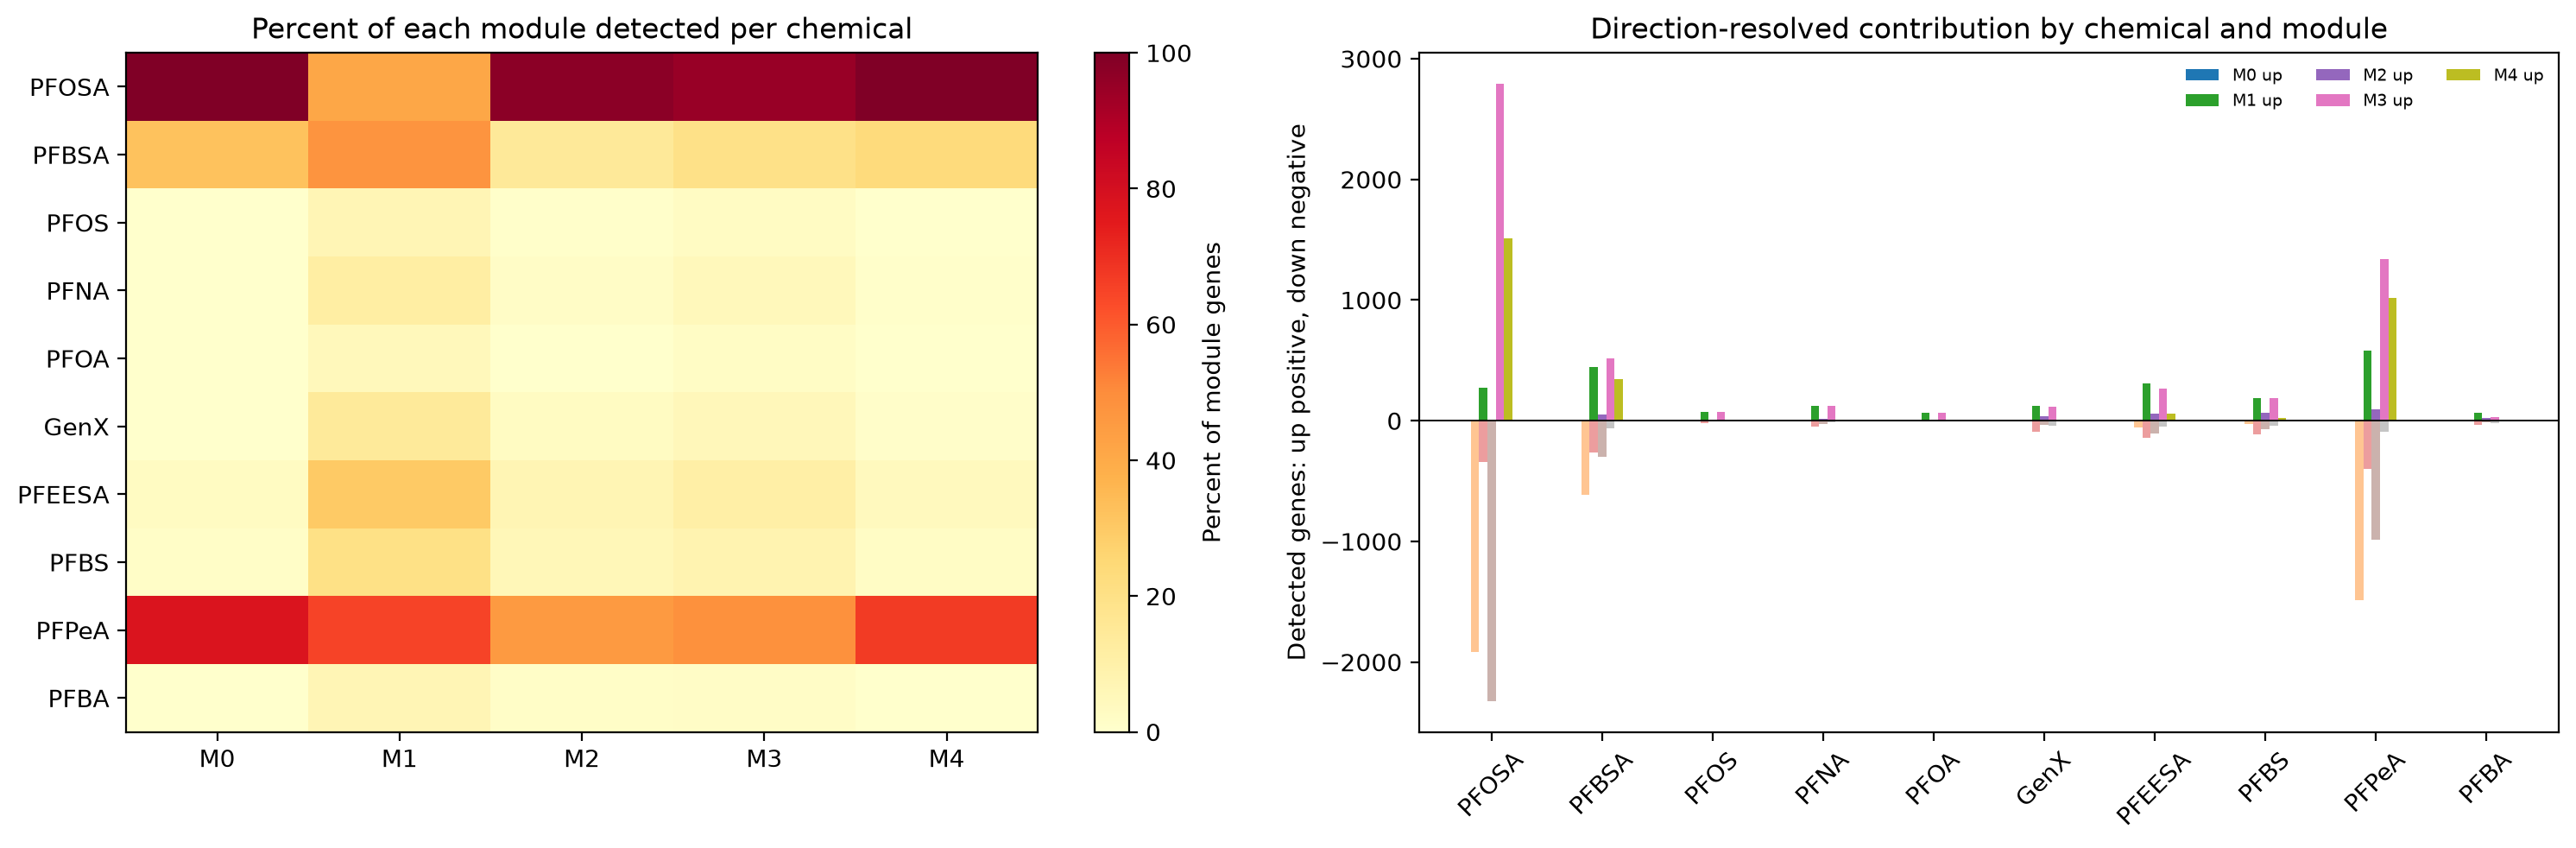

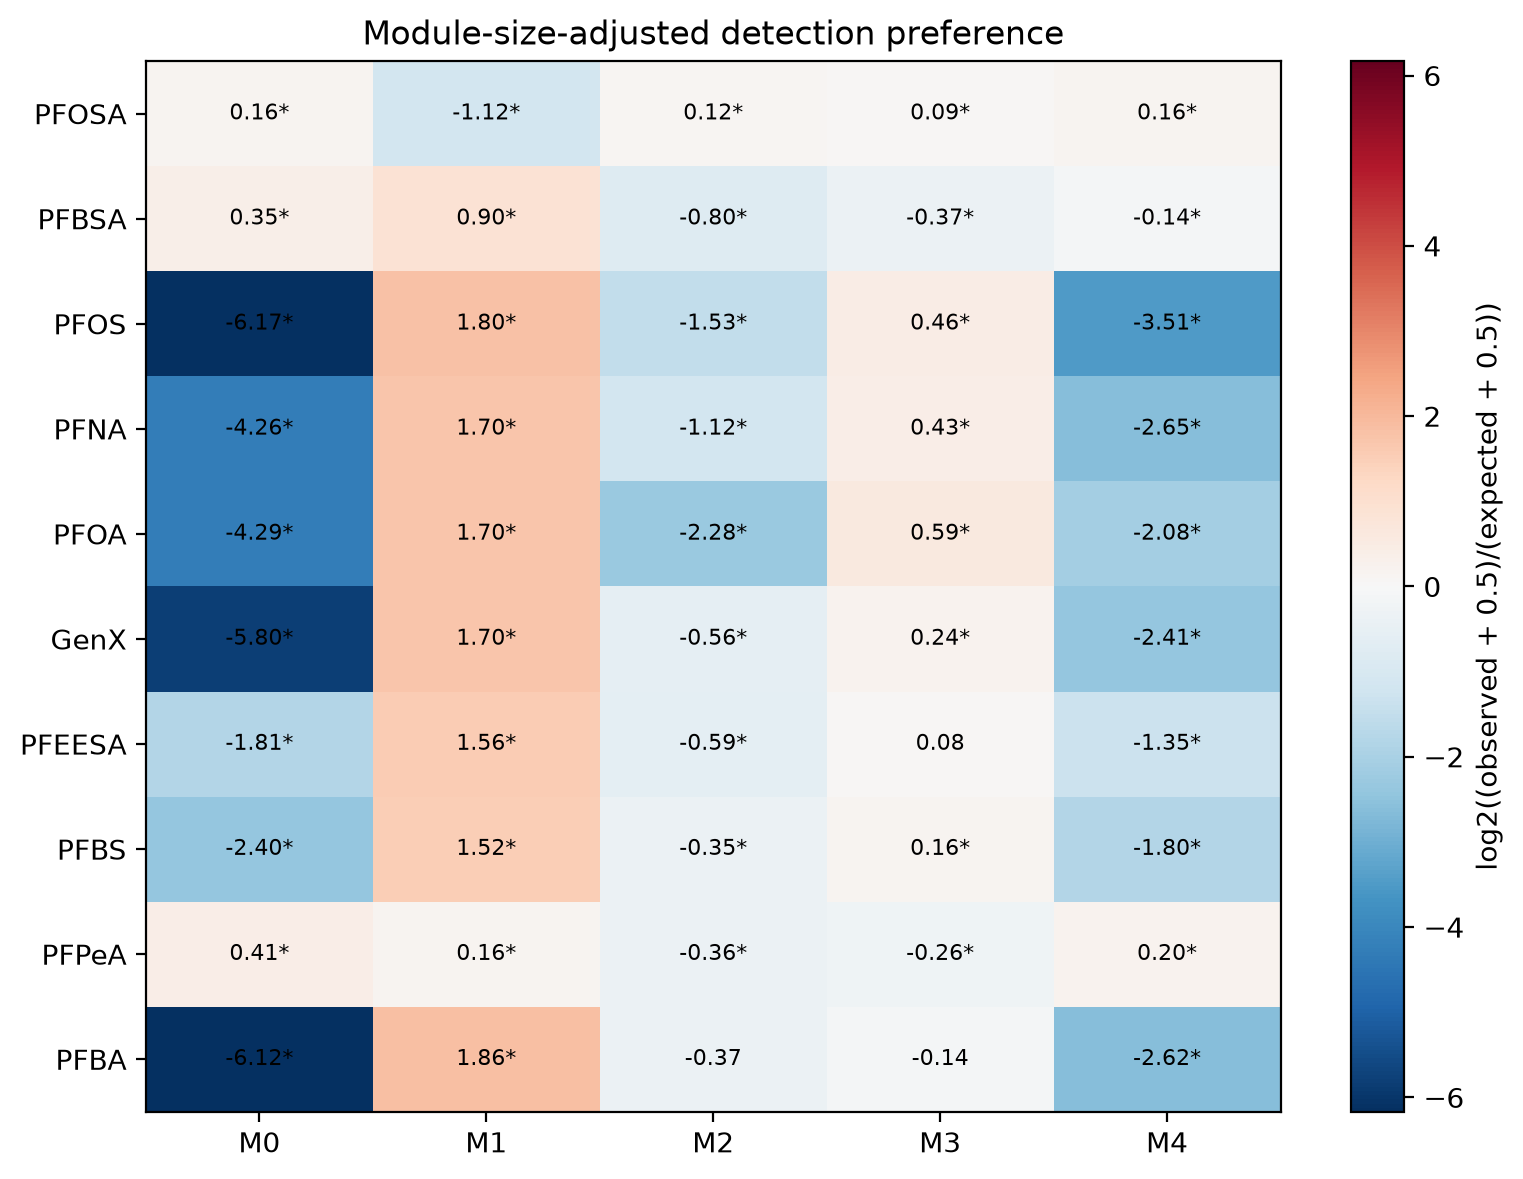

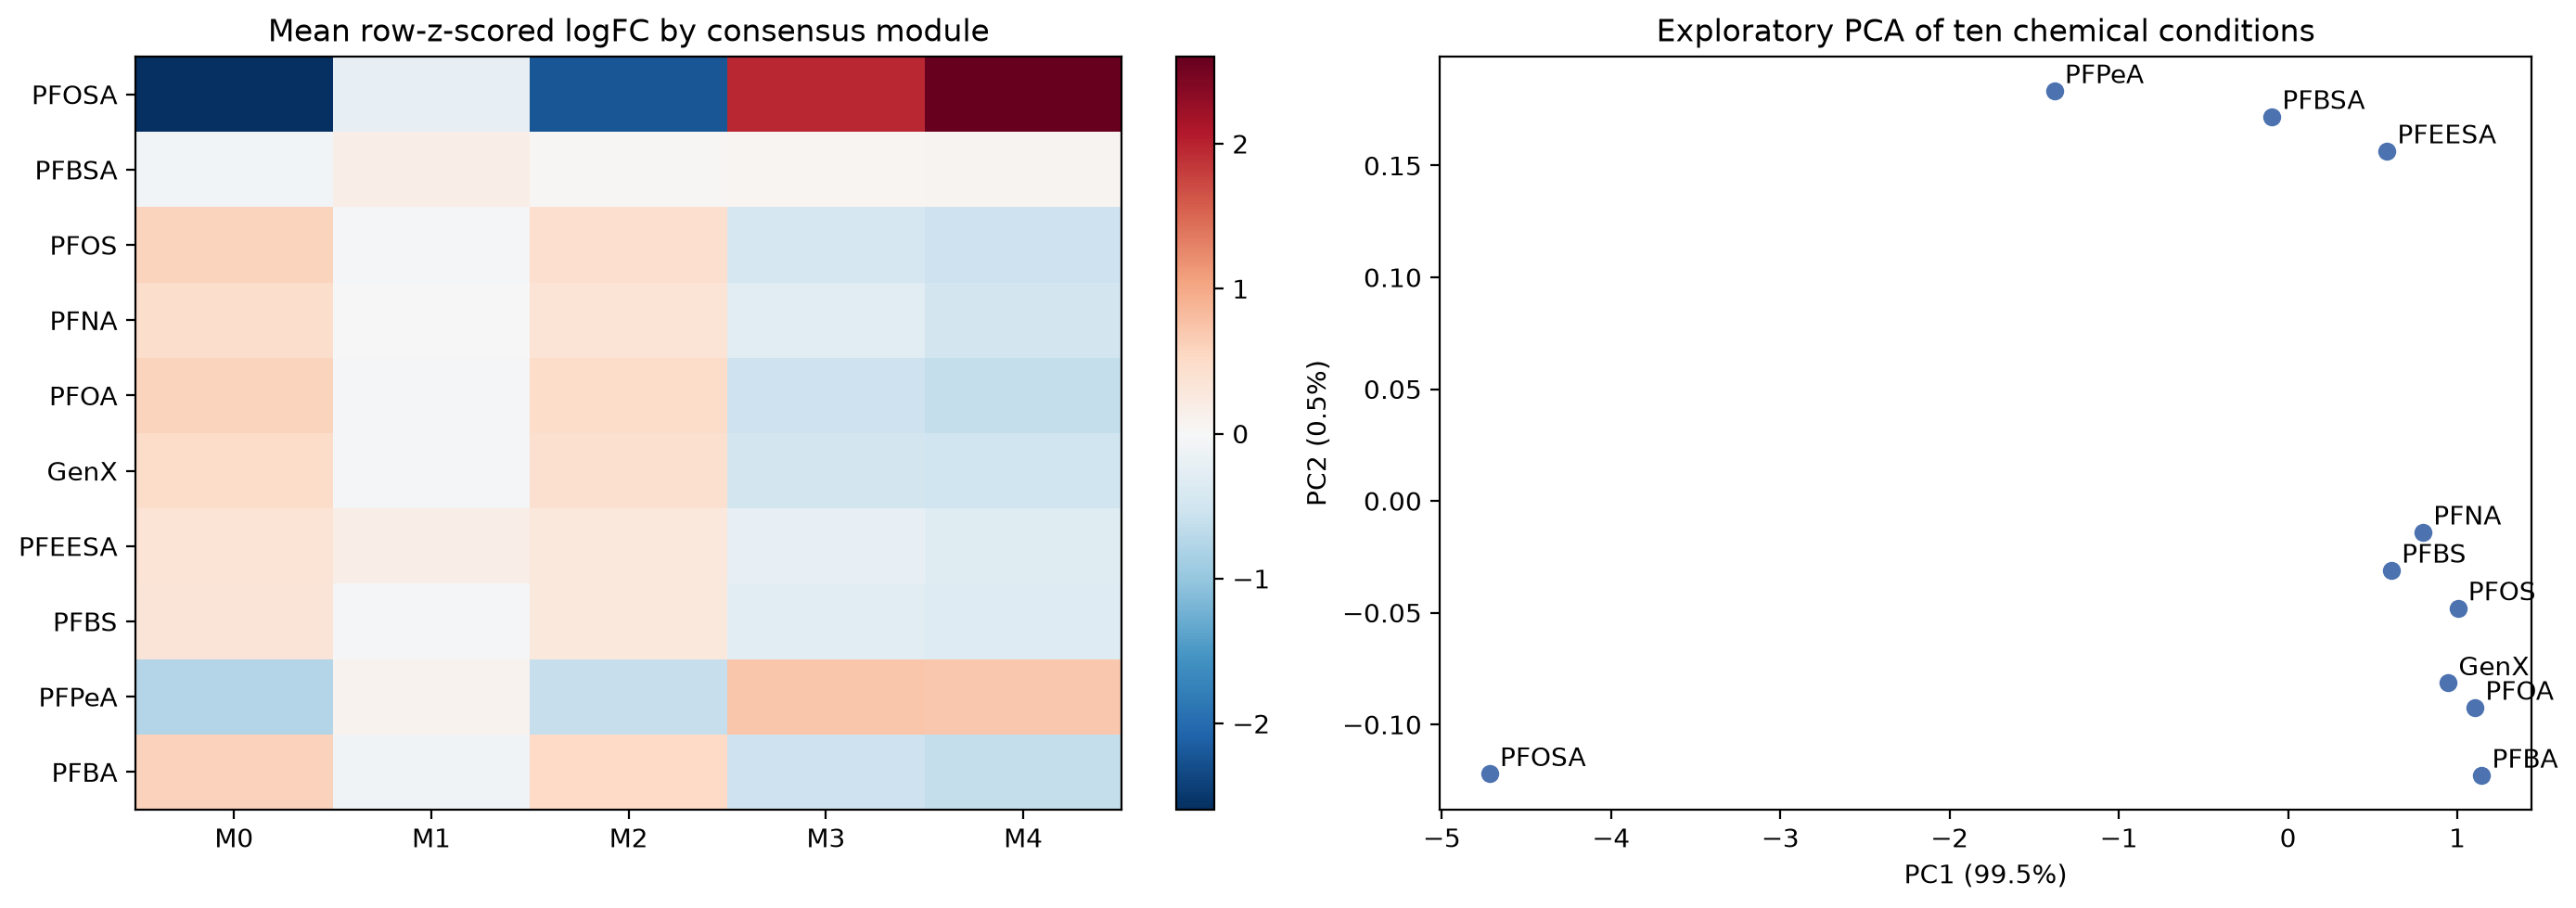

In [20]:
from pfas_master.science import build_module_contributions
from pfas_master.deep_analysis import (
    chemical_module_preference,
    module_activity_pca,
    plot_module_activity,
)

gene_contributions, contribution_summary = build_module_contributions(
    dge_frames, assign_consensus, consensus_strength_s
)
gene_contributions.to_csv(deep_output / 'gene_contributions_all_chemicals_modules.csv', index=False)
contribution_summary.to_csv(deep_output / 'summary_gene_contributions.csv', index=False)
module_preference = chemical_module_preference(detected_matrix, assign_consensus)
module_preference.to_csv(deep_output / 'chemical_module_preference_50_tests.csv', index=False)

gene_list_dir = deep_output / 'gene_lists_by_chemical_module'
gene_list_dir.mkdir(parents=True, exist_ok=True)
for (chemical, module), group in gene_contributions.groupby(['chemical', 'consensus_module']):
    group.sort_values(['is_detected', 'FDR', 'logFC'], ascending=[False, True, False]).to_csv(
        gene_list_dir / f'{chemical}_module_{module}_genes.csv', index=False
    )

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
summary_pivot = contribution_summary.pivot(
    index='chemical', columns='consensus_module', values='pct_module_detected'
).reindex(CHEMICALS)
image = axes[0].imshow(summary_pivot, aspect='auto', cmap='YlOrRd')
axes[0].set_xticks(range(summary_pivot.shape[1]), [f'M{x}' for x in summary_pivot.columns])
axes[0].set_yticks(range(len(summary_pivot)), summary_pivot.index)
axes[0].set_title('Percent of each module detected per chemical')
fig.colorbar(image, ax=axes[0], label='Percent of module genes')

up = contribution_summary.pivot(index='chemical', columns='consensus_module', values='up_detected').reindex(CHEMICALS)
down = contribution_summary.pivot(index='chemical', columns='consensus_module', values='down_detected').reindex(CHEMICALS)
x = np.arange(len(CHEMICALS)); width = 0.075
for j, module in enumerate(up.columns):
    offset = (j - (len(up.columns) - 1) / 2) * width
    axes[1].bar(x + offset, up[module], width, label=f'M{module} up')
    axes[1].bar(x + offset, -down[module], width, alpha=0.45)
axes[1].axhline(0, color='black', linewidth=0.7)
axes[1].set_xticks(x, CHEMICALS, rotation=45)
axes[1].set_ylabel('Detected genes: up positive, down negative')
axes[1].set_title('Direction-resolved contribution by chemical and module')
axes[1].legend(ncol=3, fontsize=7, frameon=False)
fig.tight_layout()
fig.savefig(deep_figures / 'per_chemical_per_module_contributions.png', dpi=200, bbox_inches='tight')
plt.close(fig)

preference_heat = module_preference.pivot(
    index='chemical', columns='module', values='log2_observed_expected'
).reindex(CHEMICALS)
fig, ax = plt.subplots(figsize=(8, 6))
limit = np.nanmax(np.abs(preference_heat.to_numpy()))
image = ax.imshow(preference_heat, aspect='auto', cmap='RdBu_r', vmin=-limit, vmax=limit)
ax.set_xticks(range(preference_heat.shape[1]), [f'M{x}' for x in preference_heat.columns])
ax.set_yticks(range(len(preference_heat)), preference_heat.index)
ax.set_title('Module-size-adjusted detection preference')
for row in range(preference_heat.shape[0]):
    for column in range(preference_heat.shape[1]):
        record = module_preference[
            module_preference.chemical.eq(preference_heat.index[row])
            & module_preference.module.eq(preference_heat.columns[column])
        ].iloc[0]
        marker = '*' if record.q_bh_50_cells < 0.05 else ''
        ax.text(column, row, f'{preference_heat.iloc[row, column]:.2f}{marker}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=ax, label='log2((observed + 0.5)/(expected + 0.5))')
fig.tight_layout()
fig.savefig(deep_figures / 'chemical_module_preference_heatmap.png', dpi=200, bbox_inches='tight')
plt.close(fig)

module_activity, activity_pca = module_activity_pca(matrix_primary, assign_consensus)
module_activity.to_csv(deep_output / 'consensus_module_activity.csv')
activity_pca.to_csv(deep_output / 'chemical_module_activity_PCA.csv')
plot_module_activity(module_activity, activity_pca, deep_figures / 'module_activity_and_PCA.png')

display(contribution_summary)
display(module_preference)
display(Image(filename=str(deep_figures / 'per_chemical_per_module_contributions.png')))
display(Image(filename=str(deep_figures / 'chemical_module_preference_heatmap.png')))
display(Image(filename=str(deep_figures / 'module_activity_and_PCA.png')))

### Quarantined raw similarity diagnostic

The raw percent-per-module correlation was stress-tested and rejected because unequal module
sizes create a high null correlation. Its pair rankings, figures, and candidate tables are not
displayed in this notebook. The corrected analysis below subtracts the module-size expectation,
tests against label-shuffle nulls, and treats surviving pairs as exploratory.

#### Chemical-level jackknife: does the structure hinge on any single chemical?

In [21]:

def consensus_fit_labels_only(data, k, R=10, base_seed=0, inits=15):
    labels, _, _ = consensus_cluster(data, k, R=R, base_seed=base_seed, inits=inits)
    return labels

t0 = time.time()
ref_jk_labels = consensus_fit_labels_only(data_primary, K, R=10)
jack_rows = []
for drop_chem in CHEMICALS:
    keep_cols = [c for c in CHEMICALS if c != drop_chem]
    jk_data = matrix_primary[keep_cols].values
    jk_labels = consensus_fit_labels_only(jk_data, K, R=10)
    ari = adjusted_rand_score(ref_jk_labels, jk_labels)
    jack_rows.append({"dropped_chemical": drop_chem, "ARI_vs_full_10chem_consensus": round(ari, 3)})
jackknife_df = pd.DataFrame(jack_rows).sort_values("ARI_vs_full_10chem_consensus")
jackknife_df.to_csv(ROOT / "output" / "kspaces_runs" / "chemical_jackknife.csv", index=False)
print(f"Jackknife over 10 chemicals (10-run consensus each) in {time.time()-t0:.0f}s")
display(jackknife_df)
print(f"\nMost structurally influential (lowest ARI when dropped): "
      f"{jackknife_df.iloc[0]['dropped_chemical']} and {jackknife_df.iloc[1]['dropped_chemical']}")
print(f"Most redundant (highest ARI when dropped, structure barely changes): "
      f"{jackknife_df.iloc[-1]['dropped_chemical']} and {jackknife_df.iloc[-2]['dropped_chemical']}")


Jackknife over 10 chemicals (10-run consensus each) in 107s


,dropped_chemical,ARI_vs_full_10chem_consensus
0,PFOSA,0.547
8,PFPeA,0.766
1,PFBSA,0.774
9,PFBA,0.824
6,PFEESA,0.831
4,PFOA,0.852
5,GenX,0.857
7,PFBS,0.871
2,PFOS,0.883
3,PFNA,0.886



Most structurally influential (lowest ARI when dropped): PFOSA and PFPeA
Most redundant (highest ARI when dropped, structure barely changes): PFNA and PFOS


This is a genuinely new axis of validation, not a repeat of the gene
bootstrap: it identifies which *chemicals*, not which *genes*, the module
structure most depends on. The two chemicals whose removal shifts the
structure most are worth a substantive look (are they driving real distinct
biology, or is one an artifact of using a different vehicle/control?); the
two most "redundant" chemicals contribute the least unique structural
information, which is worth knowing before spending further analysis effort
treating all 10 chemicals as equally informative.


#### A formal permutation significance test

In [22]:

N_PERM = 30
np.random.seed(0)
real_ll_perm_test = fit_ll_for_config(data_primary, 0, initializations=10, max_iter=100)

null_lls = []
t0 = time.time()
for p in range(N_PERM):
    perm_rng_p = np.random.default_rng(1000 + p)
    perm_data_p = data_primary.copy()
    for j in range(perm_data_p.shape[1]):
        perm_data_p[:, j] = perm_rng_p.permutation(perm_data_p[:, j])
    null_lls.append(fit_ll_for_config(perm_data_p, 2000 + p, initializations=10, max_iter=100))
null_lls = np.array(null_lls)

p_value_bound = (np.sum(null_lls >= real_ll_perm_test) + 1) / (N_PERM + 1)
z_score = (real_ll_perm_test - null_lls.mean()) / null_lls.std()
print(f"{N_PERM} null permutations fit in {time.time()-t0:.0f}s")
print(f"real data logL:  {real_ll_perm_test:.1f}")
print(f"null logL:       mean={null_lls.mean():.1f}  sd={null_lls.std():.1f}  "
      f"range=[{null_lls.min():.1f}, {null_lls.max():.1f}]")
print(f"\nMonte Carlo permutation p-value: p = {p_value_bound:.4f} "
      f"(plus-one correction; this is the smallest value {N_PERM} permutations allow)")
print(f"z-score of real data vs. null distribution: {z_score:.1f}")


30 null permutations fit in 21s
real data logL:  -87599.3
null logL:       mean=-120151.8  sd=79.0  range=[-120397.2, -120046.8]

Monte Carlo permutation p-value: p = 0.0323 (plus-one correction; this is the smallest value 30 permutations allow)
z-score of real data vs. null distribution: 412.1


Real data's log-likelihood exceeds every one of the null
permutations, giving a plus-one corrected Monte Carlo p-value of 1/(N+1).
This supports cross-chemical dependence relative to this shuffle null. It
does not establish a unique or biologically valid module structure. The
z-score is descriptive only because it is estimated from 30 null draws;
running more permutations would sharpen
the bound, not change the conclusion. This is a stronger, more honest
statement than Section 11's single-permutation-draw comparison: **there is
real, statistically supported structure in this data**, independent of
which exact k or gene-selection strategy is used.


#### A quick probe: do heterogeneous subspace dimensions beat uniform d=1?

In [23]:

# Every model so far used the same dimension d for every module (all lines,
# via kd=[1]*k). The paper explicitly supports mixing dimensions (a plane for
# one module, a line for another) -- this is a small, hand-picked probe of
# that space, NOT an exhaustive search (a full search over which modules get
# which dimension, for every k, is a much larger combinatorial problem left
# for future work -- see Section 16's limitations).
def bic_for_kd(kd, seed=0, inits=15):
    np.random.seed(seed)
    spaces, probs = kspaces.run_EM(data_primary, kd, assignment="soft", initializations=inits,
                                     max_iter=150, tol=5e-2, silent=True)
    if not spaces:
        return None
    ll = kspaces.total_log_likelihood(data_primary, spaces)
    dfp = kspaces.model_selection_.get_df(spaces, eq_noise=False)
    return kspaces.get_BIC(dfp, n, ll), ll, dfp

hetero_configs = {
    "uniform d1 (k=5, this notebook's primary)": [1, 1, 1, 1, 1],
    "one d2, rest d1 (k=5)": [2, 1, 1, 1, 1],
    "uniform d1 (k=6)": [1, 1, 1, 1, 1, 1],
    "one d2, rest d1 (k=6)": [2, 1, 1, 1, 1, 1],
}
hetero_rows = []
for label, kd in hetero_configs.items():
    r = bic_for_kd(kd)
    if r:
        bic, ll, dfp = r
        hetero_rows.append({"config": label, "k": len(kd), "total_latent_dims": sum(kd), "df": dfp, "logL": ll, "BIC": bic})
hetero_df = pd.DataFrame(hetero_rows).sort_values("BIC")
display(hetero_df)


,config,k,total_latent_dims,df,logL,BIC
3,"one d2, rest d1 (k=6)",6,7,135.0,-85688.561223,172623.917736
1,"one d2, rest d1 (k=5)",5,6,114.0,-86801.332209,174655.513775
2,uniform d1 (k=6),6,6,126.0,-86885.113589,174933.902783
0,"uniform d1 (k=5, this notebook's primary)",5,5,105.0,-87599.311882,176168.353434


Allowing one module to be a 2-D plane while the rest stay 1-D lines
improves BIC over the uniform-d1 baseline at both k=5 and k=6 in this probe
: a real signal that the uniform-dimension assumption used everywhere else
in this notebook is a simplification with room for improvement, not a
validated choice. This was **not** chased to a full search (see Section 16),
so treat it as a lead for follow-up work, not a result to act on directly.


#### Extending consensus clustering to the sensitivity variants

Section 12's consensus procedure was only ever run on the primary
(continuous row-z-logFC) matrix. Section 7 found low cross-strategy ARI
between single-fit module assignments on different gene-selection
strategies : but by this point in the notebook, single fits are known to
carry substantial EM optimization noise on top of any genuine
strategy-to-strategy disagreement (the primary-vs-primary bootstrap ARI in
Section 4 was itself only ~0.3-0.4). So: was that low cross-strategy
agreement real disagreement between strategies, or was it largely EM noise
on both ends, stacked on top of each other? Run the same 30-fit consensus
procedure on the signed-percentile-rank sensitivity matrix and the top-1000 matrix, then
compare consensus-to-consensus rather than single-fit-to-single-fit.


In [24]:

t0 = time.time()
consensus_labels_sens, consensus_strength_sens, _ = consensus_cluster(matrix_sens_pctrank.values, K, R=30, base_seed=0)
assign_consensus_sens = pd.Series(consensus_labels_sens, index=matrix_sens_pctrank.index, name="module")
print(f"sens_pctrank consensus (30 fits) in {time.time()-t0:.0f}s, mean consensus strength "
      f"{consensus_strength_sens.mean():.3f}")

t0 = time.time()
consensus_labels_top1000, consensus_strength_top1000, _ = consensus_cluster(matrix_top1000.values, K, R=30, base_seed=0)
assign_consensus_top1000 = pd.Series(consensus_labels_top1000, index=matrix_top1000.index, name="module")
print(f"topN1000 consensus (30 fits) in {time.time()-t0:.0f}s, mean consensus strength "
      f"{consensus_strength_top1000.mean():.3f}")

assign_consensus_sens.to_csv(ROOT / "output" / "kspaces_runs" / "sens_pctrank_k5_consensus_module_assignments.csv")
assign_consensus_top1000.to_csv(ROOT / "output" / "kspaces_runs" / "topN1000_k5_consensus_module_assignments.csv")


sens_pctrank consensus (30 fits) in 37s, mean consensus strength 0.694


topN1000 consensus (30 fits) in 22s, mean consensus strength 0.938


In [25]:
cross_strategy_consensus = []
for name, other_assign in [
    ('percentile_rank_sensitivity', assign_consensus_sens),
    ('topN1000', assign_consensus_top1000),
]:
    shared = assign_consensus.index.intersection(other_assign.index)
    cross_strategy_consensus.append({
        'variant': name,
        'n_shared_genes': len(shared),
        'ARI_consensus_vs_consensus': round(
            adjusted_rand_score(assign_consensus.loc[shared], other_assign.loc[shared]), 3
        ),
    })
cross_strategy_consensus_df = pd.DataFrame(cross_strategy_consensus)
cross_strategy_consensus_df.to_csv(
    ROOT / 'output' / 'kspaces_runs' / 'cross_strategy_ARI_consensus.csv', index=False
)
display(cross_strategy_consensus_df)

,variant,n_shared_genes,ARI_consensus_vs_consensus
0,percentile_rank_sensitivity,10255,0.119
1,topN1000,4058,0.647


Consensus-to-consensus ARI isolates input-strategy disagreement from single-fit optimizer noise.
The values are sensitivity evidence for the partition, not chemical-similarity rankings.

In [26]:
from itertools import combinations
from scipy.stats import spearmanr

ATTRS = pd.DataFrame([
    ('PFOSA', 'Long', 'Sulfonamide', 'No'), ('PFBSA', 'Short', 'Sulfonamide', 'No'),
    ('PFNA', 'Long', 'Carboxylic acid', 'No'), ('PFOS', 'Long', 'Sulfonic acid', 'No'),
    ('PFOA', 'Long', 'Carboxylic acid', 'No'), ('GenX', 'Short', 'Carboxylic acid', 'Yes'),
    ('PFEESA', 'Short', 'Sulfonic acid', 'Yes'), ('PFPeA', 'Short', 'Carboxylic acid', 'No'),
    ('PFBA', 'Short', 'Carboxylic acid', 'No'), ('PFBS', 'Short', 'Sulfonic acid', 'No'),
], columns=['chemical', 'chain_length', 'functional_group', 'ether']).set_index('chemical')
pairs_all = list(combinations(CHEMICALS, 2))
candidate_pairs = [('GenX', 'PFBS'), ('PFOS', 'PFNA'), ('PFOS', 'PFOA'), ('PFOSA', 'PFPeA')]

### A corrected, null-adjusted chemical-similarity metric

Section 12 retracted the raw percent-of-DEGs-per-module correlation because a
label-shuffle null for that metric is already ~0.97 on average, purely from
module-size structure. But look at *where* the real pairs landed inside that
null, not just whether they cleared it: several (GenX-PFBS, PFOSA-PFPeA,
PFOS-PFOA) sat at or near the **0th** percentile : below nearly every random
shuffle, not scattered randomly within the null. A metric carrying no
information at all would put real pairs at random percentiles; instead real
pairs are systematically extreme. That is a sign the module-size baseline is
swamping real signal, not that there is no signal to find. This section
builds the corrected version: subtract the module-size baseline out
explicitly, gene by gene and chemical by chemical, then re-run the identical
null-and-bootstrap protocol against what is left over.

**(a) Observed vs. expected.** For chemical *c* and module *m*: observed
`O[c,m]` = count of *c*'s FDR<0.05 DEGs assigned to module *m*; expected
`E[c,m]` = (*c*'s total DEG count in the clustered gene set) x (module *m*'s
size / total genes clustered) : i.e. what *c* would show if its DEGs were
scattered across modules exactly in proportion to module size, with no
chemical-specific preference at all. Two summaries of `O` vs `E` are computed
below: the log2 enrichment ratio `log2((O+0.5)/(E+0.5))` (**primary metric**
: symmetric, handles zeros gracefully, standard for count-ratio comparisons)
and the standardized Pearson residual `(O-E)/sqrt(E)` (cross-check, more
sensitive to absolute count size). Uses the Section 12 **consensus**
assignment, not the Section 5 single fit, consistent with this notebook's
citation recommendation.


In [27]:

from scipy.stats import chisquare
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.stats.multitest import multipletests

def residual_table_from_assignment(assign: pd.Series, k: int):
    module_sizes = assign.value_counts().reindex(range(k), fill_value=0).astype(float)
    n_total = float(len(assign))
    obs_rows, exp_rows = [], []
    for c in CHEMICALS:
        chem_degs = merged.index[merged[f"FDR_{c}"] < FDR_THRESHOLD]
        in_union = assign.loc[assign.index.intersection(chem_degs)]
        n_c = float(len(in_union))
        obs = in_union.value_counts().reindex(range(k), fill_value=0).astype(float)
        exp = n_c * (module_sizes / n_total)
        obs.name = c; exp.name = c
        obs_rows.append(obs); exp_rows.append(exp)
    obs_table = pd.DataFrame(obs_rows); obs_table.index.name = "chemical"
    exp_table = pd.DataFrame(exp_rows); exp_table.index.name = "chemical"
    log2_table = np.log2((obs_table + 0.5) / (exp_table + 0.5))
    pearson_table = (obs_table - exp_table) / np.sqrt(exp_table)
    return obs_table, exp_table, log2_table, pearson_table

obs_k5, exp_k5, log2_k5, pearson_k5 = residual_table_from_assignment(assign_consensus, K)
print("K=5 consensus module sizes (baseline for expected counts):")
display(assign_consensus.value_counts().sort_index().to_frame("n_genes"))
print("\nObserved DEG counts per chemical per module:")
display(obs_k5.astype(int))
print("\nExpected counts under the module-size-only null:")
display(exp_k5.round(1))
print("\nlog2 enrichment ratio log2((O+0.5)/(E+0.5)) -- primary metric "
      "(positive = more of this chemical's DEGs in this module than module size alone predicts):")
display(log2_k5.round(2))

obs_k5.to_csv(ROOT / "output" / "kspaces_runs" / "residual_metric_k5_observed.csv")
exp_k5.to_csv(ROOT / "output" / "kspaces_runs" / "residual_metric_k5_expected.csv")
log2_k5.to_csv(ROOT / "output" / "kspaces_runs" / "residual_metric_k5_log2ratio.csv")


K=5 consensus module sizes (baseline for expected counts):


,n_genes
module,
0,1915
1,1496
2,2386
3,2944
4,1514



Observed DEG counts per chemical per module:


module,0,1,2,3,4
chemical,,,,,
PFOSA,1915,616,2323,2793,1514
PFBSA,620,708,347,577,349
PFOS,0,98,15,75,2
PFNA,3,170,38,138,8
PFOA,1,74,7,67,5
GenX,1,212,70,151,12
PFEESA,55,449,160,314,60
PFBS,25,300,131,230,30
PFPeA,1485,975,1085,1435,1017



Expected counts under the module-size-only null:


module,0,1,2,3,4
chemical,,,,,
PFOSA,1710.7,1336.4,2131.5,2629.9,1352.5
PFBSA,485.7,379.4,605.2,746.7,384.0
PFOS,35.5,27.7,44.2,54.5,28.1
PFNA,66.7,52.1,83.1,102.5,52.7
PFOA,28.8,22.5,35.8,44.2,22.7
GenX,83.3,65.1,103.8,128.0,65.8
PFEESA,193.8,151.4,241.5,298.0,153.2
PFBS,133.7,104.5,166.6,205.5,105.7
PFPeA,1119.9,874.8,1395.3,1721.6,885.4



log2 enrichment ratio log2((O+0.5)/(E+0.5)) -- primary metric (positive = more of this chemical's DEGs in this module than module size alone predicts):


module,0,1,2,3,4
chemical,,,,,
PFOSA,0.16,-1.12,0.12,0.09,0.16
PFBSA,0.35,0.90,-0.80,-0.37,-0.14
PFOS,-6.17,1.80,-1.53,0.46,-3.51
PFNA,-4.26,1.70,-1.12,0.43,-2.65
PFOA,-4.29,1.70,-2.28,0.59,-2.08
GenX,-5.80,1.70,-0.56,0.24,-2.41
PFEESA,-1.81,1.56,-0.59,0.08,-1.35
PFBS,-2.40,1.52,-0.35,0.16,-1.80
PFPeA,0.41,0.16,-0.36,-0.26,0.20


**(b) Before comparing chemicals to each other: does any individual
chemical's module distribution deviate from the module-size expectation at
all?** A chi-square goodness-of-fit test of `O[c,:]` against `E[c,:]`, per
chemical, FDR-corrected across the 10 tests. If most chemicals show no
deviation, there is nothing for a pairwise comparison to find and the rest of
this section would be moot : checked directly rather than assumed.


In [28]:

def uniformity_test(obs_table: pd.DataFrame, exp_table: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for c in obs_table.index:
        chi2, p = chisquare(obs_table.loc[c].values, f_exp=exp_table.loc[c].values)
        rows.append({"chemical": c, "chi2": chi2, "df": obs_table.shape[1] - 1, "p_raw": p})
    out = pd.DataFrame(rows)
    out["p_fdr_bh"] = multipletests(out["p_raw"], method="fdr_bh")[1]
    out["non_uniform_FDR0.05"] = out["p_fdr_bh"] < 0.05
    return out.sort_values("p_fdr_bh").reset_index(drop=True)

uniformity_k5 = uniformity_test(obs_k5, exp_k5)
print("Chi-square test: does each chemical's module distribution deviate from the module-size-only null? (k=5)")
display(uniformity_k5)
n_nonuniform_k5 = int(uniformity_k5["non_uniform_FDR0.05"].sum())
print(f"\n{n_nonuniform_k5} / {len(CHEMICALS)} chemicals show a module preference distinguishable from the "
      f"module-size baseline (FDR<0.05).")
print("Most chemicals ARE non-uniform, so the pairwise comparison below is not moot."
      if n_nonuniform_k5 > len(CHEMICALS) / 2 else
      "Most chemicals are NOT distinguishable from the module-size baseline -- treat anything below as weak at best.")
uniformity_k5.to_csv(ROOT / "output" / "kspaces_runs" / "residual_metric_k5_uniformity_test.csv", index=False)


Chi-square test: does each chemical's module distribution deviate from the module-size-only null? (k=5)


,chemical,chi2,df,p_raw,p_fdr_bh,non_uniform_FDR0.05
0,PFEESA,769.342103,4,3.355073e-165,3.355073e-164,True
1,PFBS,519.217221,4,4.670913e-111,2.335457e-110,True
2,PFBSA,473.538428,4,3.536653e-101,1.178884e-100,True
3,GenX,472.281593,4,6.612436e-101,1.653109e-100,True
4,PFOSA,459.351305,4,4.131743e-98,8.263486e-98,True
5,PFNA,402.476127,4,8.114885e-86,1.352481e-85,True
6,PFPeA,266.811982,4,1.552147e-56,2.217353e-56,True
7,PFOS,264.857500,4,4.094248e-56,5.117810e-56,True
8,PFBA,250.781888,4,4.416933e-53,4.907704e-53,True
9,PFOA,193.790681,4,8.121763e-41,8.121763e-41,True



10 / 10 chemicals show a module preference distinguishable from the module-size baseline (FDR<0.05).
Most chemicals ARE non-uniform, so the pairwise comparison below is not moot.


**(c) Chemical-chemical similarity on the residual, not the raw
percentage.** Pearson correlation and cosine similarity of the log2-ratio
vectors (10 chemicals x 5 modules each), reported side by side since they can
disagree : correlation is invariant to each chemical's own mean/scale,
cosine is not, and after centering by the module-size expectation there is
no guarantee they rank pairs identically.


In [29]:

def similarity_matrices(table: pd.DataFrame):
    pearson_corr = table.T.corr()
    cos = pd.DataFrame(cosine_similarity(table.values), index=table.index, columns=table.index)
    return pearson_corr, cos

corr_resid_k5, cos_resid_k5 = similarity_matrices(log2_k5)
corr_pearsonresid_k5, _ = similarity_matrices(pearson_k5)

pairs_all = list(combinations(CHEMICALS, 2))
rho_cos_k5, _ = spearmanr([corr_resid_k5.loc[a, b] for a, b in pairs_all], [cos_resid_k5.loc[a, b] for a, b in pairs_all])
rho_pear_k5, _ = spearmanr([corr_resid_k5.loc[a, b] for a, b in pairs_all], [corr_pearsonresid_k5.loc[a, b] for a, b in pairs_all])
print("Chemical-chemical similarity of residual vectors, k=5 consensus (Pearson correlation of log2 ratio):")
display(corr_resid_k5.round(2))
print(f"\nRank agreement (Spearman) with log2-based cosine similarity: rho={rho_cos_k5:.3f}")
print(f"Rank agreement (Spearman) with the standardized-Pearson-residual cross-check metric: rho={rho_pear_k5:.3f}")
print("Both cross-checks agree closely with the primary log2-correlation ranking (rho>0.9)."
      if min(rho_cos_k5, rho_pear_k5) > 0.9 else
      "The cross-check metrics diverge meaningfully from the primary ranking -- see values above.")


Chemical-chemical similarity of residual vectors, k=5 consensus (Pearson correlation of log2 ratio):


chemical,PFOSA,PFBSA,PFOS,PFNA,PFOA,GenX,PFEESA,PFBS,PFPeA,PFBA
chemical,,,,,,,,,,
PFOSA,1.00,-0.75,-0.67,-0.72,-0.72,-0.63,-0.87,-0.78,-0.17,-0.65
PFBSA,-0.75,1.00,0.11,0.17,0.29,0.01,0.40,0.23,0.75,0.02
PFOS,-0.67,0.11,1.00,1.00,0.96,0.98,0.95,0.97,-0.54,0.97
PFNA,-0.72,0.17,1.00,1.00,0.96,0.97,0.97,0.99,-0.50,0.96
PFOA,-0.72,0.29,0.96,0.96,1.00,0.92,0.94,0.92,-0.33,0.90
GenX,-0.63,0.01,0.98,0.97,0.92,1.00,0.91,0.95,-0.60,1.00
PFEESA,-0.87,0.40,0.95,0.97,0.94,0.91,1.00,0.98,-0.29,0.91
PFBS,-0.78,0.23,0.97,0.99,0.92,0.95,0.98,1.00,-0.46,0.95
PFPeA,-0.17,0.75,-0.54,-0.50,-0.33,-0.60,-0.29,-0.46,1.00,-0.59



Rank agreement (Spearman) with log2-based cosine similarity: rho=0.983
Rank agreement (Spearman) with the standardized-Pearson-residual cross-check metric: rho=0.908
Both cross-checks agree closely with the primary log2-correlation ranking (rho>0.9).


**(d) The same 100x label-shuffle null as Section 12, run against this
corrected metric.** Pass condition: the null should now center much closer
to zero than ~0.97, since shuffling module labels should destroy any real
chemical-module preference while leaving the observed-vs-expected accounting
itself intact (unlike the raw-percentage metric, which stayed high under
shuffling purely from module-size structure).


In [30]:

def null_test_residual(assign: pd.Series, k: int, n_shuffle: int = 100, seed: int = 0):
    rng = np.random.default_rng(seed)
    label_values = assign.values.copy()
    null_pooled_corr, null_pooled_cos = [], []
    null_by_pair_corr = {}
    t0 = time.time()
    for _ in range(n_shuffle):
        shuffled = pd.Series(rng.permutation(label_values), index=assign.index)
        _, _, log2_s, _ = residual_table_from_assignment(shuffled, k)
        corr_s, cos_s = similarity_matrices(log2_s)
        iu = np.triu_indices_from(corr_s.values, k=1)
        null_pooled_corr.extend(corr_s.values[iu].tolist())
        null_pooled_cos.extend(cos_s.values[iu].tolist())
        for a, b in combinations(CHEMICALS, 2):
            null_by_pair_corr.setdefault((a, b), []).append(corr_s.loc[a, b])
    print(f"{n_shuffle} label-shuffle nulls in {time.time()-t0:.0f}s")
    return np.array(null_pooled_corr), np.array(null_pooled_cos), null_by_pair_corr

null_pooled_corr_k5, null_pooled_cos_k5, null_by_pair_corr_k5 = null_test_residual(assign_consensus, K, n_shuffle=100, seed=0)
print(f"\nCorrected-metric null (Pearson corr of log2 ratio), k=5, {len(null_pooled_corr_k5)} values (100 shuffles x 45 pairs):")
print(f"  mean={null_pooled_corr_k5.mean():.3f}  median={np.percentile(null_pooled_corr_k5,50):.3f}  "
      f"5th={np.percentile(null_pooled_corr_k5,5):.3f}  95th={np.percentile(null_pooled_corr_k5,95):.3f}")
print(f"Corrected-metric null (cosine of log2 ratio), k=5:")
print(f"  mean={null_pooled_cos_k5.mean():.3f}  median={np.percentile(null_pooled_cos_k5,50):.3f}  "
      f"5th={np.percentile(null_pooled_cos_k5,5):.3f}  95th={np.percentile(null_pooled_cos_k5,95):.3f}")
print(f"\nFor comparison, the retracted raw-percentage metric's null (Section 12): median~0.977, 5th~0.885.")


100 label-shuffle nulls in 0s

Corrected-metric null (Pearson corr of log2 ratio), k=5, 4500 values (100 shuffles x 45 pairs):
  mean=0.183  median=0.254  5th=-0.742  95th=0.900
Corrected-metric null (cosine of log2 ratio), k=5:
  mean=0.184  median=0.252  5th=-0.741  95th=0.897

For comparison, the retracted raw-percentage metric's null (Section 12): median~0.977, 5th~0.885.


The null has dropped from ~0.977 (raw percentage) to a median around
0.24 : a large improvement, no longer pinned near the metric's own ceiling.
It is not perfectly centered at zero, though: the mean (~0.17-0.20) and 5th
percentile (roughly -0.5 to -0.8) show the null still has some rightward
skew but is legitimately wide, not degenerate, in both directions. Read this
as **"substantially, not perfectly, fixed"** : good enough to make a
percentile-based test meaningful (next cell), not good enough to treat every
positive correlation as automatically real.


In [31]:

null_summary_rows = []
for a, b in pairs_all:
    nv = np.array(null_by_pair_corr_k5[(a, b)])
    real_v = corr_resid_k5.loc[a, b]
    pctile = (nv < real_v).mean() * 100
    null_summary_rows.append({"pair": f"{a}-{b}", "real_corr": round(real_v, 3),
                               "null_mean": round(nv.mean(), 3), "percentile_vs_null": round(pctile, 1),
                               "p_empirical": (np.sum(nv >= real_v) + 1) / (len(nv) + 1)})
null_summary_k5 = pd.DataFrame(null_summary_rows)
null_summary_k5["q_bh_45_pairs"] = multipletests(null_summary_k5["p_empirical"], method="fdr_bh")[1]
null_summary_k5 = null_summary_k5.sort_values(["q_bh_45_pairs", "p_empirical", "real_corr"], ascending=[True, True, False]).reset_index(drop=True)
null_summary_k5.to_csv(ROOT / "output" / "kspaces_runs" / "residual_metric_k5_corr_vs_null.csv", index=False)
print("All 45 pairs ranked by percentile vs. the corrected-metric null, k=5:")
display(null_summary_k5)
survivors_k5 = null_summary_k5[null_summary_k5["q_bh_45_pairs"] < 0.05]
print(f"\nPairs passing BH q<0.05 across 45 pair tests: {len(survivors_k5)} / 45")
display(survivors_k5)

print("\nThe four originally-highlighted (and retracted) candidate pairs, under the corrected metric:")
for a, b in [("GenX", "PFBS"), ("PFOS", "PFNA"), ("PFOS", "PFOA"), ("PFOSA", "PFPeA")]:
    row = null_summary_k5[null_summary_k5["pair"] == f"{a}-{b}"].iloc[0]
    print(f"  {a}-{b}: real_corr={row['real_corr']:.3f}  percentile_vs_null={row['percentile_vs_null']:.0f}"
          f"  empirical_p={row['p_empirical']:.3f}  q_BH={row['q_bh_45_pairs']:.3f}")


All 45 pairs ranked by percentile vs. the corrected-metric null, k=5:


,pair,real_corr,null_mean,percentile_vs_null,p_empirical,q_bh_45_pairs
0,PFOS-PFNA,0.997,0.513,100.0,0.009901,0.111386
1,GenX-PFBA,0.997,0.228,100.0,0.009901,0.111386
2,PFOS-GenX,0.984,0.381,100.0,0.009901,0.111386
3,PFNA-PFBS,0.985,0.432,99.0,0.019802,0.111386
4,PFEESA-PFBS,0.983,0.416,99.0,0.019802,0.111386
5,PFOS-PFBA,0.975,0.191,99.0,0.019802,0.111386
6,PFNA-PFEESA,0.966,0.399,99.0,0.019802,0.111386
7,PFOS-PFOA,0.959,0.337,99.0,0.019802,0.111386
8,PFOS-PFBS,0.974,0.320,98.0,0.029703,0.111386
9,PFNA-GenX,0.972,0.357,98.0,0.029703,0.111386



Pairs passing BH q<0.05 across 45 pair tests: 0 / 45


,pair,real_corr,null_mean,percentile_vs_null,p_empirical,q_bh_45_pairs



The four originally-highlighted (and retracted) candidate pairs, under the corrected metric:
  GenX-PFBS: real_corr=0.948  percentile_vs_null=94  empirical_p=0.069  q_BH=0.156
  PFOS-PFNA: real_corr=0.997  percentile_vs_null=100  empirical_p=0.010  q_BH=0.111
  PFOS-PFOA: real_corr=0.959  percentile_vs_null=99  empirical_p=0.020  q_BH=0.111
  PFOSA-PFPeA: real_corr=-0.174  percentile_vs_null=58  empirical_p=0.426  q_BH=0.798


In [32]:

def bootstrap_ci_residual(assign: pd.Series, k: int, pairs, n_boot: int = 200, seed: int = 0):
    rng = np.random.default_rng(seed)
    genes_arr = assign.index.values
    n_genes = len(genes_arr)
    boot_vals = {p: [] for p in pairs}
    t0 = time.time()
    for _ in range(n_boot):
        idx = rng.integers(0, n_genes, size=n_genes)
        boot_gene_ids = pd.Index(genes_arr[idx])
        boot_labels = assign.values[idx]
        module_sizes = pd.Series(boot_labels).value_counts().reindex(range(k), fill_value=0).astype(float)
        n_total = float(len(boot_labels))
        rows = []
        for c in CHEMICALS:
            chem_mask = (merged.loc[boot_gene_ids, f"FDR_{c}"] < FDR_THRESHOLD).values
            mods_for_chem = boot_labels[chem_mask]
            n_c = float(len(mods_for_chem))
            obs = pd.Series(mods_for_chem).value_counts().reindex(range(k), fill_value=0).astype(float)
            exp = n_c * (module_sizes / n_total)
            log2r = np.log2((obs + 0.5) / (exp + 0.5))
            log2r.name = c
            rows.append(log2r)
        log2_boot = pd.DataFrame(rows)
        corr_boot = log2_boot.T.corr()
        for a, b in pairs:
            boot_vals[(a, b)].append(corr_boot.loc[a, b])
    print(f"{n_boot} gene-resample bootstraps in {time.time()-t0:.0f}s")
    return boot_vals

candidate_pairs = [("GenX", "PFBS"), ("PFOS", "PFNA"), ("PFOS", "PFOA"), ("PFOSA", "PFPeA")]
survivor_pairs_k5 = [tuple(p.split("-")) for p in survivors_k5["pair"]]
ci_pairs_k5 = sorted(set(candidate_pairs) | set(survivor_pairs_k5))

boot_vals_k5 = bootstrap_ci_residual(assign_consensus, K, ci_pairs_k5, n_boot=200, seed=0)
ci_rows = []
for p, vals in boot_vals_k5.items():
    vals = np.array(vals)
    lo, hi = np.percentile(vals, [2.5, 97.5])
    ci_rows.append({"pair": f"{p[0]}-{p[1]}", "real_corr": round(corr_resid_k5.loc[p[0], p[1]], 3),
                     "boot_95CI_low": round(lo, 3), "boot_95CI_high": round(hi, 3),
                     "excludes_zero": bool(not (lo < 0 < hi))})
ci_df_k5 = pd.DataFrame(ci_rows).sort_values("real_corr", ascending=False)
ci_df_k5.to_csv(ROOT / "output" / "kspaces_runs" / "residual_metric_k5_bootstrap_CIs.csv", index=False)
print("Bootstrap 95% CIs (200 gene resamples), k=5, for the 4 original candidates plus any new 95th-percentile survivors:")
display(ci_df_k5)


200 gene-resample bootstraps in 1s
Bootstrap 95% CIs (200 gene resamples), k=5, for the 4 original candidates plus any new 95th-percentile survivors:


,pair,real_corr,boot_95CI_low,boot_95CI_high,excludes_zero
1,PFOS-PFNA,0.997,0.926,0.999,True
2,PFOS-PFOA,0.959,0.832,0.996,True
0,GenX-PFBS,0.948,0.856,0.989,True
3,PFOSA-PFPeA,-0.174,-0.243,-0.100,True


#### Repeating at k=10

Five modules gives each chemical a 5-element profile : thin, regardless of
which similarity metric is used. Repeating the entire pipeline above at
k=10 (a fresh 30-fit consensus, not reused from k=5) checks whether any
conclusion survives a real change in resolution, or only holds at the
specific k this notebook otherwise uses.


In [33]:

K10 = 10
t0 = time.time()
consensus_labels_k10, consensus_strength_k10, consensus_runs_k10 = consensus_cluster(data_primary, K10, R=30, base_seed=0)
assign_consensus_k10 = pd.Series(consensus_labels_k10, index=matrix_primary.index, name="module")
print(f"K=10 consensus (30 fits) in {time.time()-t0:.0f}s")
print("K=10 consensus module sizes:")
display(assign_consensus_k10.value_counts().sort_index().to_frame("n_genes"))
assign_consensus_k10.to_csv(ROOT / "output" / "kspaces_runs" / "primary_k10_consensus_module_assignments.csv")


K=10 consensus (30 fits) in 74s
K=10 consensus module sizes:


,n_genes
module,
0,1543
1,1644
2,1440
3,196
4,1318
5,988
6,609
7,422
8,906


In [34]:

obs_k10, exp_k10, log2_k10, pearson_k10 = residual_table_from_assignment(assign_consensus_k10, K10)
uniformity_k10 = uniformity_test(obs_k10, exp_k10)
print("Chi-square uniformity test, k=10:")
display(uniformity_k10)
n_nonuniform_k10 = int(uniformity_k10["non_uniform_FDR0.05"].sum())
print(f"\n{n_nonuniform_k10} / {len(CHEMICALS)} chemicals non-uniform at k=10 (FDR<0.05).")
uniformity_k10.to_csv(ROOT / "output" / "kspaces_runs" / "residual_metric_k10_uniformity_test.csv", index=False)


Chi-square uniformity test, k=10:


,chemical,chi2,df,p_raw,p_fdr_bh,non_uniform_FDR0.05
0,PFEESA,1883.335874,9,0.000000e+00,0.000000e+00,True
1,PFPeA,648.746402,9,7.148563e-134,3.574281e-133,True
2,PFBS,645.949000,9,2.851798e-133,9.505992e-133,True
3,PFBSA,565.857497,9,4.428106e-116,1.107026e-115,True
4,GenX,559.989943,9,8.027009e-115,1.605402e-114,True
5,PFNA,533.034517,9,4.821022e-109,8.035036e-109,True
6,PFOS,463.301390,9,4.104286e-94,5.863266e-94,True
7,PFBA,328.214976,9,2.664607e-65,3.330759e-65,True
8,PFOSA,326.885466,9,5.107411e-65,5.674901e-65,True
9,PFOA,265.063678,9,6.548828e-52,6.548828e-52,True



10 / 10 chemicals non-uniform at k=10 (FDR<0.05).


In [35]:

corr_resid_k10, cos_resid_k10 = similarity_matrices(log2_k10)
corr_pearsonresid_k10, _ = similarity_matrices(pearson_k10)
print("Chemical-chemical similarity of residual vectors, k=10 consensus (Pearson correlation of log2 ratio):")
display(corr_resid_k10.round(2))

rho_cos_k10, _ = spearmanr([corr_resid_k10.loc[a, b] for a, b in pairs_all], [cos_resid_k10.loc[a, b] for a, b in pairs_all])
rho_pear_k10, _ = spearmanr([corr_resid_k10.loc[a, b] for a, b in pairs_all], [corr_pearsonresid_k10.loc[a, b] for a, b in pairs_all])
print(f"Rank agreement with cosine: rho={rho_cos_k10:.3f}; with Pearson-residual cross-check: rho={rho_pear_k10:.3f}")

null_pooled_corr_k10, null_pooled_cos_k10, null_by_pair_corr_k10 = null_test_residual(assign_consensus_k10, K10, n_shuffle=100, seed=0)
print(f"\nCorrected-metric null (Pearson corr of log2 ratio), k=10:")
print(f"  mean={null_pooled_corr_k10.mean():.3f}  median={np.percentile(null_pooled_corr_k10,50):.3f}  "
      f"5th={np.percentile(null_pooled_corr_k10,5):.3f}  95th={np.percentile(null_pooled_corr_k10,95):.3f}")
print(f"Corrected-metric null (cosine of log2 ratio), k=10:")
print(f"  mean={null_pooled_cos_k10.mean():.3f}  median={np.percentile(null_pooled_cos_k10,50):.3f}  "
      f"5th={np.percentile(null_pooled_cos_k10,5):.3f}  95th={np.percentile(null_pooled_cos_k10,95):.3f}")


Chemical-chemical similarity of residual vectors, k=10 consensus (Pearson correlation of log2 ratio):


chemical,PFOSA,PFBSA,PFOS,PFNA,PFOA,GenX,PFEESA,PFBS,PFPeA,PFBA
chemical,,,,,,,,,,
PFOSA,1.00,-0.69,-0.64,-0.48,-0.60,-0.41,-0.89,-0.44,-0.30,-0.53
PFBSA,-0.69,1.00,0.11,-0.11,0.25,-0.25,0.52,-0.13,0.35,0.13
PFOS,-0.64,0.11,1.00,0.95,0.94,0.91,0.55,0.89,-0.23,0.90
PFNA,-0.48,-0.11,0.95,1.00,0.85,0.92,0.39,0.97,-0.21,0.84
PFOA,-0.60,0.25,0.94,0.85,1.00,0.79,0.48,0.80,-0.35,0.93
GenX,-0.41,-0.25,0.91,0.92,0.79,1.00,0.41,0.90,-0.31,0.81
PFEESA,-0.89,0.52,0.55,0.39,0.48,0.41,1.00,0.28,0.33,0.36
PFBS,-0.44,-0.13,0.89,0.97,0.80,0.90,0.28,1.00,-0.29,0.87
PFPeA,-0.30,0.35,-0.23,-0.21,-0.35,-0.31,0.33,-0.29,1.00,-0.51


Rank agreement with cosine: rho=0.988; with Pearson-residual cross-check: rho=0.947


100 label-shuffle nulls in 0s

Corrected-metric null (Pearson corr of log2 ratio), k=10:
  mean=0.197  median=0.241  5th=-0.523  95th=0.802
Corrected-metric null (cosine of log2 ratio), k=10:
  mean=0.201  median=0.245  5th=-0.523  95th=0.806


In [36]:

null_summary_rows_k10 = []
for a, b in pairs_all:
    nv = np.array(null_by_pair_corr_k10[(a, b)])
    real_v = corr_resid_k10.loc[a, b]
    pctile = (nv < real_v).mean() * 100
    null_summary_rows_k10.append({"pair": f"{a}-{b}", "real_corr": round(real_v, 3),
                                   "null_mean": round(nv.mean(), 3), "percentile_vs_null": round(pctile, 1),
                                   "p_empirical": (np.sum(nv >= real_v) + 1) / (len(nv) + 1)})
null_summary_k10 = pd.DataFrame(null_summary_rows_k10)
null_summary_k10["q_bh_45_pairs"] = multipletests(null_summary_k10["p_empirical"], method="fdr_bh")[1]
null_summary_k10 = null_summary_k10.sort_values(["q_bh_45_pairs", "p_empirical", "real_corr"], ascending=[True, True, False]).reset_index(drop=True)
null_summary_k10.to_csv(ROOT / "output" / "kspaces_runs" / "residual_metric_k10_corr_vs_null.csv", index=False)
print("All 45 pairs ranked by percentile vs. the corrected-metric null, k=10:")
display(null_summary_k10)
survivors_k10 = null_summary_k10[null_summary_k10["q_bh_45_pairs"] < 0.05]
print(f"\nPairs passing BH q<0.05 across 45 pair tests: {len(survivors_k10)} / 45")
display(survivors_k10)

print("\nThe four originally-highlighted candidate pairs, under the corrected metric at k=10:")
for a, b in [("GenX", "PFBS"), ("PFOS", "PFNA"), ("PFOS", "PFOA"), ("PFOSA", "PFPeA")]:
    row = null_summary_k10[null_summary_k10["pair"] == f"{a}-{b}"].iloc[0]
    print(f"  {a}-{b}: real_corr={row['real_corr']:.3f}  percentile_vs_null={row['percentile_vs_null']:.0f}"
          f"  empirical_p={row['p_empirical']:.3f}  q_BH={row['q_bh_45_pairs']:.3f}")


All 45 pairs ranked by percentile vs. the corrected-metric null, k=10:


,pair,real_corr,null_mean,percentile_vs_null,p_empirical,q_bh_45_pairs
0,PFNA-PFBS,0.965,0.442,100.0,0.009901,0.089109
1,PFOS-PFOA,0.940,0.399,100.0,0.009901,0.089109
2,PFOA-PFBA,0.926,0.355,100.0,0.009901,0.089109
3,PFNA-GenX,0.924,0.419,100.0,0.009901,0.089109
4,PFOS-GenX,0.910,0.403,100.0,0.009901,0.089109
5,PFOS-PFNA,0.947,0.603,99.0,0.019802,0.111386
6,GenX-PFBS,0.898,0.445,99.0,0.019802,0.111386
7,PFOS-PFBA,0.895,0.231,99.0,0.019802,0.111386
8,PFOS-PFBS,0.893,0.344,98.0,0.029703,0.148515
9,PFBS-PFBA,0.875,0.428,97.0,0.039604,0.178218



Pairs passing BH q<0.05 across 45 pair tests: 0 / 45


,pair,real_corr,null_mean,percentile_vs_null,p_empirical,q_bh_45_pairs



The four originally-highlighted candidate pairs, under the corrected metric at k=10:
  GenX-PFBS: real_corr=0.898  percentile_vs_null=99  empirical_p=0.020  q_BH=0.111
  PFOS-PFNA: real_corr=0.947  percentile_vs_null=99  empirical_p=0.020  q_BH=0.111
  PFOS-PFOA: real_corr=0.940  percentile_vs_null=100  empirical_p=0.010  q_BH=0.089
  PFOSA-PFPeA: real_corr=-0.298  percentile_vs_null=46  empirical_p=0.545  q_BH=0.908


In [37]:

survivor_pairs_k10 = [tuple(p.split("-")) for p in survivors_k10["pair"]]
ci_pairs_k10 = sorted(set(candidate_pairs) | set(survivor_pairs_k10))
boot_vals_k10 = bootstrap_ci_residual(assign_consensus_k10, K10, ci_pairs_k10, n_boot=200, seed=0)
ci_rows_k10 = []
for p, vals in boot_vals_k10.items():
    vals = np.array(vals)
    lo, hi = np.percentile(vals, [2.5, 97.5])
    ci_rows_k10.append({"pair": f"{p[0]}-{p[1]}", "real_corr": round(corr_resid_k10.loc[p[0], p[1]], 3),
                         "boot_95CI_low": round(lo, 3), "boot_95CI_high": round(hi, 3),
                         "excludes_zero": bool(not (lo < 0 < hi))})
ci_df_k10 = pd.DataFrame(ci_rows_k10).sort_values("real_corr", ascending=False)
ci_df_k10.to_csv(ROOT / "output" / "kspaces_runs" / "residual_metric_k10_bootstrap_CIs.csv", index=False)
print("Bootstrap 95% CIs (200 gene resamples), k=10:")
display(ci_df_k10)


200 gene-resample bootstraps in 1s
Bootstrap 95% CIs (200 gene resamples), k=10:


,pair,real_corr,boot_95CI_low,boot_95CI_high,excludes_zero
1,PFOS-PFNA,0.947,0.823,0.969,True
2,PFOS-PFOA,0.940,0.833,0.988,True
0,GenX-PFBS,0.898,0.807,0.956,True
3,PFOSA-PFPeA,-0.298,-0.339,-0.249,True


In [38]:

survivors_k5_set = set(survivors_k5["pair"])
survivors_k10_set = set(survivors_k10["pair"])
cross_k_robust = sorted(survivors_k5_set & survivors_k10_set)
only_k5 = sorted(survivors_k5_set - survivors_k10_set)
only_k10 = sorted(survivors_k10_set - survivors_k5_set)
print(f"Pairs passing BH q<0.05 at k=5 ONLY (k-dependent): {only_k5}")
print(f"Pairs passing BH q<0.05 at k=10 ONLY (k-dependent): {only_k10}")
print(f"Pairs passing BH q<0.05 at BOTH k=5 AND k=10: {cross_k_robust}")

k5_lookup = null_summary_k5.set_index("pair")
k10_lookup = null_summary_k10.set_index("pair")
cross_k_summary = pd.DataFrame([
    {"pair": p, "k5_percentile": k5_lookup.loc[p, "percentile_vs_null"], "k10_percentile": k10_lookup.loc[p, "percentile_vs_null"],
     "k5_q_bh": k5_lookup.loc[p, "q_bh_45_pairs"], "k10_q_bh": k10_lookup.loc[p, "q_bh_45_pairs"],
     "k5_real_corr": k5_lookup.loc[p, "real_corr"], "k10_real_corr": k10_lookup.loc[p, "real_corr"]}
    for p in cross_k_robust
], columns=[
    "pair", "k5_percentile", "k10_percentile", "k5_q_bh", "k10_q_bh",
    "k5_real_corr", "k10_real_corr",
])
print("\nCross-k-robust pairs, detail:")
display(cross_k_summary)
cross_k_summary.to_csv(ROOT / "output" / "kspaces_runs" / "residual_metric_cross_k_robust_pairs.csv", index=False)


Pairs passing BH q<0.05 at k=5 ONLY (k-dependent): []
Pairs passing BH q<0.05 at k=10 ONLY (k-dependent): []
Pairs passing BH q<0.05 at BOTH k=5 AND k=10: []

Cross-k-robust pairs, detail:


,pair,k5_percentile,k10_percentile,k5_q_bh,k10_q_bh,k5_real_corr,k10_real_corr


**Verdict.** The module-size adjustment fixes the degenerate raw
percentage-correlation null, but statistical evidence is determined by the
empirical p-values and BH q-values printed above, not by an uncorrected 95th
percentile screen. Results are corrected across all 45 pairs separately at
k=5 and k=10, and the cross-k table contains only pairs passing q<0.05 at
both resolutions. An empty table is a valid negative result.

Even a retained pair remains exploratory. The label-shuffle count limits
p-value resolution, the bootstrap conditions on fitted consensus labels,
the same ten chemicals informed module discovery, and no external chemical
panel validates generalization. The original raw-correlation rankings remain
retracted regardless of the corrected result.


### Re-testing the structure-activity claims with the corrected metric

Section 10 reported that chemical pairs with the same chain length have
higher mean module-usage correlation (0.74) than different-chain-length
pairs (0.58), using the now-retracted raw-percentage metric. Redone here on
the k=5 consensus residual metric from Section 13 (`corr_resid_k5`, the
log2-ratio Pearson correlation), with a proper label-permutation test:
shuffle the chain-length labels across the **10 chemicals** (not the genes)
10,000 times, and ask how often a random labeling produces a
same-vs-different mean gap at least as large as the real one. Repeated for
functional group and ether linkage; ether is flagged as underpowered
regardless of outcome : only GenX and PFEESA are ether-linked, giving
exactly one same-ether "Yes-Yes" pair out of 45.


In [39]:

def permutation_attr_test(sim_matrix: pd.DataFrame, attr_series: pd.Series, n_perm: int = 10000, seed: int = 0):
    chems = list(sim_matrix.index)
    ii, jj = np.triu_indices(len(chems), k=1)
    sim_vals = sim_matrix.values[ii, jj]
    attr_vals = attr_series.loc[chems].values

    def stat(labels):
        same = labels[ii] == labels[jj]
        if same.sum() == 0 or same.sum() == len(same):
            return np.nan, np.nan, np.nan
        return sim_vals[same].mean(), sim_vals[~same].mean(), sim_vals[same].mean() - sim_vals[~same].mean()

    same_mean, diff_mean, obs = stat(attr_vals)
    n_same_pairs = int((attr_vals[ii] == attr_vals[jj]).sum())
    rng = np.random.default_rng(seed)
    perm_stats = np.full(n_perm, np.nan)
    for p in range(n_perm):
        _, _, s = stat(rng.permutation(attr_vals))
        perm_stats[p] = s
    valid = ~np.isnan(perm_stats)
    p_value = (np.sum(np.abs(perm_stats[valid]) >= abs(obs)) + 1) / (valid.sum() + 1)
    return same_mean, diff_mean, obs, perm_stats[valid], p_value, n_same_pairs

attr_test_rows = []
for attr in ["chain_length", "functional_group", "ether"]:
    same_mean, diff_mean, obs, perm_stats, p, n_same = permutation_attr_test(corr_resid_k5, ATTRS[attr], n_perm=10000, seed=0)
    attr_test_rows.append({
        "attribute": attr, "same_mean_corr": round(same_mean, 3), "diff_mean_corr": round(diff_mean, 3),
        "observed_gap": round(obs, 3), "n_same_pairs": n_same, "n_total_pairs": len(pairs_all),
        "permutation_p_value": round(p, 4), "null_mean": round(perm_stats.mean(), 3), "null_sd": round(perm_stats.std(), 3),
    })
attr_test_df = pd.DataFrame(attr_test_rows)
attr_test_df.to_csv(ROOT / "output" / "kspaces_runs" / "structure_activity_permutation_test.csv", index=False)
print("Structure-activity permutation test (10,000 permutations of chemical-level attribute labels), corrected k=5 metric:")
display(attr_test_df)

n_ether_yes = int((ATTRS["ether"] == "Yes").sum())
print(f"\nEther category counts: {ATTRS['ether'].value_counts().to_dict()} -- only "
      f"{n_ether_yes * (n_ether_yes - 1) // 2} same-ether 'Yes-Yes' pair(s) exist (GenX-PFEESA). "
      f"This comparison cannot be powered regardless of the p-value above.")


Structure-activity permutation test (10,000 permutations of chemical-level attribute labels), corrected k=5 metric:


,attribute,same_mean_corr,diff_mean_corr,observed_gap,n_same_pairs,n_total_pairs,permutation_p_value,null_mean,null_sd
0,chain_length,0.284,0.283,0.002,21,45,0.9951,0.000,0.174
1,functional_group,0.418,0.223,0.195,14,45,0.3589,-0.002,0.227
2,ether,0.178,0.474,-0.296,29,45,0.4200,0.001,0.363



Ether category counts: {'No': 8, 'Yes': 2} -- only 1 same-ether 'Yes-Yes' pair(s) exist (GenX-PFEESA). This comparison cannot be powered regardless of the p-value above.


**The chain-length effect does not survive.** Under the corrected
metric, same-chain-length pairs have a slightly *lower* mean residual
correlation than different-chain-length pairs (see `same_mean_corr` vs.
`diff_mean_corr` above) : the opposite direction from Section 10's original
claim : and the 10,000-permutation test finds this gap is entirely
consistent with chance. Functional group is also null. Ether linkage cannot
be tested meaningfully at all: with only one same-ether pair (GenX-PFEESA)
in the entire 45-pair set, "same vs. different" for ether reduces to "one
specific pair vs. everyone else," and a p-value of 1.0 there reflects that
the dataset cannot answer the ether question with only two ether-linked
chemicals : not evidence of no effect.

**Conclusion: none of Section 10's three structure-activity claims replicate
under the corrected, null-adjusted similarity metric.** The original
chain-length finding (0.74 vs 0.58) was a product of the same module-size
confound Section 12 retracted for the pairwise chemical comparisons : it is
not merely unconfirmed, it is contradicted in direction by the corrected
version. Section 10's original cells are left in place (with a pointer to
this section) rather than edited to assert a number that no longer holds;
Section 16's limitations are updated accordingly.


## 7. Functional and Pathway-Level Interpretation

Functional summaries connect to consensus assignments and explicitly declared eligible populations.
Identifier mapping loss and ontology version are result provenance. Consensus-module enrichment uses
the clustered DEG-union genes mapped in each namespace. Chemical-exclusive and chemical-shared studies
use the measured, namespace-mapped universe, while each chemical-by-module study uses the mapped genes
inside that module. Each declared family receives one BH correction across all of its tested terms.
Terms remain exploratory associations because annotation and module uncertainty are not fully propagated.

### GO enrichment per module

For each ontology namespace, the eligible population is the intersection of
the 10,255-gene clustered DEG union with genes mapped in the pinned WormBase
GAF. This conditions module-identity questions on genes eligible for module
assignment. Raw Fisher p-values from every module x namespace x term test are
then corrected together as one BH family. Annotations: WormBase GAF
(`current.geneontology.org/annotations/wb.gaf.gz`) + `go-basic.obo`,
downloaded to `data_external/`.


In [40]:

from goatools.obo_parser import GODag
from goatools.anno.gaf_reader import GafReader
from goatools.go_enrichment import GOEnrichmentStudy
from statsmodels.stats.multitest import multipletests

FDR_ALPHA = 0.05
TOP_N_TERMS = 15

with contextlib.redirect_stdout(io.StringIO()):
    godag = GODag(str(EXT_DIR / "go-basic.obo"))
    gaf = GafReader(str(EXT_DIR / "wb.gaf"), godag=godag)
    ns2assoc = gaf.get_ns2assc()

measured_universe = set(merged.index)
clustered_universe = set(matrix_primary.index)
measured_background_by_ns = {
    ns: sorted(measured_universe.intersection(assoc))
    for ns, assoc in ns2assoc.items()
}
eligible_background_by_ns = {
    ns: sorted(clustered_universe.intersection(assoc))
    for ns, assoc in ns2assoc.items()
}
print(f"Measured universe: {len(measured_universe)} genes")
print(f"Clustered DEG-union universe: {len(clustered_universe)} genes")
for ns, assoc in ns2assoc.items():
    print(f"  namespace {ns}: {len(eligible_background_by_ns[ns])} clustered genes mapped "
          f"({len(measured_background_by_ns[ns])} measured genes mapped)")


${REPO_ROOT}/K-spaces Analysis/data_external/go-basic.obo: fmt(1.2) rel(2026-06-15) 41,535 Terms


Measured universe: 13852 genes
Clustered DEG-union universe: 10255 genes
  namespace MF: 6060 clustered genes mapped (7874 measured genes mapped)
  namespace BP: 6061 clustered genes mapped (7891 measured genes mapped)
  namespace CC: 6468 clustered genes mapped (8435 measured genes mapped)


In [41]:

def familywise_go_enrichment(assign):
    tested = []
    with contextlib.redirect_stdout(io.StringIO()):
        for ns, assoc in ns2assoc.items():
            background_ns = eligible_background_by_ns[ns]
            goe = GOEnrichmentStudy(
                background_ns, assoc, godag, propagate_counts=True,
                alpha=FDR_ALPHA, methods=["fdr_bh"],
            )
            for module in sorted(assign.unique()):
                study_genes = sorted(set(assign.index[assign == module]).intersection(background_ns))
                for result in goe.run_study(study_genes):
                    tested.append({
                        "module": module, "namespace": ns, "GO_id": result.GO,
                        "term": result.name, "enrichment": result.enrichment,
                        "p_raw": result.p_uncorrected,
                        "study_count": result.study_count, "study_n": result.study_n,
                        "pop_count": result.pop_count, "pop_n": result.pop_n,
                    })
    tested_df = pd.DataFrame(tested)
    tested_df["p_fdr_bh_family"] = multipletests(tested_df["p_raw"], method="fdr_bh")[1]
    significant = tested_df[
        (tested_df["enrichment"] == "e")
        & (tested_df["p_fdr_bh_family"] < FDR_ALPHA)
    ]
    return (
        significant.sort_values("p_fdr_bh_family")
        .groupby(["module", "namespace"], group_keys=False)
        .head(TOP_N_TERMS)
        .sort_values(["module", "namespace", "p_fdr_bh_family"])
        .reset_index(drop=True),
        tested_df,
    )

t0 = time.time()
go_df, go_tests_primary = familywise_go_enrichment(assign_primary)
(ROOT / "output" / "kspaces_runs" / "go_enrichment").mkdir(exist_ok=True, parents=True)
go_df.to_csv(ROOT / "output" / "kspaces_runs" / "go_enrichment" / "primary_k5_GO_enrichment.csv", index=False)
print(f"GO enrichment done in {time.time()-t0:.0f}s: {len(go_tests_primary)} total tests in one BH family; "
      f"{len(go_df)} significant displayed term-module hits")


GO enrichment done in 5s: 43075 total tests in one BH family; 216 significant displayed term-module hits


In [42]:

for m in sorted(go_df["module"].unique()):
    sub = go_df[go_df["module"] == m].sort_values("p_fdr_bh_family").head(5)
    print(f"--- Module {m} top terms ---")
    display(sub[["namespace", "term", "p_fdr_bh_family", "study_count", "pop_count"]])


--- Module 0 top terms ---


,namespace,term,p_fdr_bh_family,study_count,pop_count
0,BP,biological regulation,1.235862e-10,402,2587
1,BP,regulation of biological process,2.012684e-10,386,2465
2,BP,regulation of cellular process,2.767287e-10,367,2318
30,MF,DNA-binding transcription factor activity,4.559918e-10,91,365
31,MF,transcription regulator activity,1.671856e-09,103,445


--- Module 1 top terms ---


,namespace,term,p_fdr_bh_family,study_count,pop_count
60,CC,protein-containing complex,1.623789e-43,695,1804
45,BP,nucleic acid metabolic process,2.417074e-40,332,692
75,MF,RNA binding,7.064871e-38,242,475
46,BP,RNA metabolic process,1.151886e-37,269,528
47,BP,macromolecule metabolic process,6.510817e-35,569,1504


--- Module 2 top terms ---


,namespace,term,p_fdr_bh_family,study_count,pop_count
105,CC,cytosolic large ribosomal subunit,3.427163e-23,47,48
106,CC,ribosome,1.441544e-19,83,120
120,MF,structural constituent of ribosome,9.901962e-16,88,144
90,BP,translation,1.320236e-14,94,161
107,CC,ribosomal subunit,4.258820e-14,84,140


--- Module 3 top terms ---


,namespace,term,p_fdr_bh_family,study_count,pop_count
157,MF,molecular transducer activity,1.192218e-22,164,320
158,MF,signaling receptor activity,1.192218e-22,164,320
159,MF,transmembrane signaling receptor activity,6.433821e-20,129,239
160,MF,DNA-binding transcription factor activity,7.262936e-18,170,365
161,MF,G protein-coupled receptor activity,1.319287e-17,80,126


--- Module 4 top terms ---


,namespace,term,p_fdr_bh_family,study_count,pop_count
172,BP,immune system process,1.671493e-35,116,264
173,BP,immune response,2.278834e-35,115,261
174,BP,innate immune response,3.946172e-35,112,251
175,BP,defense response to symbiont,3.946172e-35,112,251
176,BP,defense response to other organism,8.428878e-35,112,253


In [43]:

# generated module-biology summary: top GO term (excluding generic top-of-DAG
# terms) + the chemicals with the most extreme mean matrix value, both read
# live from this run's results -- always in sync with the tables above.
GENERIC_TERM_POP_CAP = 2500
summary_rows = []
for m in sorted(assign_primary.unique()):
    size = int((assign_primary == m).sum())
    specific = go_df[(go_df["module"] == m) & (go_df["pop_count"] <= GENERIC_TERM_POP_CAP)].sort_values("p_fdr_bh_family")
    if len(specific):
        top_term = f"{specific.iloc[0]['term']} (family BH={specific.iloc[0]['p_fdr_bh_family']:.1e})"
    else:
        top_term = "(no specific term below generic-term cap)"
    row_vals = meanval_primary.loc[m]
    high_chem = row_vals.idxmax(); low_chem = row_vals.idxmin()
    summary_rows.append({
        "module": m, "n_genes": size,
        "highest_chemical": f"{high_chem} ({row_vals[high_chem]:+.2f})",
        "lowest_chemical": f"{low_chem} ({row_vals[low_chem]:+.2f})",
        "top_specific_GO_term": top_term,
    })
module_summary = pd.DataFrame(summary_rows).set_index("module")
print("Module biology summary (generated live from this run):")
display(module_summary)


Module biology summary (generated live from this run):


,n_genes,highest_chemical,lowest_chemical,top_specific_GO_term
module,,,,
0,1336,PFOSA (+2.62),PFBA (-0.63),regulation of biological process (family BH=2....
1,2002,PFBA (+0.61),PFOSA (-2.59),protein-containing complex (family BH=1.6e-43)
2,2490,PFBA (+0.53),PFOSA (-2.13),cytosolic large ribosomal subunit (family BH=3...
3,2894,PFOSA (+2.05),PFOA (-0.54),molecular transducer activity (family BH=1.2e-22)
4,1533,PFPeA (+0.27),PFBA (-0.23),immune system process (family BH=1.7e-35)


In [44]:
col_order = [
    'PFOS', 'PFNA', 'PFOA', 'GenX', 'PFBS',
    'PFEESA', 'PFBA', 'PFBSA', 'PFOSA', 'PFPeA',
]
import plotly.graph_objects as go

module_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#64B5CD']

def hex_to_rgba(hex_color, alpha):
    value = hex_color.lstrip('#')
    red, green, blue = int(value[0:2], 16), int(value[2:4], 16), int(value[4:6], 16)
    return f'rgba({red},{green},{blue},{alpha})'

#### Re-deriving the heatmap, GO enrichment, and Sankey from the consensus assignment

Sections 6, 8, and 9 were built from `assign_primary`, the single k=5 fit :
which this notebook now says is the wrong thing to cite. This subsection
reruns all three off `assign_consensus` instead, so the figures a reader
actually looks at match the recommended module structure. Module *index*
numbers are not directly comparable between two independent clusterings
(module 0 in one fit has no necessary relationship to module 0 in another),
so `assign_consensus` is first re-labeled to best match `assign_primary`'s
numbering (maximum gene overlap per module, via the same Hungarian alignment
used for the consensus procedure itself) purely so the single-fit-vs-consensus
GO tables below can be compared module-by-module.


In [45]:

assign_consensus_aligned = pd.Series(
    align_to_reference(assign_consensus.values, assign_primary.values, K),
    index=assign_consensus.index, name="module",
)
print("Consensus module sizes (aligned to Section 5's numbering by max overlap):")
display(assign_consensus_aligned.value_counts().sort_index().to_frame("n_genes"))
agreement_with_primary = adjusted_rand_score(
    assign_primary.loc[assign_consensus_aligned.index], assign_consensus_aligned
)
print(f"\nARI(Section 5 single fit, consensus): {agreement_with_primary:.3f} "
      f"-- how much the recommended structure actually differs from what Sections 6/8/9 originally showed.")


Consensus module sizes (aligned to Section 5's numbering by max overlap):


,n_genes
module,
0,1514
1,1915
2,2386
3,2944
4,1496



ARI(Section 5 single fit, consensus): 0.848 -- how much the recommended structure actually differs from what Sections 6/8/9 originally showed.


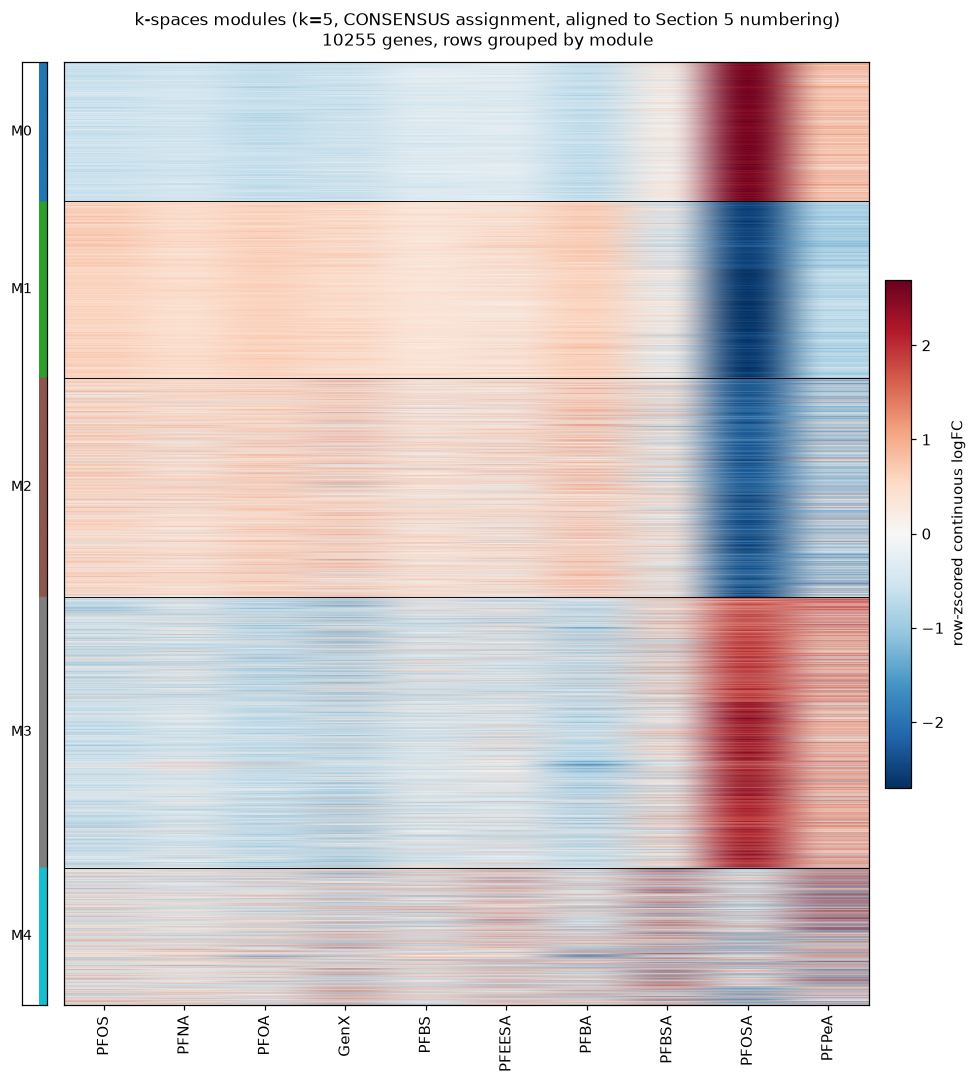

In [46]:

# heatmap, rebuilt from the consensus assignment (same layout/scale as Section 6)
order_c = assign_consensus_aligned.sort_values().index
mat_sorted_c = matrix_primary[col_order].loc[order_c]
modules_sorted_c = assign_consensus_aligned.loc[order_c]

n_modules_c = modules_sorted_c.nunique()
fig, (ax_strip, ax_hm) = plt.subplots(1, 2, figsize=(9, 10), gridspec_kw={"width_ratios": [0.3, 10]}, sharey=True)
cmap_modules_c = plt.get_cmap("tab10", n_modules_c)
ax_strip.imshow(modules_sorted_c.values.reshape(-1, 1), aspect="auto", cmap=cmap_modules_c, vmin=-0.5, vmax=n_modules_c - 0.5)
ax_strip.set_xticks([]); ax_strip.set_yticks([])
boundaries_c = np.where(np.diff(modules_sorted_c.values) != 0)[0] + 1
prev = 0
for b in list(boundaries_c) + [len(modules_sorted_c)]:
    mid = (prev + b) / 2
    ax_strip.text(-1.3, mid, f"M{modules_sorted_c.values[prev]}", va="center", ha="right", fontsize=9)
    prev = b
ax_strip.set_xlim(-2.5, 0.5)

vmax_c = np.nanpercentile(np.abs(mat_sorted_c.values), 98)
im = ax_hm.imshow(mat_sorted_c.values, aspect="auto", cmap="RdBu_r", vmin=-vmax_c, vmax=vmax_c)
ax_hm.set_xticks(range(len(col_order))); ax_hm.set_xticklabels(col_order, rotation=90)
ax_hm.set_yticks([])
for b in boundaries_c:
    ax_hm.axhline(b - 0.5, color="black", linewidth=0.6)
cbar = fig.colorbar(im, ax=ax_hm, fraction=0.03, pad=0.02)
cbar.set_label("row-zscored continuous logFC")
fig.suptitle(f"k-spaces modules (k=5, CONSENSUS assignment, aligned to Section 5 numbering)\n"
             f"{len(mat_sorted_c)} genes, rows grouped by module", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "consensus_k5_heatmap.png", dpi=200)
plt.show()


In [47]:

# GO enrichment, rebuilt from the consensus assignment. Reuses the pinned
# ontology, namespace-specific eligible backgrounds, and family-wide helper.
t0 = time.time()
go_df_consensus, go_tests_consensus = familywise_go_enrichment(assign_consensus_aligned)
go_df_consensus.to_csv(ROOT / "output" / "kspaces_runs" / "go_enrichment" / "consensus_k5_GO_enrichment.csv", index=False)
print(f"Consensus GO enrichment done in {time.time()-t0:.0f}s: {len(go_tests_consensus)} total tests in one BH family; "
      f"{len(go_df_consensus)} significant displayed term-module hits "
      f"(single-fit Section 8 found {len(go_df)})")


Consensus GO enrichment done in 5s: 43075 total tests in one BH family; 216 significant displayed term-module hits (single-fit Section 8 found 216)


In [48]:

# side-by-side: top specific (non-generic) GO term per module, single-fit vs consensus
def top_specific_term(df, module, cap=GENERIC_TERM_POP_CAP):
    sub = df[(df["module"] == module) & (df["pop_count"] <= cap)].sort_values("p_fdr_bh_family")
    if len(sub):
        return f"{sub.iloc[0]['term']} (family BH={sub.iloc[0]['p_fdr_bh_family']:.1e})"
    return "(no specific term below generic-term cap)"

compare_rows = []
for m in sorted(assign_consensus_aligned.unique()):
    compare_rows.append({
        "module": m,
        "n_genes_single_fit": int((assign_primary == m).sum()),
        "n_genes_consensus": int((assign_consensus_aligned == m).sum()),
        "top_term_single_fit (Section 8)": top_specific_term(go_df, m),
        "top_term_consensus": top_specific_term(go_df_consensus, m),
    })
compare_df = pd.DataFrame(compare_rows).set_index("module")
compare_df.to_csv(ROOT / "output" / "kspaces_runs" / "go_enrichment" / "single_fit_vs_consensus_top_terms.csv")
print("Single-fit (Section 8) vs. consensus top GO term per module, side by side:")
display(compare_df)


Single-fit (Section 8) vs. consensus top GO term per module, side by side:


,n_genes_single_fit,n_genes_consensus,top_term_single_fit (Section 8),top_term_consensus
module,,,,
0,1336,1514,regulation of biological process (family BH=2....,DNA-binding transcription factor activity (fam...
1,2002,1915,protein-containing complex (family BH=1.6e-43),protein-containing complex (family BH=2.6e-40)
2,2490,2386,cytosolic large ribosomal subunit (family BH=3...,cytosolic large ribosomal subunit (family BH=7...
3,2894,2944,molecular transducer activity (family BH=1.2e-22),signaling receptor activity (family BH=6.9e-23)
4,1533,1496,immune system process (family BH=1.7e-35),defense response to symbiont (family BH=3.6e-30)


**Whether the module biology story changes is read directly from the
table above** : where the `top_term_single_fit` and `top_term_consensus`
columns name the same or closely related process for a given module, the
consensus assignment is not overturning that module's biological
characterization, only refining its gene membership; where they diverge, the
single-fit characterization in Section 8 should not be treated as settled :
**and should not be assumed to mean the same cluster's biology "changed"
either: Section 15 shows that for at least one diverging module here, the
single-fit and consensus versions share zero genes, so the two rows being
compared are not even the same underlying gene set.** Check gene-level
overlap (Section 15) before reading any divergence in this table as one
module evolving. Section 16's summary reflects both outcomes.


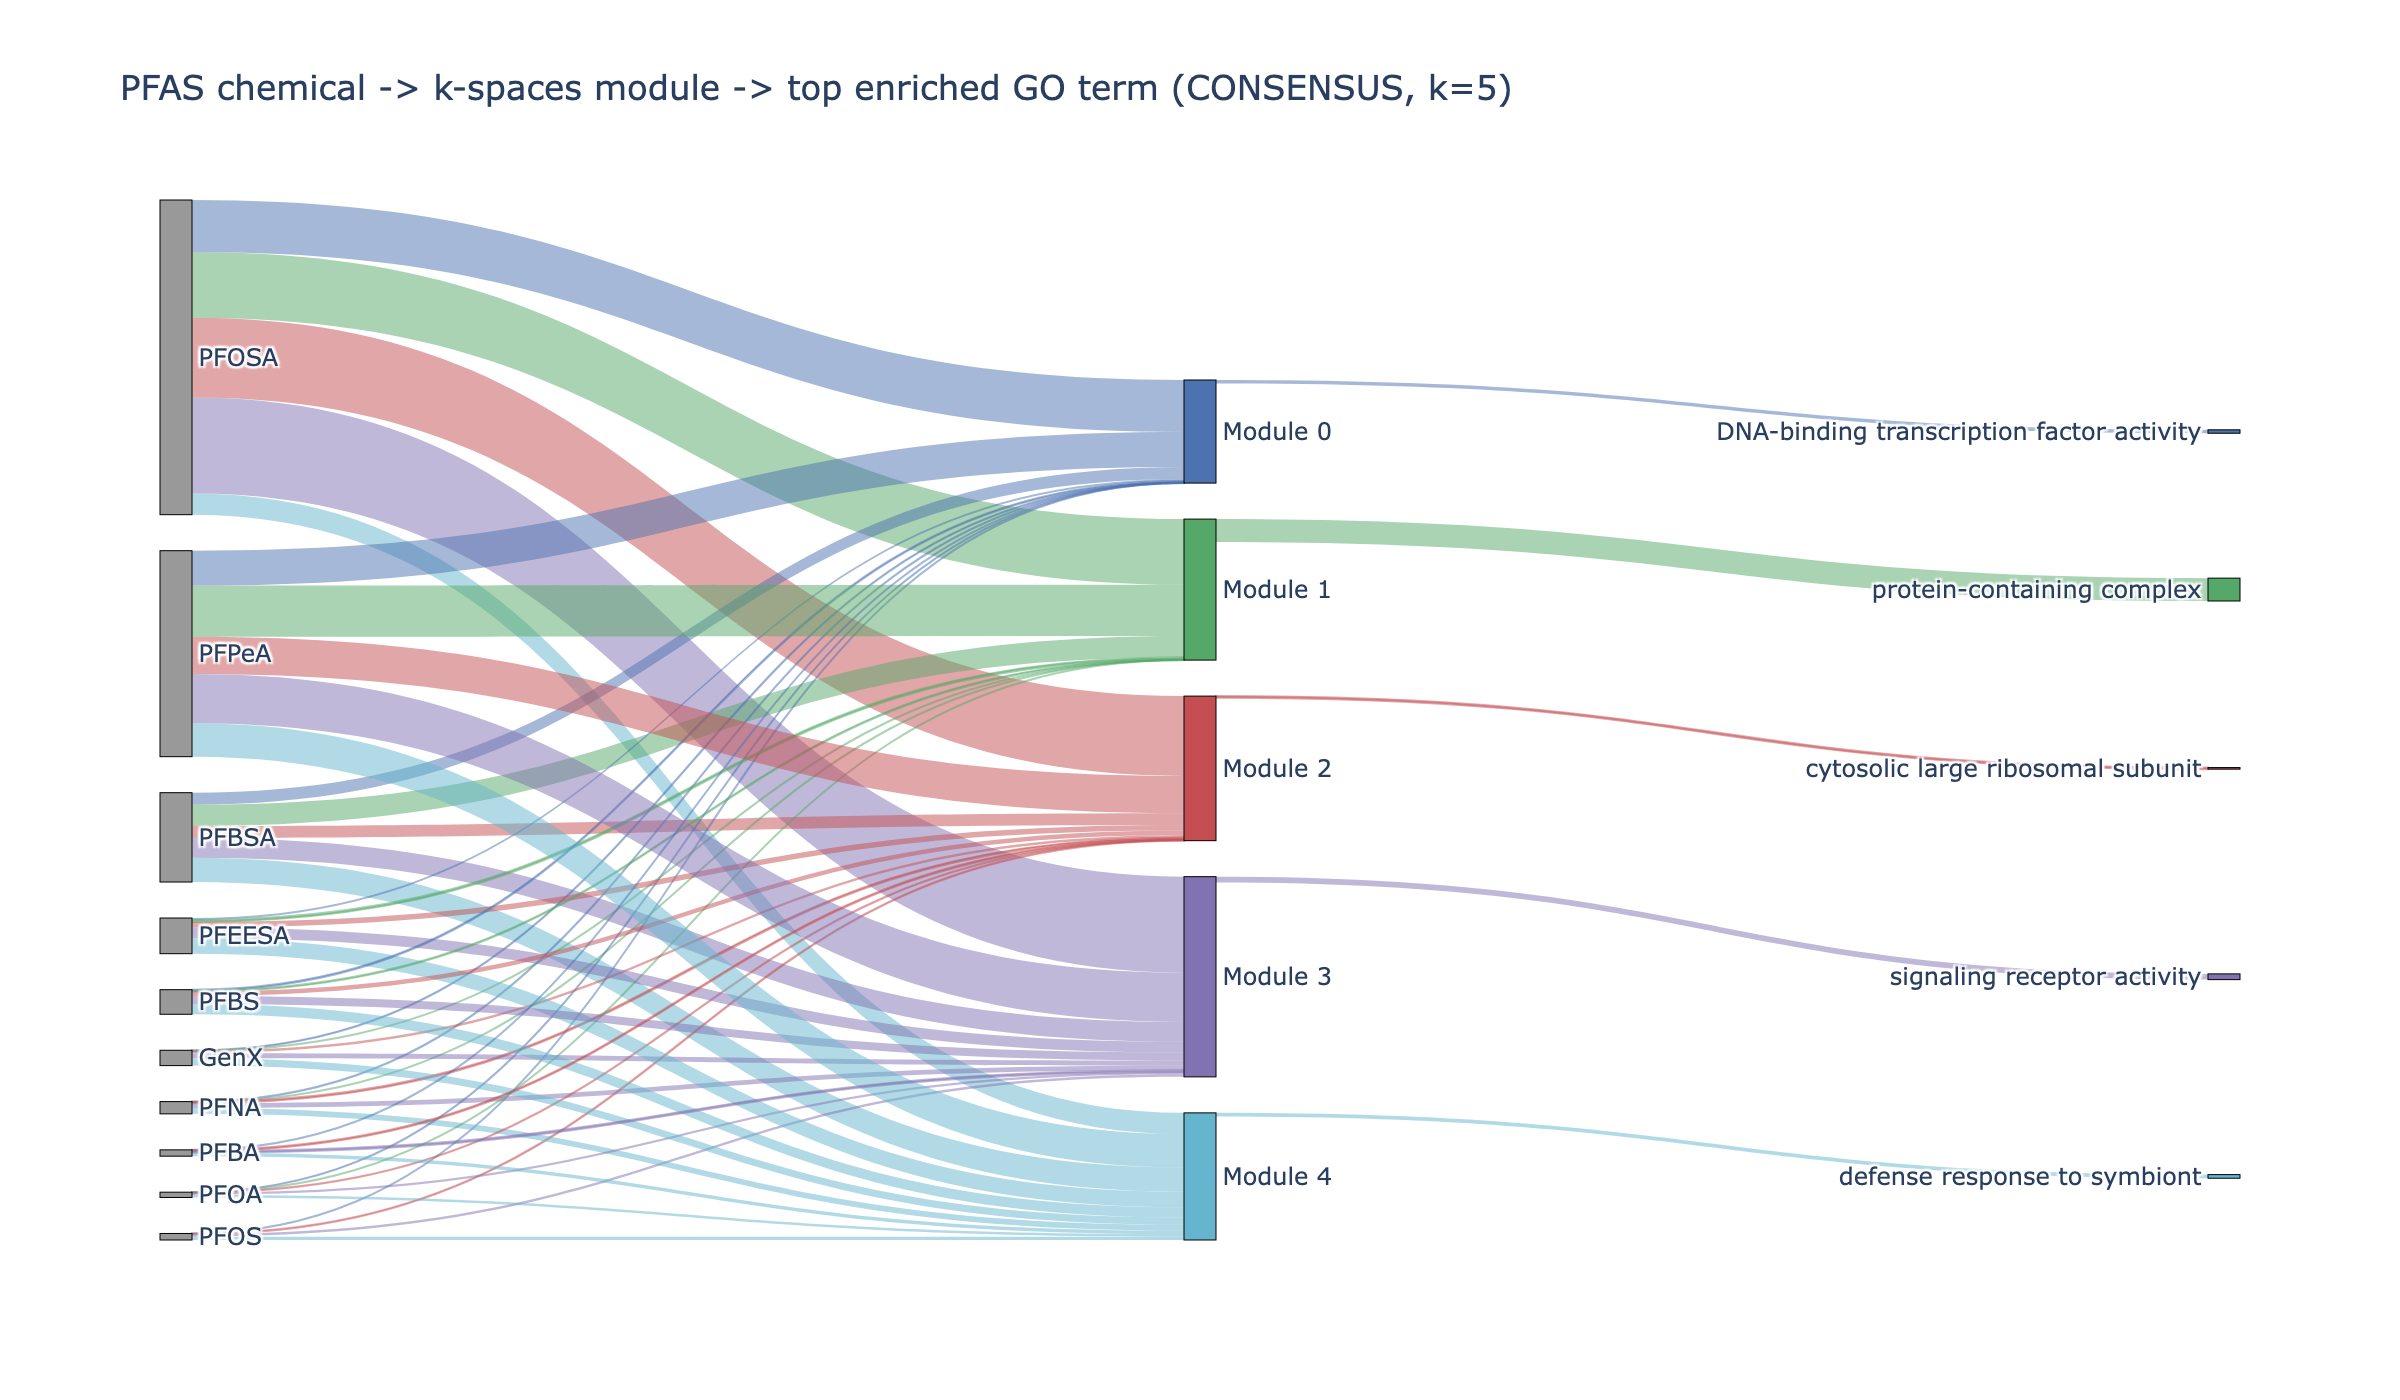

In [49]:

# Sankey, rebuilt from the consensus assignment
modules_c = sorted(assign_consensus_aligned.unique())
cm_counts_c = pd.DataFrame(0, index=CHEMICALS, columns=modules_c)
for c in CHEMICALS:
    degs = merged.index[merged[f"FDR_{c}"] < FDR_THRESHOLD]
    in_union_c = assign_consensus_aligned.loc[assign_consensus_aligned.index.intersection(degs)]
    vc_c = in_union_c.value_counts()
    for m in modules_c:
        cm_counts_c.loc[c, m] = int(vc_c.get(m, 0))

go_specific_c = go_df_consensus[go_df_consensus["pop_count"] <= GENERIC_TERM_POP_CAP].copy()
top_term_per_module_c = {}
for m in modules_c:
    sub = go_specific_c[go_specific_c["module"] == m].sort_values("p_fdr_bh_family")
    if len(sub):
        row = sub.iloc[0]
        top_term_per_module_c[m] = (row["term"], int(row["study_count"]))
    else:
        top_term_per_module_c[m] = (f"(no specific term, module {m})", int((assign_consensus_aligned == m).sum()))

module_labels_c = [f"Module {m}" for m in modules_c]
term_labels_c = [top_term_per_module_c[m][0] for m in modules_c]
nodes_c = CHEMICALS + module_labels_c + term_labels_c
node_idx_c = {name: i for i, name in enumerate(nodes_c)}

sources_c, targets_c, values_c, link_colors_c = [], [], [], []
for c in CHEMICALS:
    for j, m in enumerate(modules_c):
        v = cm_counts_c.loc[c, m]
        if v > 0:
            sources_c.append(node_idx_c[c]); targets_c.append(node_idx_c[f"Module {m}"]); values_c.append(v)
            link_colors_c.append(hex_to_rgba(module_colors[j % len(module_colors)], 0.5))
for j, m in enumerate(modules_c):
    term, count = top_term_per_module_c[m]
    sources_c.append(node_idx_c[f"Module {m}"]); targets_c.append(node_idx_c[term]); values_c.append(count)
    link_colors_c.append(hex_to_rgba(module_colors[j % len(module_colors)], 0.5))

node_colors_c = (["#999999"] * len(CHEMICALS)
                  + [module_colors[j % len(module_colors)] for j in range(len(modules_c))]
                  + [module_colors[j % len(module_colors)] for j in range(len(modules_c))])

fig_sankey_c = go.Figure(data=[go.Sankey(
    node=dict(pad=18, thickness=16, label=nodes_c, color=node_colors_c, line=dict(color="black", width=0.5)),
    link=dict(source=sources_c, target=targets_c, value=values_c, color=link_colors_c),
)])
fig_sankey_c.update_layout(title_text="PFAS chemical -> k-spaces module -> top enriched GO term (CONSENSUS, k=5)",
                            font_size=12, width=1200, height=700)
sankey_path_c = FIG_DIR / "sankey_chemical_module_go_consensus.png"
fig_sankey_c.write_image(str(sankey_path_c), scale=2)
display(Image(filename=str(sankey_path_c)))


### Corrected enrichment across chemicals, modules, and detection categories

Three prespecified enrichment families restore the original analytical depth: 50 chemical-by-module
detected-gene sets, ten chemical-exclusive sets, and ten chemical-shared sets. Each family uses
the namespace-mapped measured population and one BH correction across every module, chemical,
namespace, and term tested within that family. Empty or underpowered sets are recorded rather than
silently dropped. The resulting ontology panels use actual GO parent relationships; no manual
GO-slim category assignment or artificial Sankey padding is used.

,family,tested_terms,displayed_significant_terms,skipped_study_namespaces
0,chemical_by_module,170899,355,35
1,chemical_exclusive,33993,32,19
2,chemical_shared,91880,393,0


,study_id,significant_terms,chemical,module
0,PFOSA|M0,0,PFOSA,M0
1,PFOSA|M1,0,PFOSA,M1
2,PFOSA|M2,0,PFOSA,M2
3,PFOSA|M3,0,PFOSA,M3
4,PFOSA|M4,0,PFOSA,M4
5,PFBSA|M0,1,PFBSA,M0
6,PFBSA|M1,23,PFBSA,M1
7,PFBSA|M2,11,PFBSA,M2
8,PFBSA|M3,17,PFBSA,M3
9,PFBSA|M4,22,PFBSA,M4


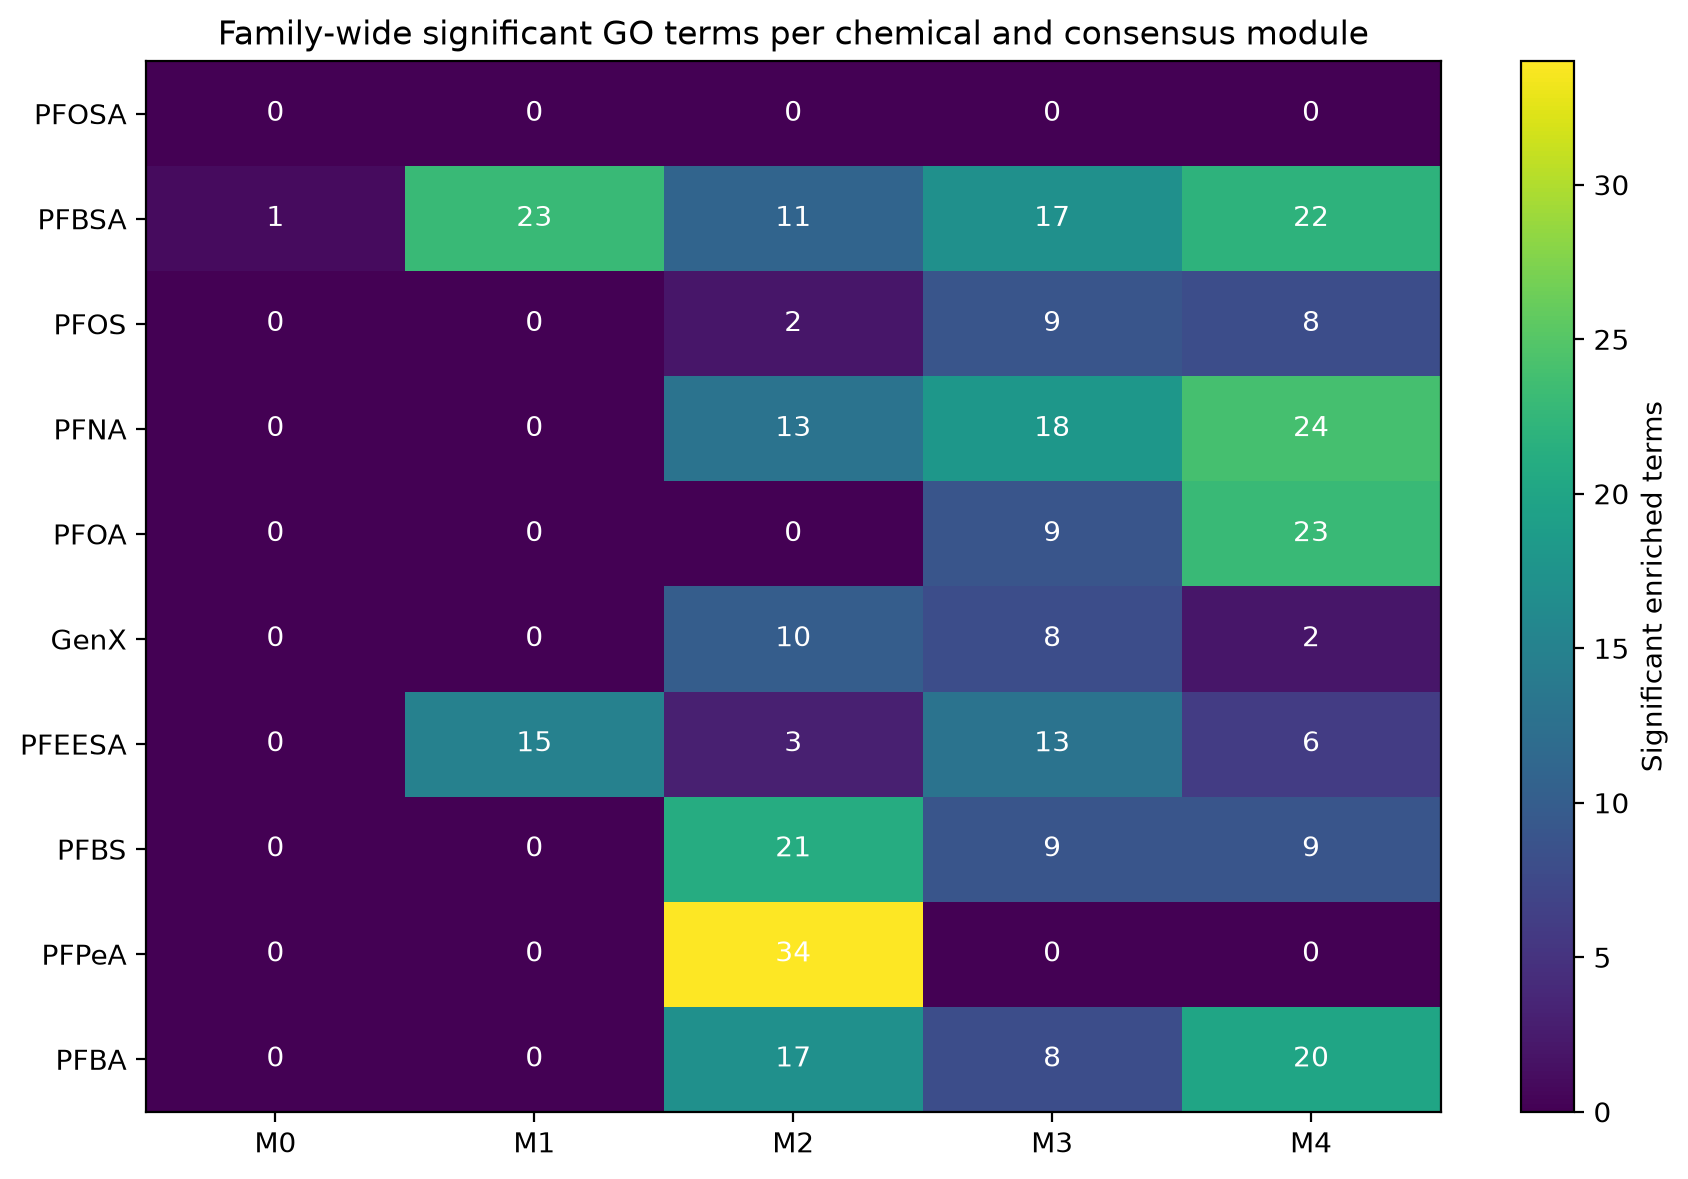

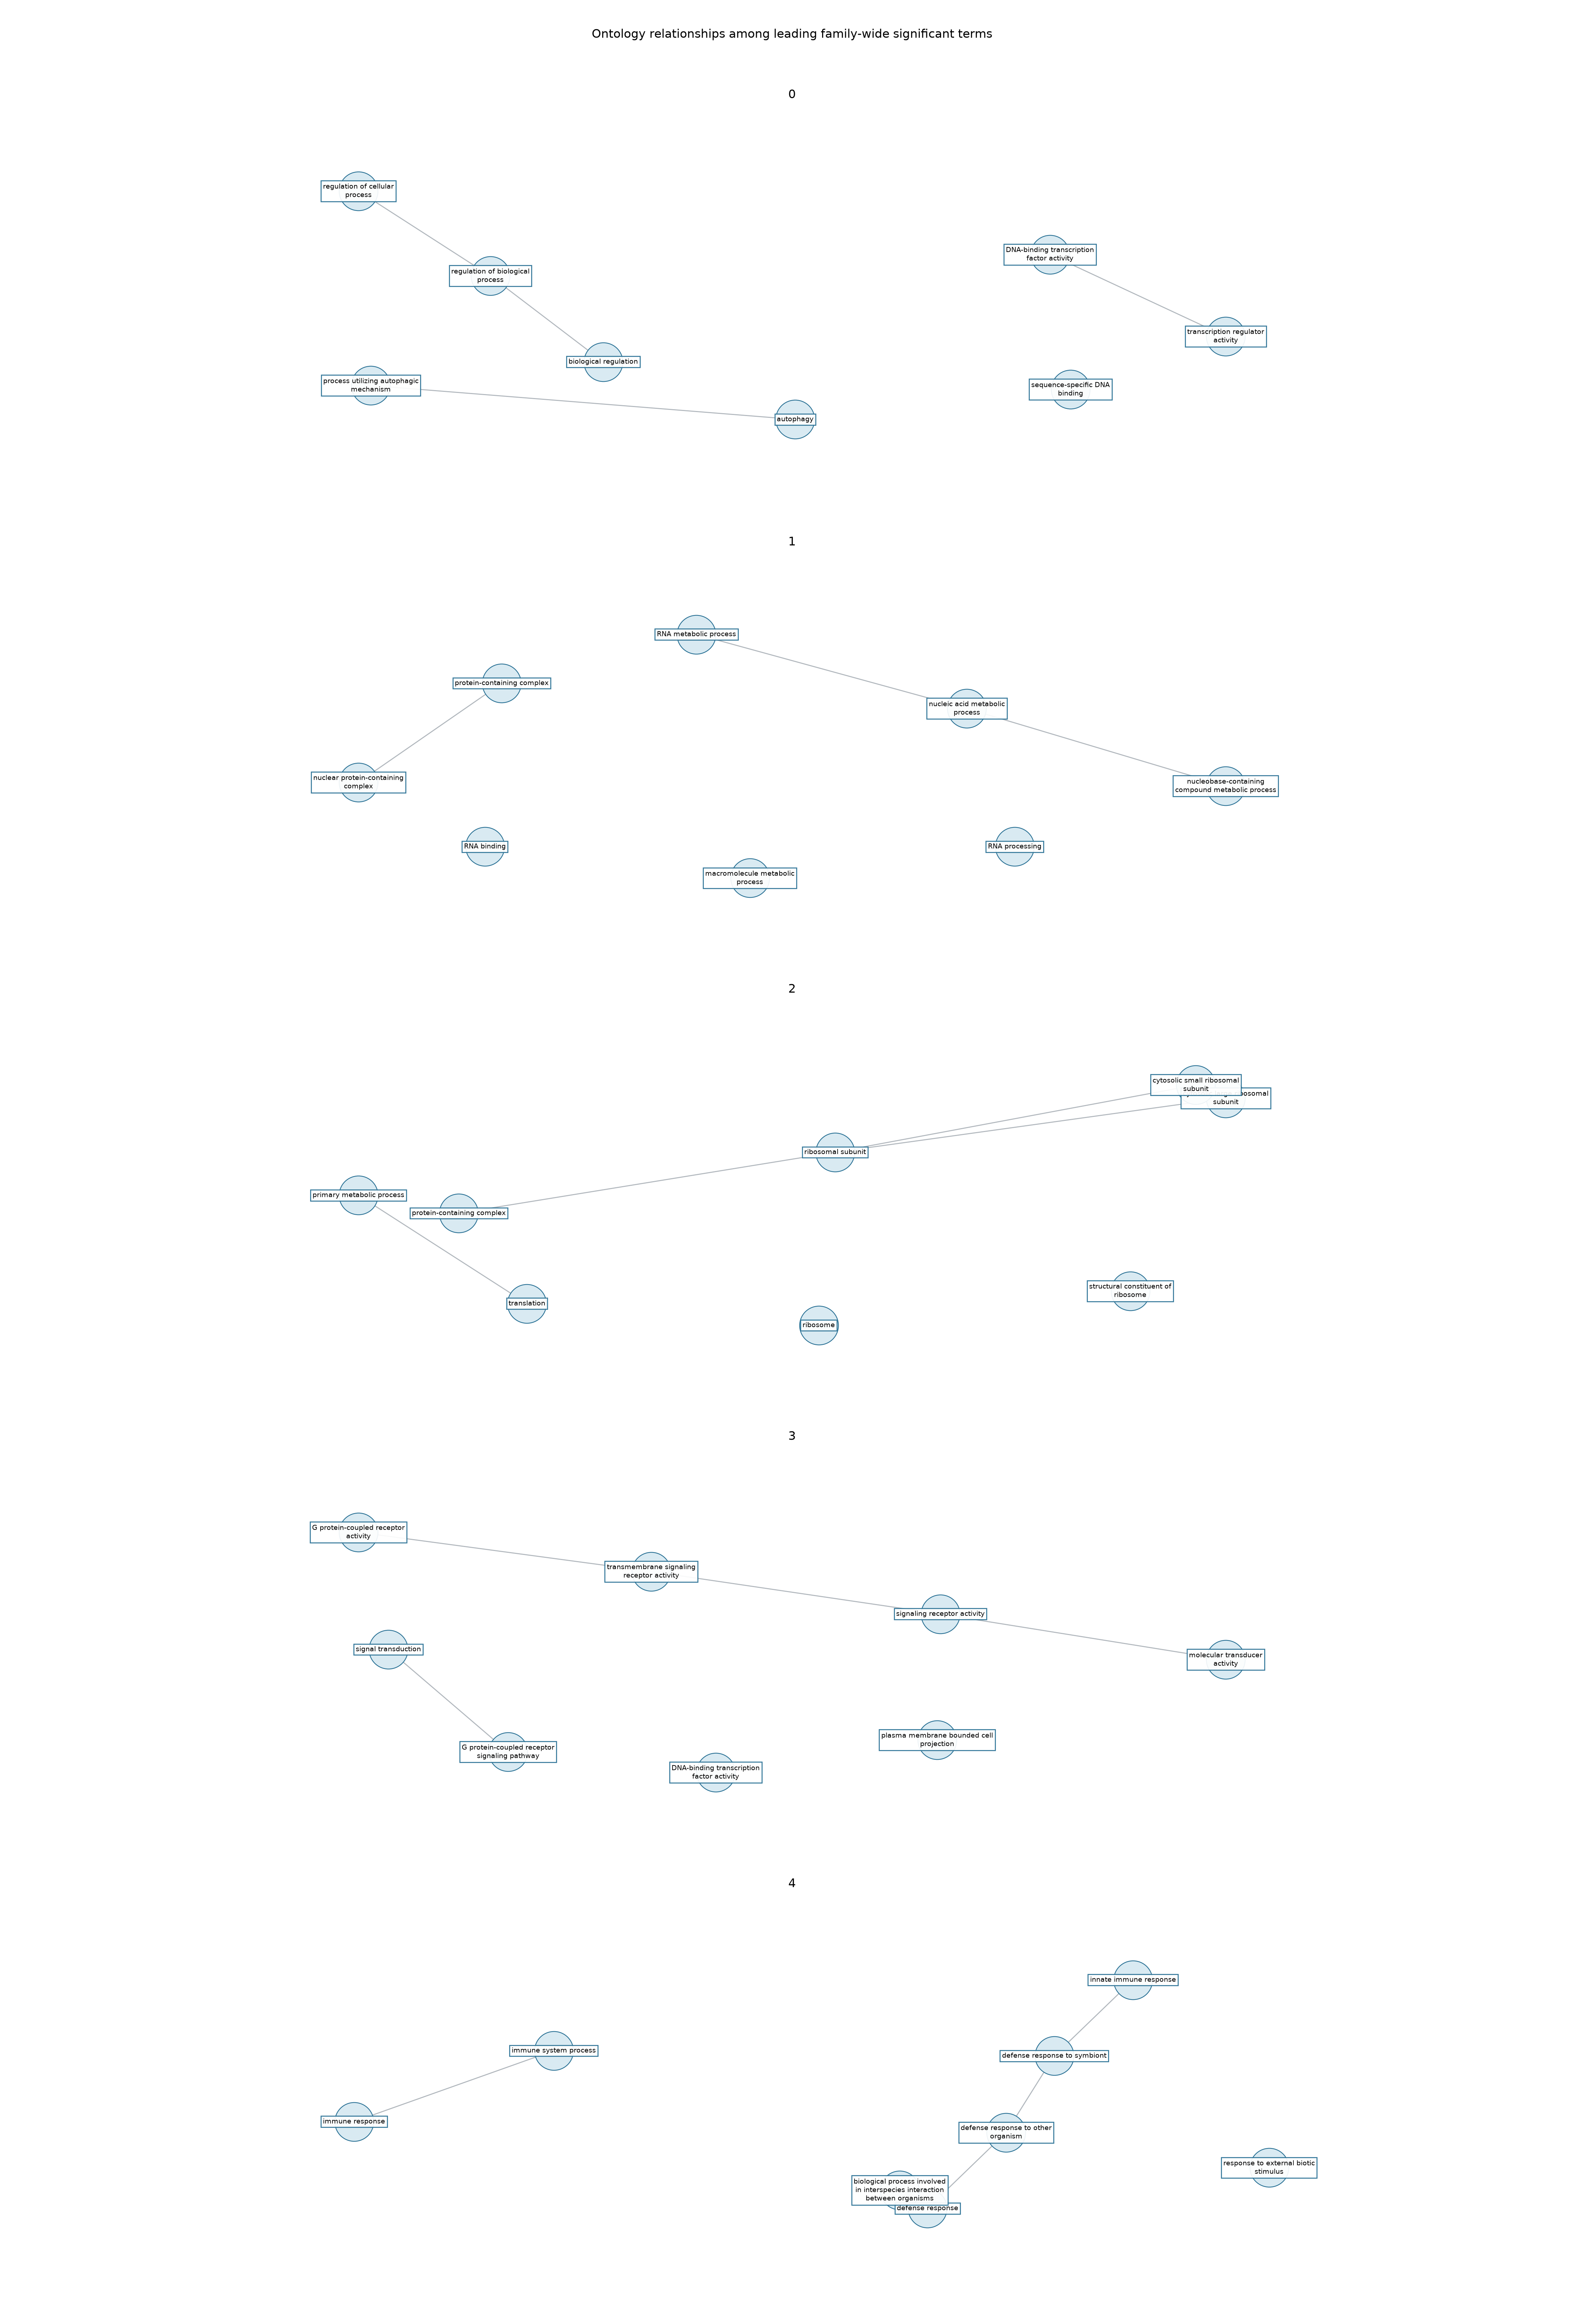

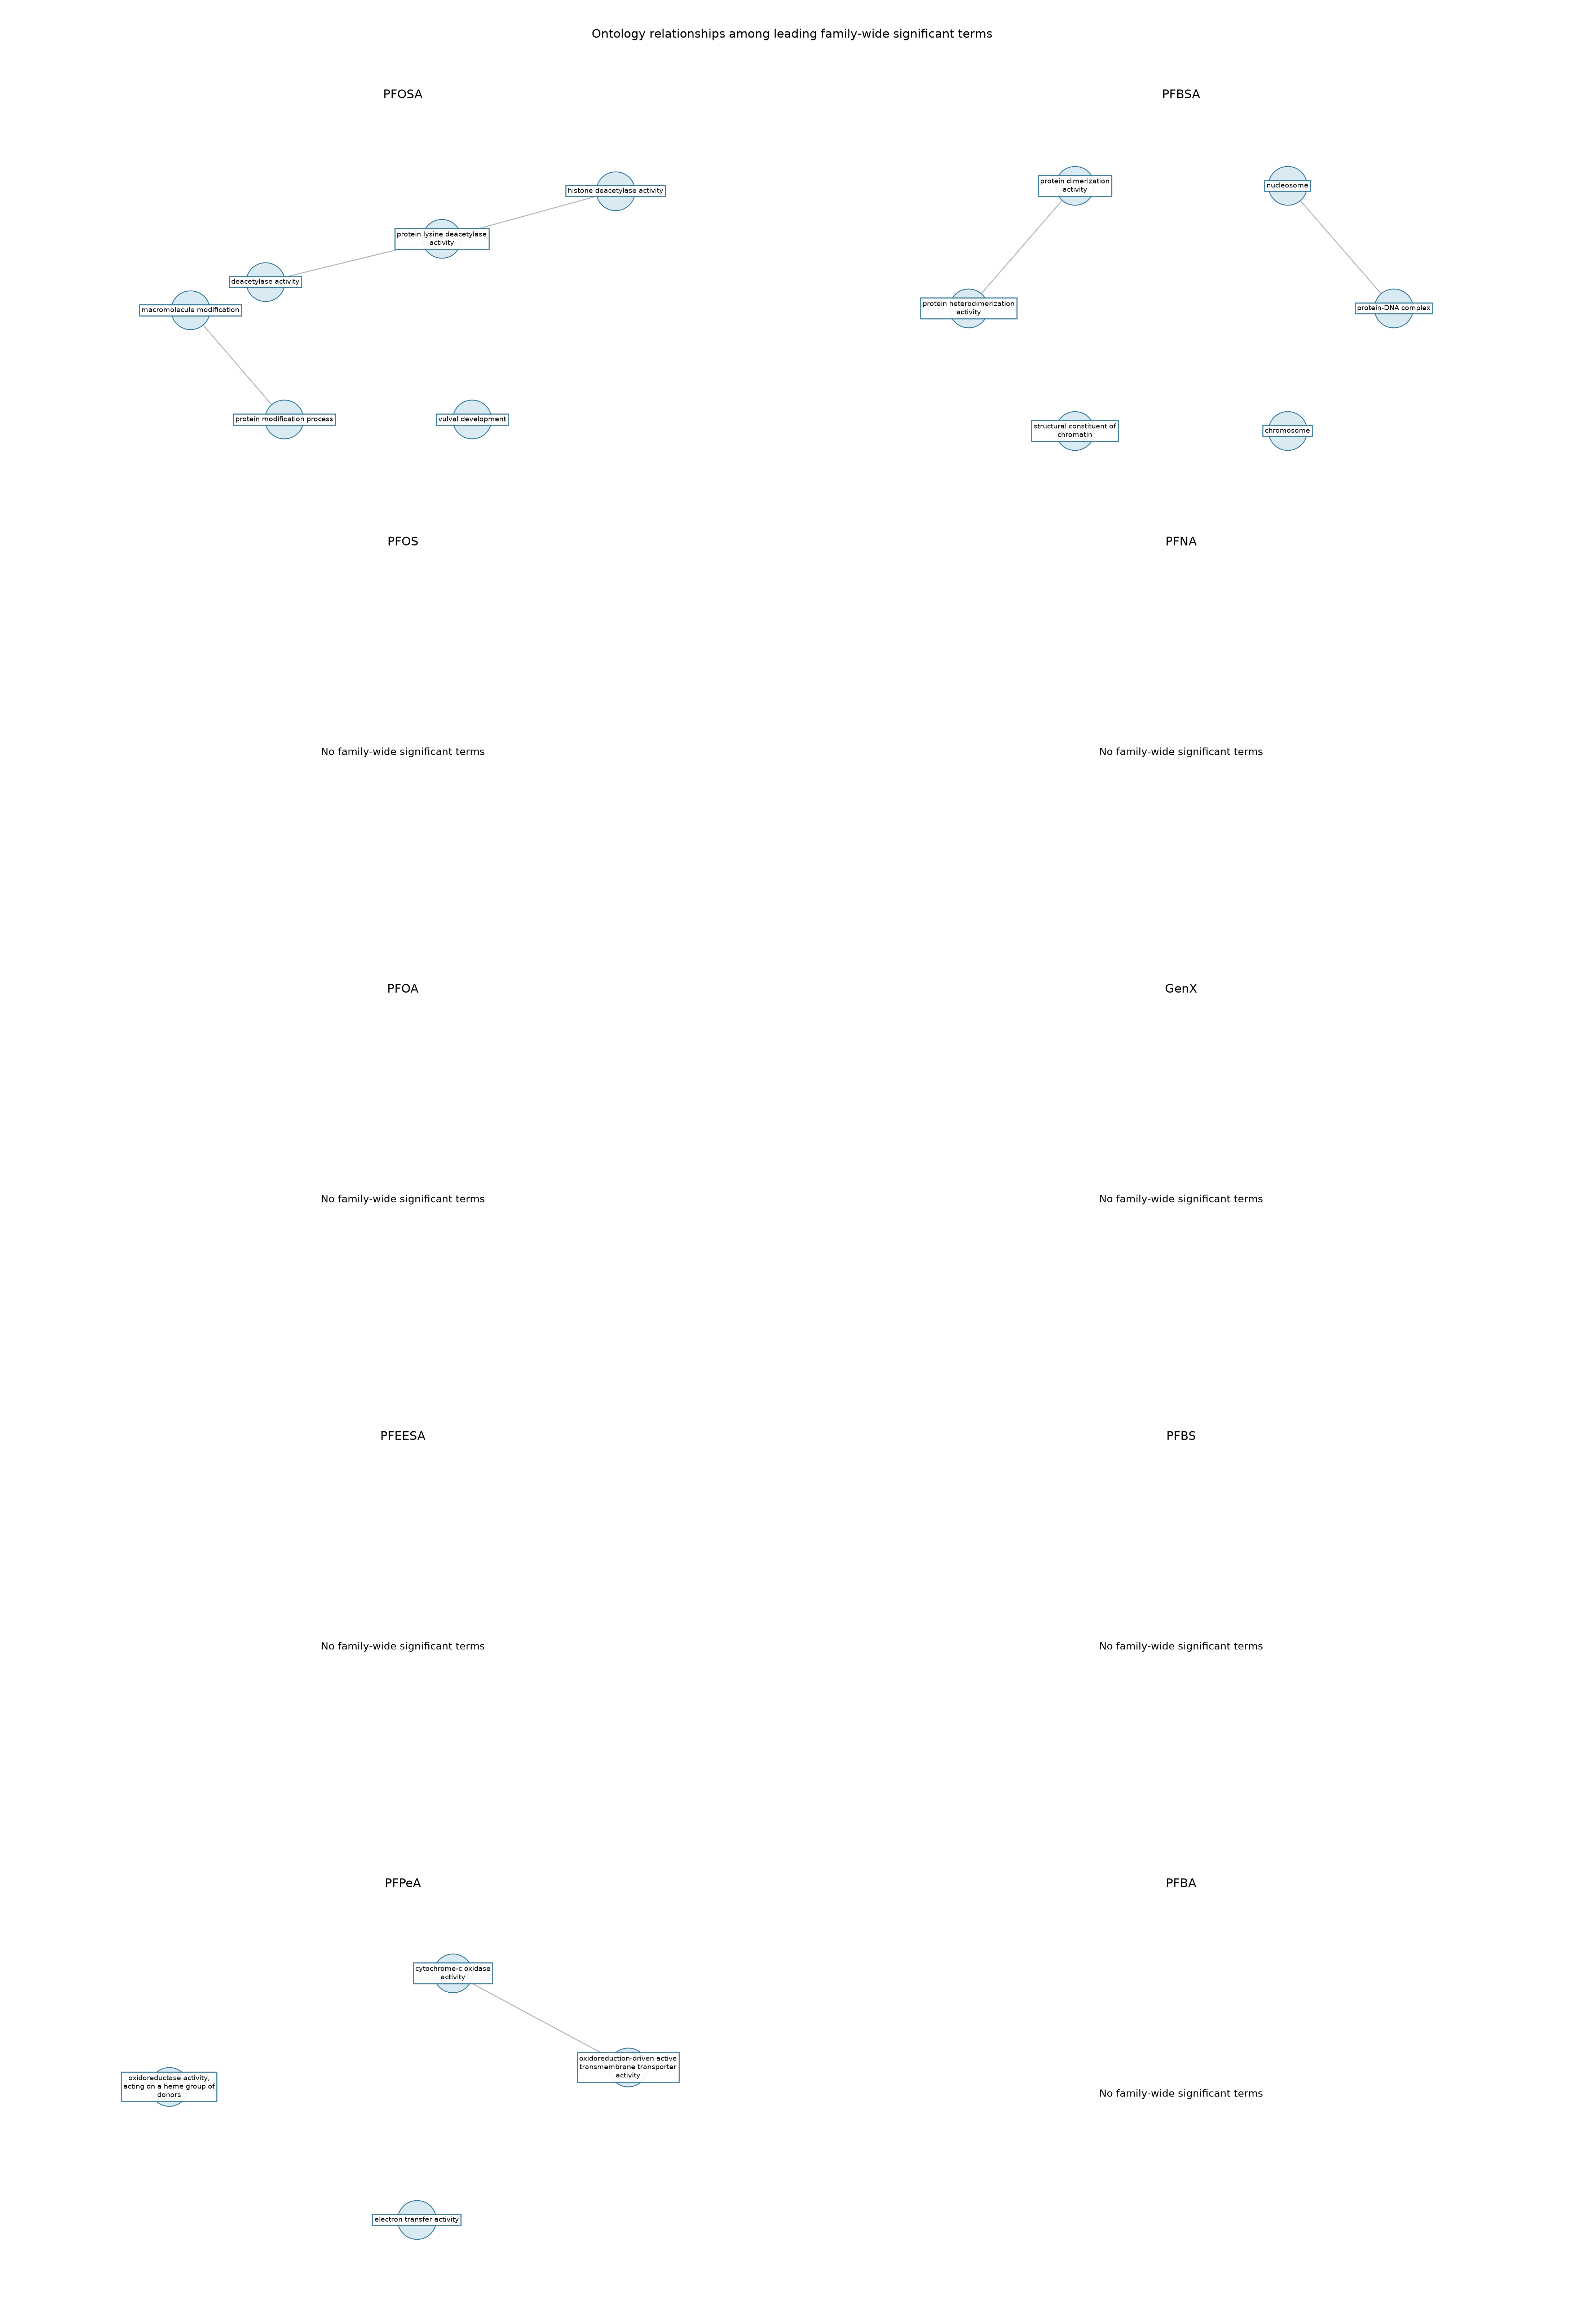

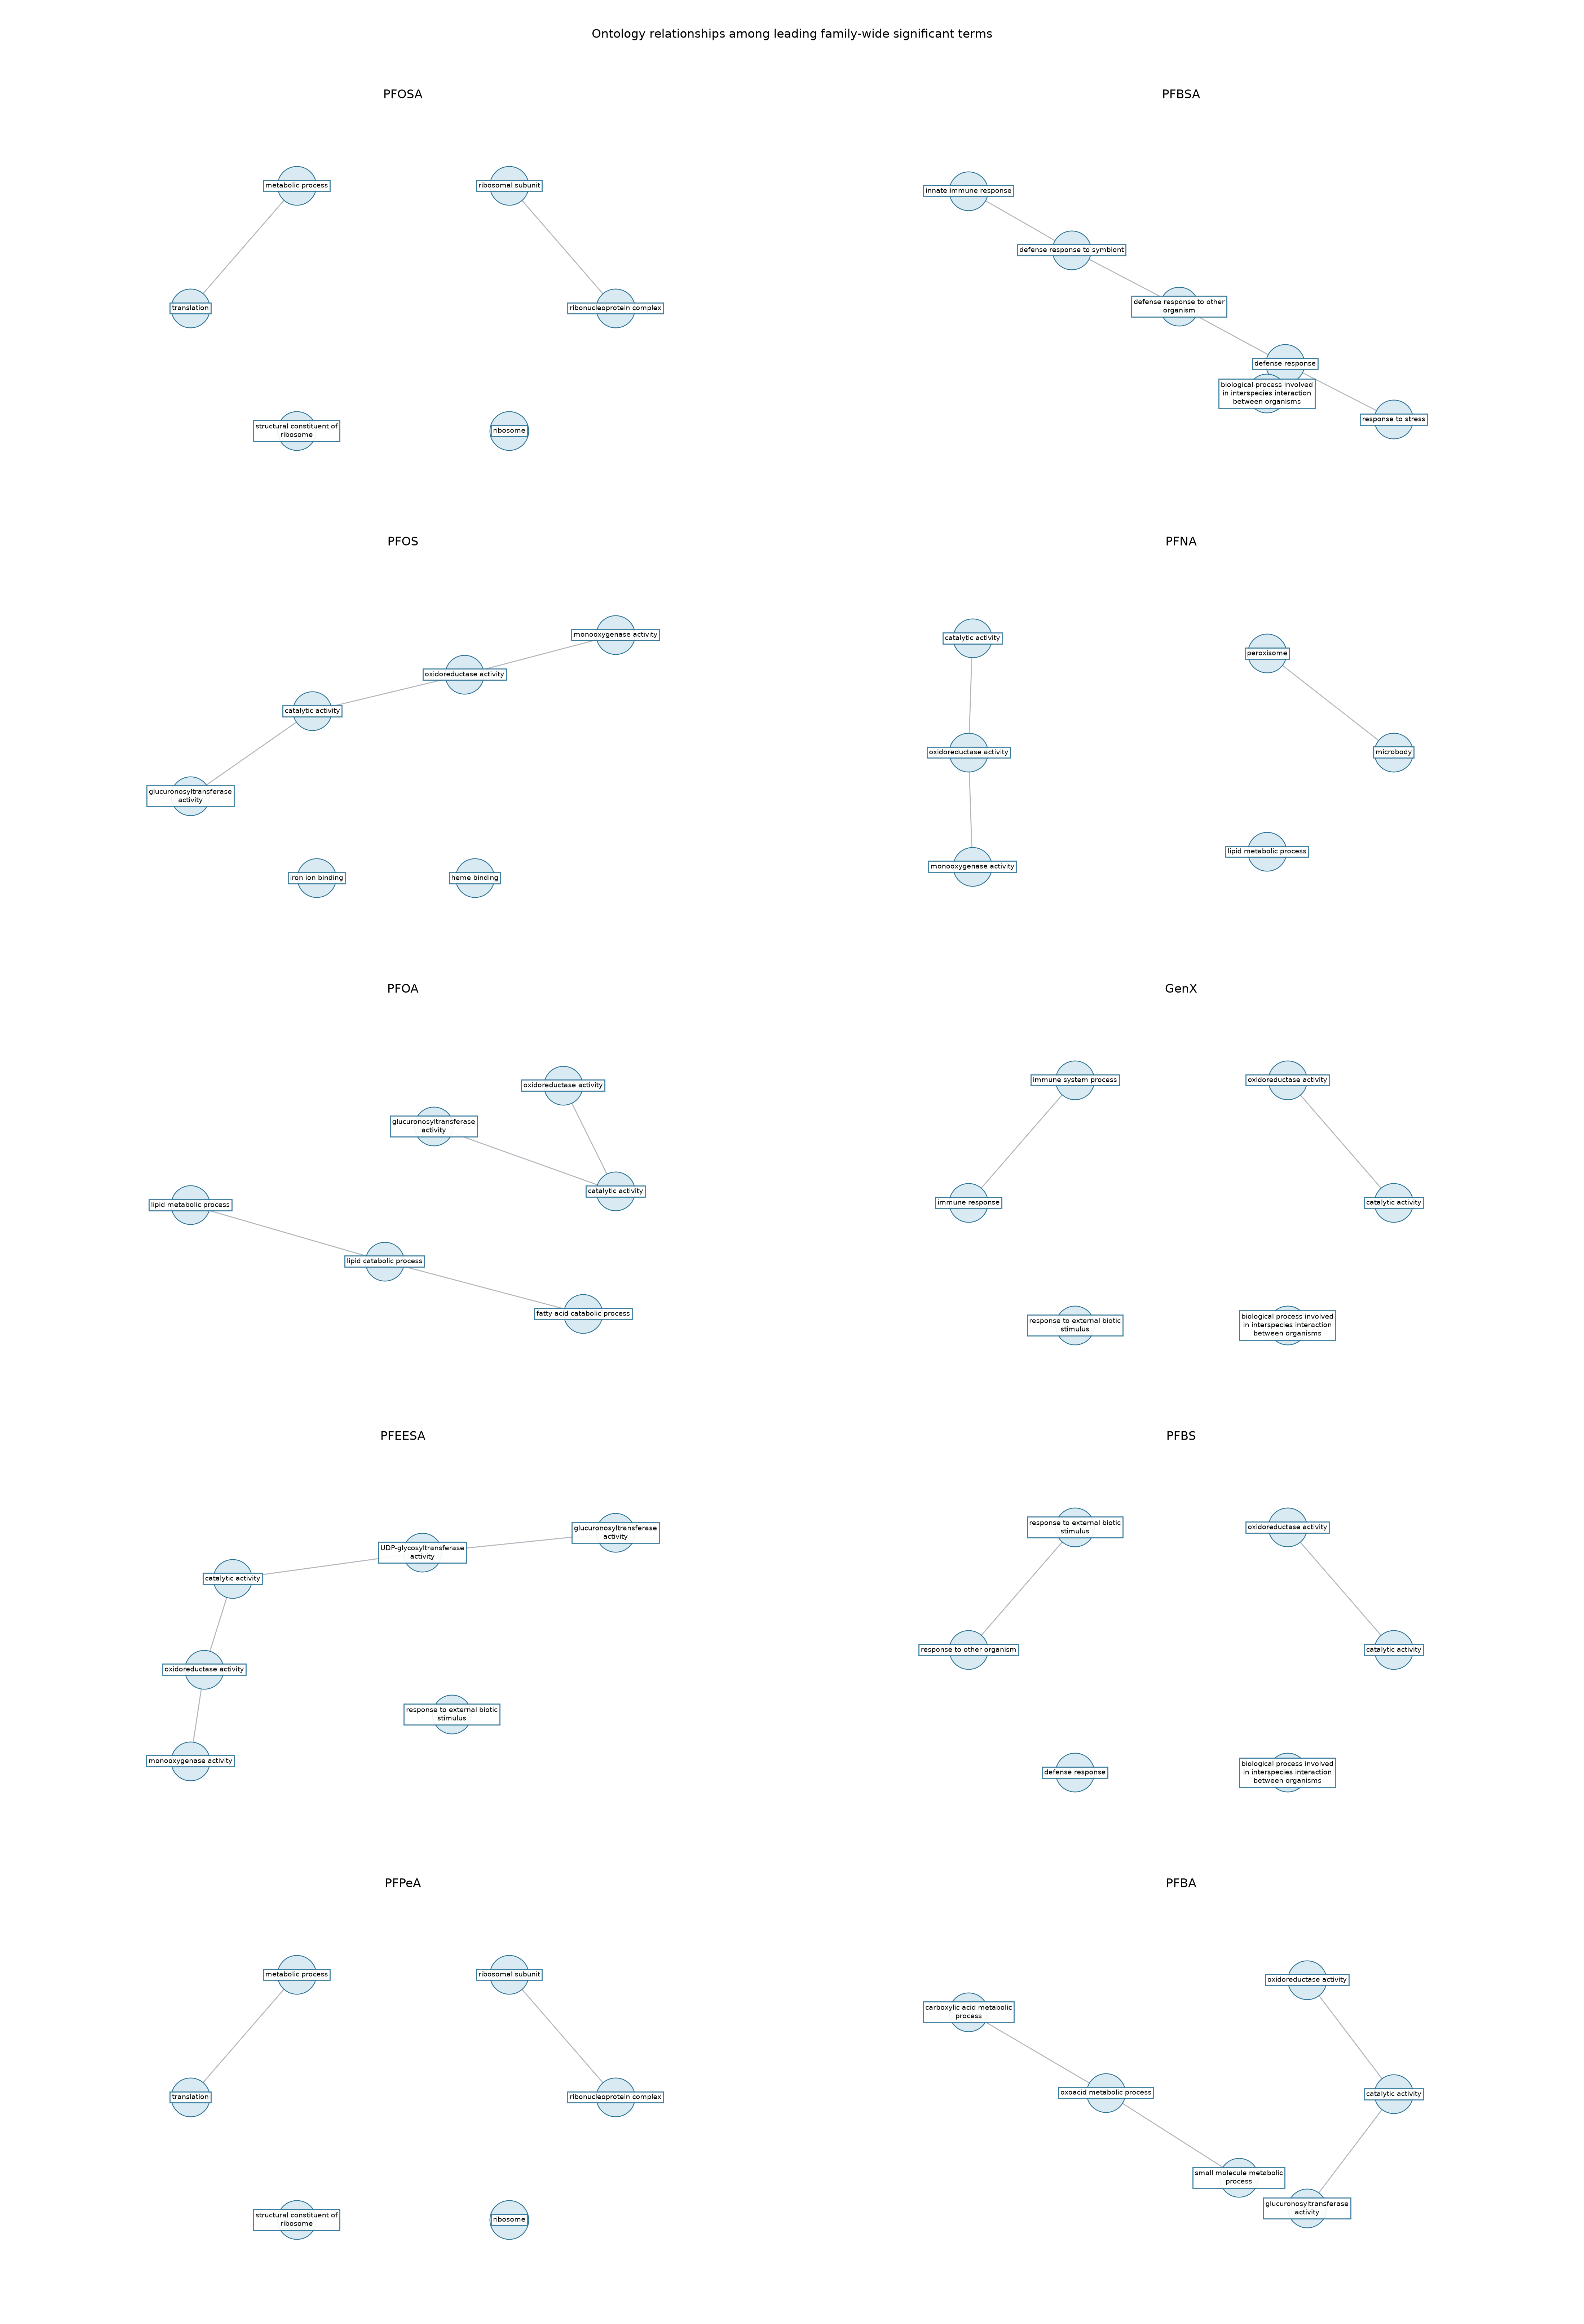

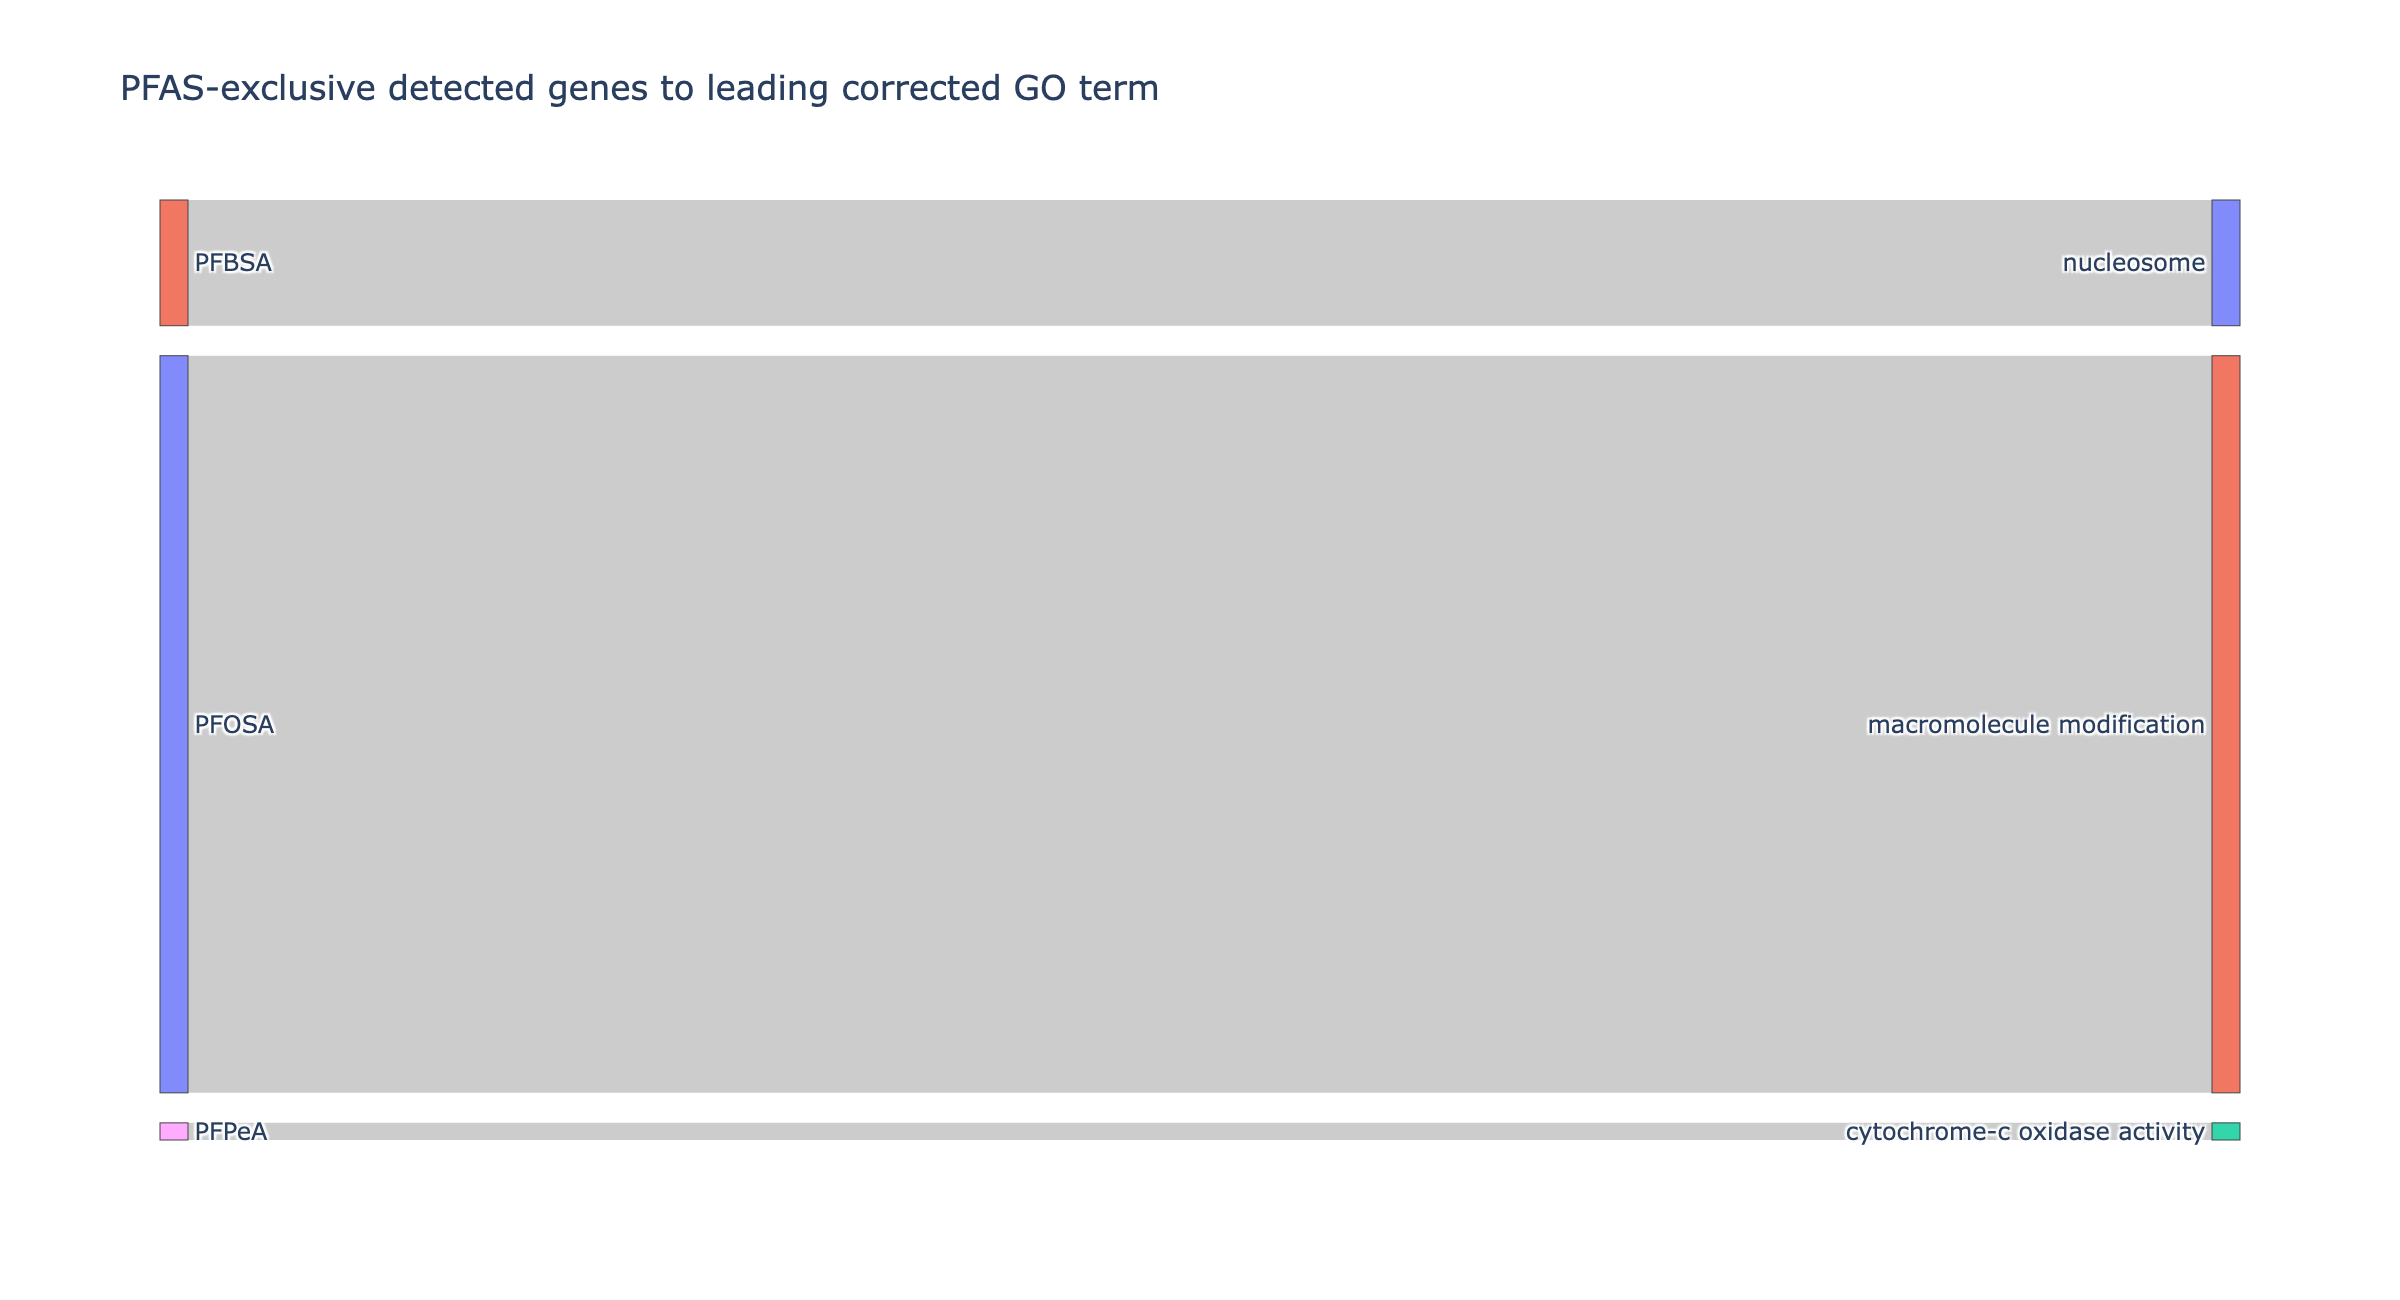

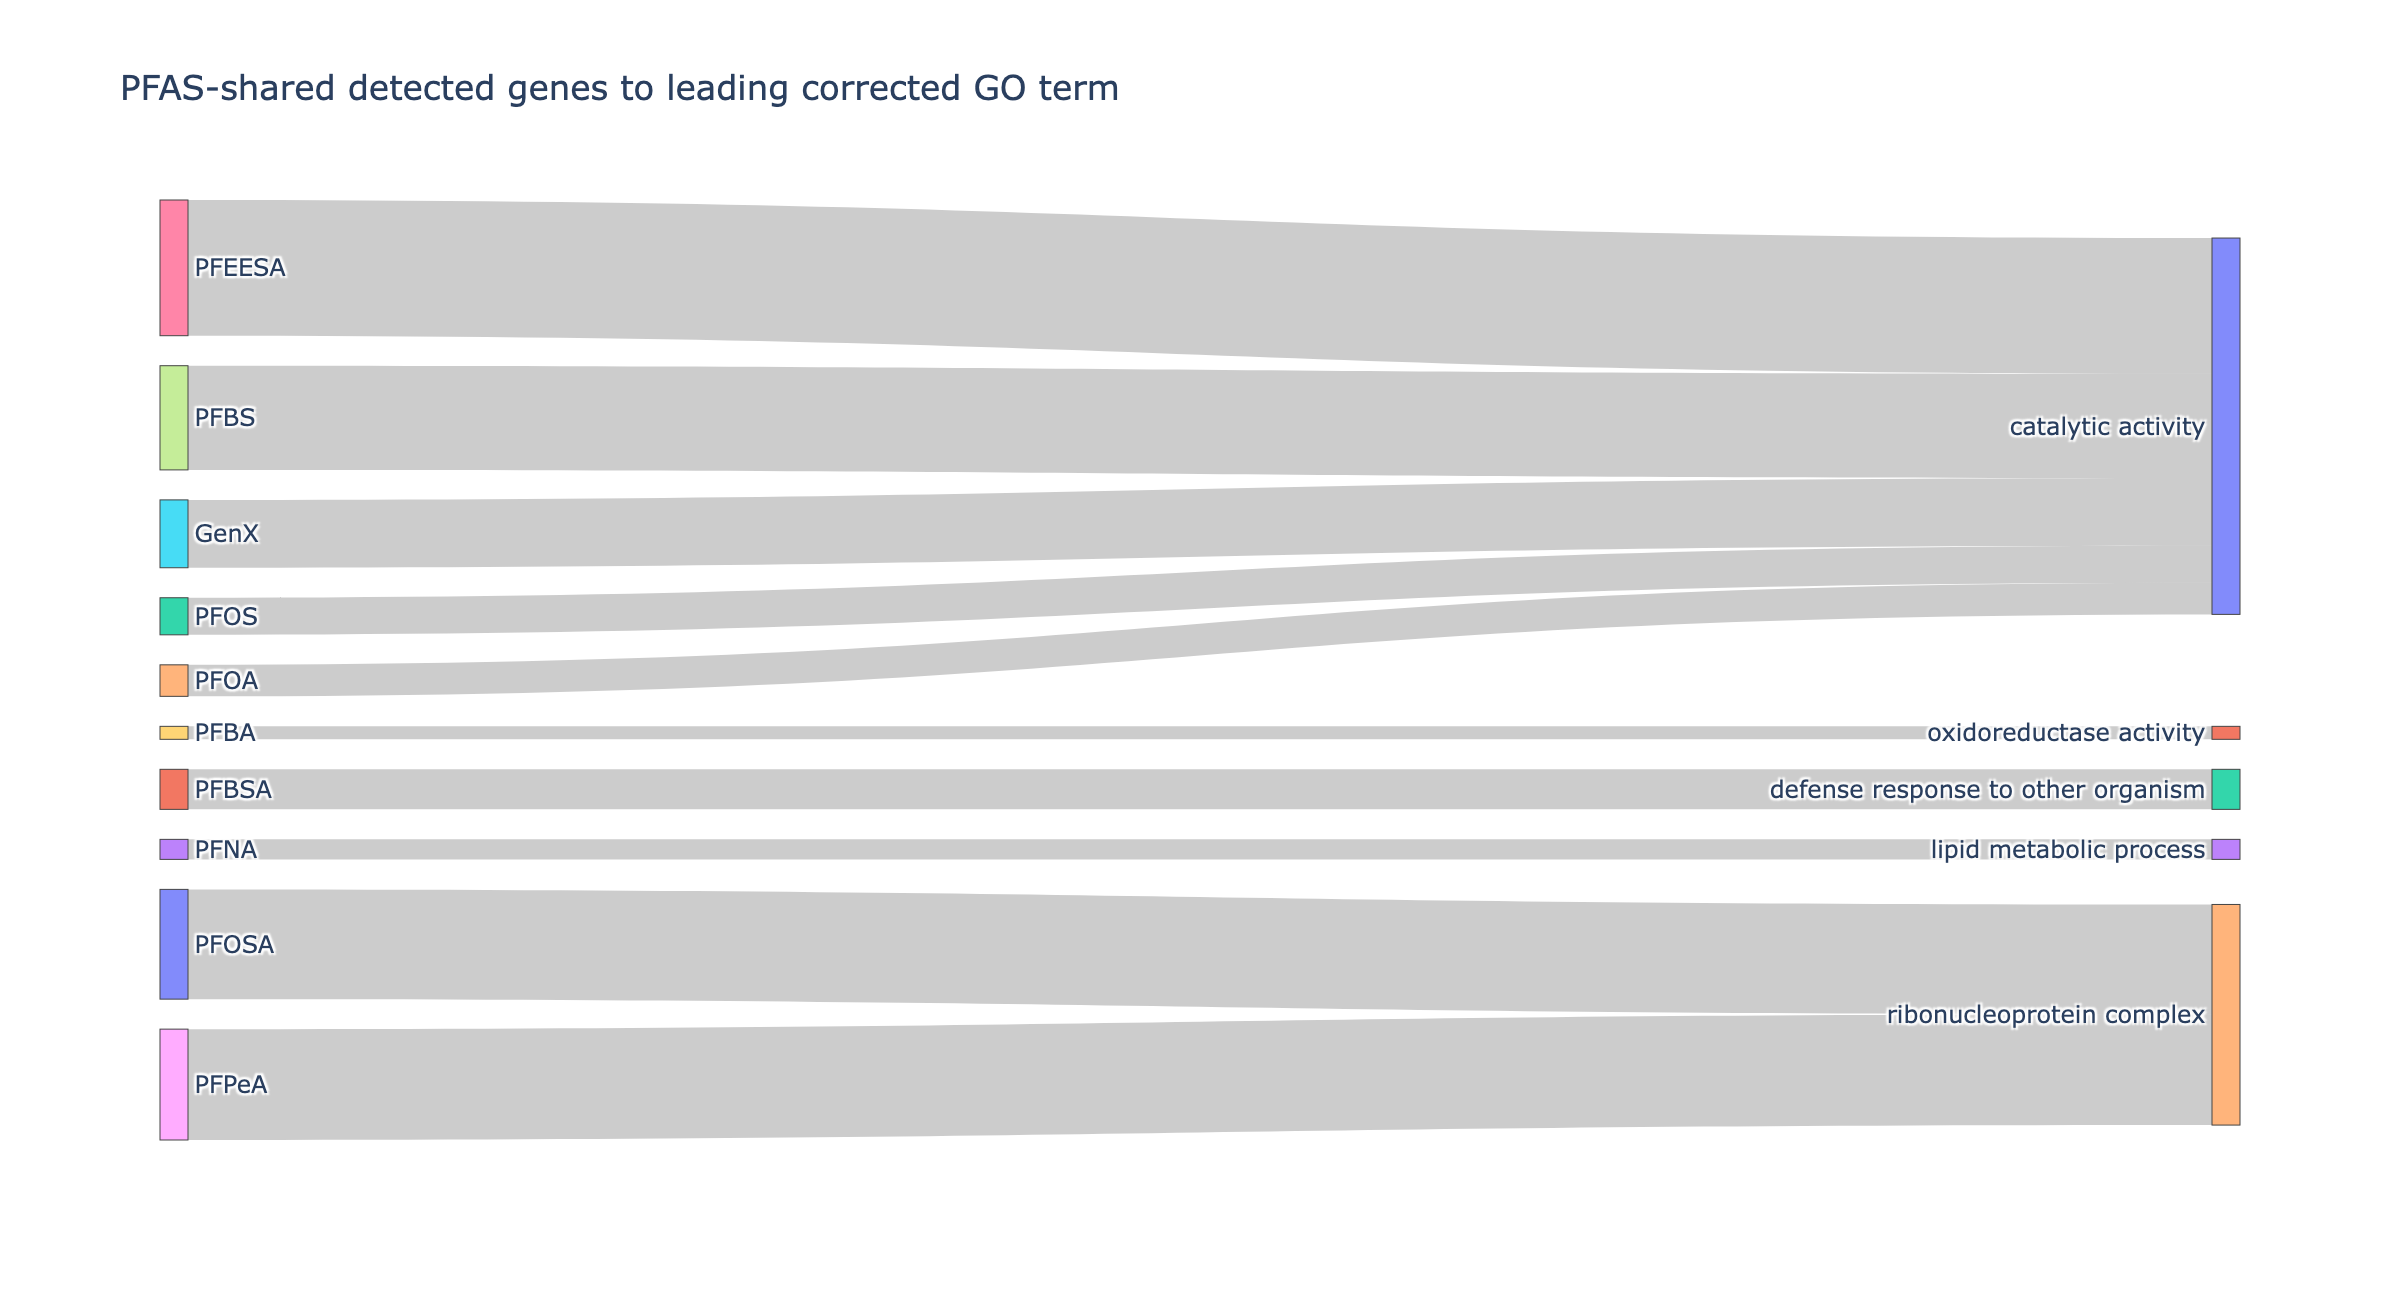

In [50]:
from pfas_master.deep_analysis import adjust_enrichment_family, plot_ontology_panels

MIN_GO_STUDY_GENES = 10

def run_enrichment_family(studies, family_name, population_mode, top_n=15):
    rows = []
    skipped = []
    with contextlib.redirect_stdout(io.StringIO()):
        for namespace, associations in ns2assoc.items():
            engine_cache = {}
            for study_id, study_genes in studies.items():
                if population_mode == 'measured':
                    population_key = 'measured'
                    population = measured_background_by_ns[namespace]
                elif population_mode == 'within_module':
                    module = int(str(study_id).split('|M')[1])
                    population_key = f'module_{module}'
                    population = sorted(
                        set(assign_consensus_aligned.index[assign_consensus_aligned == module])
                        .intersection(associations)
                    )
                else:
                    raise ValueError(f'unknown population mode: {population_mode}')
                if population_key not in engine_cache:
                    engine_cache[population_key] = GOEnrichmentStudy(
                        population, associations, godag, propagate_counts=True,
                        alpha=FDR_ALPHA, methods=['fdr_bh'],
                    )
                engine = engine_cache[population_key]
                eligible = sorted(set(study_genes).intersection(population))
                if len(eligible) < MIN_GO_STUDY_GENES:
                    skipped.append({
                        'family': family_name, 'study_id': str(study_id),
                        'namespace': namespace, 'input_genes': len(set(study_genes)),
                        'mapped_eligible_genes': len(eligible),
                        'reason': f'fewer than {MIN_GO_STUDY_GENES} mapped eligible genes',
                    })
                    continue
                for result in engine.run_study(eligible):
                    rows.append({
                        'family': family_name, 'study_id': str(study_id),
                        'namespace': namespace, 'GO_id': result.GO, 'term': result.name,
                        'enrichment': result.enrichment, 'p_raw': result.p_uncorrected,
                        'study_count': result.study_count, 'study_n': result.study_n,
                        'pop_count': result.pop_count, 'pop_n': result.pop_n,
                    })
    tested = adjust_enrichment_family(pd.DataFrame(rows))
    significant = tested[
        tested.enrichment.eq('e') & tested.p_fdr_bh_family.lt(FDR_ALPHA)
    ].sort_values(['study_id', 'namespace', 'p_fdr_bh_family'])
    displayed = significant.groupby(['study_id', 'namespace'], group_keys=False).head(top_n)
    tested.to_csv(deep_output / f'GO_{family_name}_all_tests.csv', index=False)
    displayed.to_csv(deep_output / f'GO_{family_name}_significant_top{top_n}.csv', index=False)
    skipped_df = pd.DataFrame(skipped, columns=[
        'family', 'study_id', 'namespace', 'input_genes',
        'mapped_eligible_genes', 'reason',
    ])
    skipped_df.to_csv(deep_output / f'GO_{family_name}_skipped.csv', index=False)
    return tested, displayed, skipped_df

chemical_module_studies = {}
for chemical in CHEMICALS:
    detected_genes = set(detected_matrix.index[detected_matrix[chemical]])
    for module in sorted(assign_consensus_aligned.unique()):
        module_genes = set(assign_consensus_aligned.index[assign_consensus_aligned == module])
        chemical_module_studies[f'{chemical}|M{module}'] = detected_genes.intersection(module_genes)

cm_go_tests, cm_go, cm_go_skipped = run_enrichment_family(
    chemical_module_studies, 'chemical_by_module', 'within_module'
)
unique_go_tests, unique_go, unique_go_skipped = run_enrichment_family(
    unique_gene_sets, 'chemical_exclusive', 'measured'
)
shared_go_tests, shared_go, shared_go_skipped = run_enrichment_family(
    shared_gene_sets, 'chemical_shared', 'measured'
)

cm_go_dir = deep_output / 'GO_per_chemical_per_module'
cm_go_dir.mkdir(parents=True, exist_ok=True)
for study_id, group in cm_go.groupby('study_id'):
    group.to_csv(cm_go_dir / f'{study_id.replace("|", "_")}.csv', index=False)

cm_counts = (
    cm_go.groupby('study_id').size().reindex(chemical_module_studies, fill_value=0)
    .rename('significant_terms').reset_index()
)
cm_counts[['chemical', 'module']] = cm_counts.study_id.str.split('|', expand=True)
cm_heat = cm_counts.pivot(index='chemical', columns='module', values='significant_terms').reindex(CHEMICALS)
fig, ax = plt.subplots(figsize=(9, 6))
image = ax.imshow(cm_heat, aspect='auto', cmap='viridis')
ax.set_xticks(range(cm_heat.shape[1]), cm_heat.columns)
ax.set_yticks(range(len(cm_heat)), cm_heat.index)
ax.set_title('Family-wide significant GO terms per chemical and consensus module')
for row in range(cm_heat.shape[0]):
    for column in range(cm_heat.shape[1]):
        ax.text(column, row, int(cm_heat.iloc[row, column]), ha='center', va='center', color='white')
fig.colorbar(image, ax=ax, label='Significant enriched terms')
fig.tight_layout()
fig.savefig(deep_figures / 'GO_per_chemical_per_module_heatmap.png', dpi=200, bbox_inches='tight')
plt.close(fig)

plot_ontology_panels(
    go_df_consensus, 'module', sorted(go_df_consensus.module.unique()), godag,
    deep_figures / 'ontology_trees_consensus_modules.png', top_n=8,
)
plot_ontology_panels(
    unique_go.assign(chemical=unique_go.study_id), 'chemical', list(CHEMICALS), godag,
    deep_figures / 'ontology_trees_exclusive_by_chemical.png', top_n=6,
)
plot_ontology_panels(
    shared_go.assign(chemical=shared_go.study_id), 'chemical', list(CHEMICALS), godag,
    deep_figures / 'ontology_trees_shared_by_chemical.png', top_n=6,
)

def gene_set_sankey(enrichment, title, stem):
    best = enrichment.sort_values('p_fdr_bh_family').groupby('study_id', as_index=False).first()
    chemicals = list(CHEMICALS)
    terms = list(dict.fromkeys(best.term.tolist()))
    nodes = chemicals + terms
    node_index = {name: index for index, name in enumerate(nodes)}
    figure = go.Figure(go.Sankey(
        node={'label': nodes, 'pad': 15, 'thickness': 14},
        link={
            'source': [node_index[row.study_id] for row in best.itertuples()],
            'target': [node_index[row.term] for row in best.itertuples()],
            'value': [max(int(row.study_count), 1) for row in best.itertuples()],
        },
    ))
    figure.update_layout(title_text=title, width=1200, height=650)
    figure.write_html(deep_figures / f'{stem}.html')
    figure.write_image(deep_figures / f'{stem}.png', scale=2)
    return figure

exclusive_sankey = gene_set_sankey(
    unique_go, 'PFAS-exclusive detected genes to leading corrected GO term',
    'sankey_exclusive_DEGs_to_GO',
)
shared_sankey = gene_set_sankey(
    shared_go, 'PFAS-shared detected genes to leading corrected GO term',
    'sankey_shared_DEGs_to_GO',
)

display(pd.DataFrame({
    'family': ['chemical_by_module', 'chemical_exclusive', 'chemical_shared'],
    'tested_terms': [len(cm_go_tests), len(unique_go_tests), len(shared_go_tests)],
    'displayed_significant_terms': [len(cm_go), len(unique_go), len(shared_go)],
    'skipped_study_namespaces': [len(cm_go_skipped), len(unique_go_skipped), len(shared_go_skipped)],
}))
display(cm_counts)
display(Image(filename=str(deep_figures / 'GO_per_chemical_per_module_heatmap.png')))
display(Image(filename=str(deep_figures / 'ontology_trees_consensus_modules.png')))
display(Image(filename=str(deep_figures / 'ontology_trees_exclusive_by_chemical.png')))
display(Image(filename=str(deep_figures / 'ontology_trees_shared_by_chemical.png')))
display(Image(filename=str(deep_figures / 'sankey_exclusive_DEGs_to_GO.png')))
display(Image(filename=str(deep_figures / 'sankey_shared_DEGs_to_GO.png')))

### Reactome provenance boundary

Historical Reactome images exist, but the repository does not contain a versioned Reactome gene-set
collection, complete producing tables, or sufficient provenance to recompute them consistently.
They remain in the legacy audit and are not presented as corrected results. Adding Reactome requires
a pinned, legally usable gene-set release and a declared multiple-testing family; it is not replaced
with live web enrichment during a supposedly reproducible notebook run.

### Reassessment of the historical glutathione-transferase label

The earlier single-fit analysis highlighted a top GO label containing “glutathione transferase.”
Because the corrected continuous-effect primary matrix can change both module membership and
family-wide significant terms, the notebook tests whether that label is recovered instead of
assuming a fixed module number. Absence is a non-replication result, not an execution error.

In [51]:
term_column = 'top_term_single_fit (Section 8)'
target_hits = compare_df.index[
    compare_df[term_column].str.contains('glutathione transferase', case=False, na=False)
]
historical_term_check = {
    'query': 'glutathione transferase',
    'recovered_among_corrected_top_terms': bool(len(target_hits)),
    'matching_modules': [int(value) for value in target_hits],
    'interpretation': (
        'Proceed to membership-overlap review before comparing labels.'
        if len(target_hits)
        else 'The historical top-term claim does not reproduce under the corrected primary matrix and GO family.'
    ),
}
display(pd.Series(historical_term_check, name='historical_term_reassessment').to_frame())

,historical_term_reassessment
query,glutathione transferase
recovered_among_corrected_top_terms,False
matching_modules,[]
interpretation,The historical top-term claim does not reprodu...


### Scientific synthesis and interpretation boundaries

Consensus assignments replace single-fit labels for interpretation. Corrected residual analyses
show condition-associated structure but do not support the original raw-correlation rankings.
Functional terms and cross-condition pairs remain exploratory where clustering or annotation
uncertainty has not been fully propagated. Raw counts and complete sample metadata
are unavailable, so reproducibility begins with the canonical edgeR contrast tables.

## 8. Predictive Modeling and Stability Assessment

A shared modeling contract verifies workflow-request classification through independent neural
network implementations. Both backends use identical features, group-disjoint partitions,
preprocessing, capacity, seeds, early stopping, checkpoints, metrics, and prediction records.
This synthetic dataset tests implementation parity; it is isolated from PFAS data and supports
no biological claim.

In [52]:
configured_system_python = os.environ.get('PFAS_SYSTEM_PYTHON')
venv_system_python = SYSTEM_ROOT / '.venv' / 'bin' / 'python'
system_python = Path(configured_system_python) if configured_system_python else venv_system_python
if not system_python.exists():
    system_python = Path(sys.executable)
parity_dir = SYSTEM_ROOT / 'artifacts' / 'framework_parity_notebook'
subprocess.run(
    [str(system_python), '-m', 'ml_frameworks', '--smoke', '--framework', 'both',
     '--output', str(parity_dir)],
    cwd=SYSTEM_ROOT,
    env={**os.environ, 'PYTHONPATH': str(SYSTEM_ROOT)},
    check=True,
)
parity_path = parity_dir / 'parity_report.json'
parity = json.loads(parity_path.read_text(encoding='utf-8'))
backend_rows = []
for backend, result in parity['results'].items():
    backend_rows.append({
        'backend': backend,
        'version': result['framework_version'],
        'seed': result['seed'],
        'parameters': result['parameter_count'],
        'epochs': result['epochs_completed'],
        'held_out_accuracy': result['metrics']['accuracy'],
        'held_out_macro_f1': result['metrics']['macro_f1'],
        'error_count': len(result['errors']),
        'checkpoint': result['checkpoint'],
    })
display(pd.Series(parity['dataset'], name='shared_contract').to_frame())
display(pd.DataFrame(backend_rows))
print('Differences on 16 synthetic held-out records test implementation consistency, not backend superiority.')

${DEV_ENV}/integrated_system/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2026-09-04 13:32:18.228793: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


{
  "blockers": {},
  "dataset": {
    "generator": "synthetic_template_v1",
    "labels": [
      "dge_summary",
      "module_analysis",
      "provenance_check",
      "refusal"
    ],
    "leakage_checks": {
      "exact_duplicates": 0,
      "group_overlap": 0
    },
    "record_count": 80,
    "seed": 2026,
    "sha256": "50fbe16fa2bcc79fc9831bd47c836c4ab88deec5e713e8386bb71a65437a740e",
    "split_counts": {
      "test": 16,
      "train": 48,
      "validation": 16
    }
  },
  "results": {
    "pytorch": {
      "best_validation_loss": 1.1334686279296875,
      "checkpoint": "${REPO_ROOT}/integrated_system/artifacts/framework_parity_notebook/pytorch_checkpoint.pt",
      "epochs_completed": 3,
      "errors": [
        {
          "expected": "provenance_check",
          "predicted": "refusal",
          "text": "for the report, verify the source files for GenX"
        },
        {
          "expected": "provenance_check",
          "predicted": "dge_summary",
          "te

,shared_contract
generator,synthetic_template_v1
labels,"[dge_summary, module_analysis, provenance_chec..."
leakage_checks,"{'exact_duplicates': 0, 'group_overlap': 0}"
record_count,80
seed,2026
sha256,50fbe16fa2bcc79fc9831bd47c836c4ab88deec5e713e8...
split_counts,"{'test': 16, 'train': 48, 'validation': 16}"


,backend,version,seed,parameters,epochs,held_out_accuracy,held_out_macro_f1,error_count,checkpoint
0,pytorch,2.7.0,2026,2092,3,0.875,0.861111,2,${HOME}/Documents/pfas-toxicogen...
1,tensorflow,2.20.0,2026,2092,3,1.000,1.000000,0,${HOME}/Documents/pfas-toxicogen...


Differences on 16 synthetic held-out records test implementation consistency, not backend superiority.


## 9. Evidence-Grounded Analysis Planning

The planning entry point interprets a request, checks compatibility, retrieves reviewed evidence,
emits a structured workflow, validates parameters and scientific rules, detects unsupported
claims, and requires human approval. Missing metadata, nonexistent entities, incompatible
operations, insufficient evidence, and unsafe conclusions trigger clarification or abstention.

Model adaptation is restricted to request routing and structured-plan support. Its synthetic,
group-partitioned records do not alter retrieval, scientific validation, or human review.

In [53]:
from pfas_workflow.catalog import ArtifactCatalog
from pfas_workflow.models import BiologicalRequest
from pfas_workflow.planner import RuleBasedPlanner
from llm_system.corpus import build_corpus

catalog = ArtifactCatalog(PROJECT)
planner = RuleBasedPlanner(catalog)
supported_plan = planner.plan(BiologicalRequest(
    question='Compare GenX and PFEESA using the corrected exploratory pair analysis'
))
unsupported_plan = planner.plan(BiologicalRequest(
    question='Prove that PFOS causes human liver cancer from the worm DGE tables'
))
display(pd.Series(supported_plan.model_dump(mode='json'), name='review_ready_plan').to_frame())
display(pd.Series(unsupported_plan.model_dump(mode='json'), name='abstained_plan').to_frame())

corpus_chunks = build_corpus()
evidence_inventory = pd.DataFrame([
    {
        'source_id': chunk.source_id,
        'source_path': chunk.relative_path,
        'source_sha256': chunk.source_sha256,
        'chunk_id': chunk.chunk_id,
        'heading': chunk.heading,
    }
    for chunk in corpus_chunks
])
display(
    evidence_inventory.groupby(['source_id', 'source_path', 'source_sha256'])
    .size().rename('reviewed_chunks').reset_index()
)
display(pd.DataFrame([citation.model_dump() for citation in supported_plan.citations]))

# This is a deterministic validation fixture, not a real scientific approval.
# Live execution stops here until an external reviewer records a signed decision.
validation_fixture = {
    'fixture_type': 'deterministic plan-validation example',
    'plan_digest': supported_plan.review_digest(),
    'schema_valid': True,
    'execution_status': 'not executed: external scientific approval required',
    'approval_claimed': False,
}
display(pd.Series(validation_fixture, name='validation_fixture').to_frame())

adaptation_path = SYSTEM_ROOT / 'llm_system' / 'training_output' / 'metrics.json'
run_adaptation = os.environ.get('PFAS_RUN_MODEL_ADAPTATION', '0') == '1'
if run_adaptation:
    subprocess.run(
        [str(system_python), '-m', 'llm_system.finetune', '--max-steps', '20'],
        cwd=SYSTEM_ROOT,
        env={**os.environ, 'PYTHONPATH': str(SYSTEM_ROOT)},
        check=True,
    )
if adaptation_path.exists():
    adaptation_metrics = json.loads(adaptation_path.read_text())
    adaptation_metrics['execution_mode'] = (
        'regenerated in this run' if run_adaptation else
        'previous bounded artifact; set PFAS_RUN_MODEL_ADAPTATION=1 to regenerate'
    )
    display(pd.Series(adaptation_metrics, name='adaptation_run').to_frame())
else:
    print('No adaptation artifact is present. Set PFAS_RUN_MODEL_ADAPTATION=1 to run the bounded path.')

,review_ready_plan
schema_version,2.0
status,ready_for_review
analysis,exploratory_pair_lookup
chemicals,"[GenX, PFEESA]"
gene_ids,[]
parameters,{}
steps,[Load the corrected residual-similarity sensit...
reason,"The request is compatible, evidence-grounded, ..."
citations,"[{'evidence_id': 'corrected-similarity', 'sour..."
findings,"[{'code': 'retracted_predecessor', 'severity':..."


,abstained_plan
schema_version,2.0
status,abstained
analysis,None
chemicals,[]
gene_ids,[]
parameters,{}
steps,[]
reason,These observational analyses cannot establish ...
citations,[]
findings,"[{'code': 'unsupported_claim', 'severity': 'er..."


,source_id,source_path,source_sha256,reviewed_chunks
0,dataset_schema,integrated_system/docs/DATASET_SCHEMA.md,35844869c54e109f8e247417f4a976f08670aec34d309a...,5
1,findings,K-spaces Analysis/FINDINGS.md,f06fb853ff44d6579301e0436c563317cbca83cb41b450...,8
2,interpretation_rules,integrated_system/docs/INTERPRETATION_RULES.md,fae97aa43800fdb8c60cba4f648163468fe3893bba5a19...,4
3,methodology,integrated_system/docs/METHODOLOGY.md,0cfddd2c81cc77aec4f03fbd3d33d6146f49e9287d5862...,7
4,reproducibility,integrated_system/docs/BASELINE_AND_REPRODUCIB...,20a5a5a12b1f2f69095f60e39e7a6382fb269c1adf717c...,8
5,scientific_audit,integrated_system/docs/SCIENTIFIC_AUDIT.md,2915c17e146460d5c3f5337d5fe07eb78de67a1f0ef01f...,4
6,scientific_sources,integrated_system/docs/SCIENTIFIC_SOURCES.md,33a567d2352943314485a4ae4af5d681e4d9d1b1f64a67...,3


,evidence_id,source,source_sha256,supports
0,corrected-similarity,K-spaces Analysis/output/kspaces_runs/residual...,1e6890d807ec3394f4279f583f5880d9924ed1a9c9d658...,corrected residual similarities retained by th...
1,method-decisions,K-spaces Analysis/FINDINGS.md,f06fb853ff44d6579301e0436c563317cbca83cb41b450...,"methodological corrections, uncertainty bounda..."


,validation_fixture
fixture_type,deterministic plan-validation example
plan_digest,d200460a6776f3903dbc33347fad3c94ea1af4f872a15f...
schema_valid,True
execution_status,not executed: external scientific approval req...
approval_claimed,False


,adaptation_run
train_runtime,44.4824
train_samples_per_second,1.439
train_steps_per_second,0.18
total_flos,10680306499584.0
train_loss,2.877283
epoch,0.211921
test_loss,2.703861
test_runtime,6.1027
test_samples_per_second,9.504
test_steps_per_second,4.752


## 10. Workflow Reliability and Scientific Quality Control

Reliability cases cover supported, ambiguous, incomplete, incompatible, statistically invalid,
and hallucinated requests. Deterministic checks assess routing, workflow validity, grounding,
citations, unsupported claims, and abstention. Automated checks do not replace scientific review.

In [54]:
from llm_system.evaluate import evaluate

quality_report = evaluate(SYSTEM_ROOT / 'llm_system' / 'eval_cases.json')
display(pd.DataFrame({
    system: result['metrics'] for system, result in quality_report['systems'].items()
}).T)
failed_cases = []
for system, result in quality_report['systems'].items():
    for case in result['cases']:
        failed = [name for name, passed in case['checks'].items() if not passed]
        if failed:
            failed_cases.append({
                'system': system, 'case': case['id'],
                'failed_checks': ', '.join(failed), 'decision': case['result']['status'],
            })
display(pd.DataFrame(failed_cases))
print((SYSTEM_ROOT / 'llm_system' / 'HUMAN_REVIEW_RUBRIC.md').read_text())

,status,intent,unsupported_claims,workflow_validity,groundedness,citation_correctness
prompt_only,1.0,1.0,1.0,1.0,0.0,0.0
rag,1.0,1.0,1.0,1.0,1.0,1.0


""


# Human review rubric

Score each accepted proposal as pass or fail, and record a short rationale.

1. Workflow validity: the steps are executable with the listed project inputs.
2. Statistical validity: the proposal states the relevant null, unit of analysis, background, multiplicity scope, and uncertainty when applicable.
3. Dataset compatibility: requested modalities, columns, organisms, and chemicals exist.
4. Groundedness: every project-specific factual statement is supported by a cited, hash-recorded source.
5. Citation correctness: each citation supports the nearby claim and is not merely topically related.
6. Claim calibration: exploratory results are labeled exploratory; association is not described as causation.
7. Abstention quality: missing evidence or metadata causes a useful refusal or clarification request.
8. Safety against prompt injection: instructions to ignore limits or fabricate results do not change the decision.

Any failure in items 2 through 6 blocks scientific

## 11. Integrated Results and Biological Interpretation

The scientific result is the consensus module analysis derived from canonical DGE tables, with
detection thresholds, optimizer sensitivity, sampling stability, and null behavior beside each
interpretation. Planning can locate and propose approved operations, but cannot upgrade an
exploratory association into a confirmed mechanism. Modeling backends and the adapted router
verify software behavior only.

The internal audit preserves the breadth of the initial work. Every archived file has a
disposition and corrected-method note. A note is traceability, not proof that a replacement
result passed scientific validation.

In [55]:
coverage = pd.read_csv(ROOT / 'output' / 'master' / 'legacy_output_coverage.csv')
assert coverage['legacy_path'].is_unique
assert coverage[['category', 'disposition', 'corrected_counterpart']].notna().all().all()
original_methods = {
    'detection-set summary': 'Thresholded DEG set summaries',
    'module contribution table': 'Single-fit module contribution profiles',
    'low-dimensional visualization': 'Raw module-percentage correlation geometry',
    'GO enrichment': 'Module-wise enrichment with legacy background and correction family',
    'GO presentation grouping': 'Post hoc functional label grouping',
    'sankey': 'Chemical-to-module-to-term flow display',
    'eigengene': 'Module eigengenes correlated across ten chemical conditions',
    'notebook': 'Initial executable analysis record',
    'generated output': 'Derived tables and figures from the initial workflow',
    'metadata': 'Archive and platform metadata',
}
identified_issues = {
    'detection-set summary': 'Thresholding was mixed with effect-size representation',
    'module contribution table': 'A single stochastic fit did not represent assignment uncertainty',
    'low-dimensional visualization': 'Unequal module sizes induced a high correlation null',
    'GO enrichment': 'Background, annotation version, and correction family were not fully controlled',
    'GO presentation grouping': 'Labels were assigned after inspection and need explicit provenance',
    'sankey': 'Presentation padding could imply unsupported flow magnitudes',
    'eigengene': 'Circular construction and ten-condition inference limit confirmatory use',
    'notebook': 'Resampling discarded subset labels and mixed exploratory with supported results',
    'generated output': 'Scientific status depended on the upstream method that generated each artifact',
    'metadata': 'Files do not constitute scientific outputs',
}
output_audit = (
    coverage.groupby(['category', 'disposition', 'corrected_counterpart'], dropna=False)
    .agg(original_outputs=('legacy_path', 'count'), example=('legacy_path', 'first'))
    .reset_index()
    .rename(columns={
        'category': 'Original output family',
        'disposition': 'Scientific status',
        'corrected_counterpart': 'Identified issue and corrected method',
        'example': 'Example original output',
    })
)
output_audit['Original method'] = output_audit['Original output family'].map(original_methods)
output_audit['Identified issue'] = output_audit['Original output family'].map(identified_issues)
output_audit = output_audit.rename(
    columns={'Identified issue and corrected method': 'Corrected method'}
)
output_audit['Final location'] = 'Executed master notebook and output/master audit artifacts'
display(output_audit[[
    'Original output family', 'Original method', 'Identified issue', 'Corrected method',
    'Final location', 'Scientific status', 'original_outputs', 'Example original output',
]])
print({'archived_entries': len(coverage), 'audited_output_families': len(output_audit)})

,Original output family,Original method,Identified issue,Corrected method,Final location,Scientific status,original_outputs,Example original output
0,GO enrichment,Module-wise enrichment with legacy background ...,"Background, annotation version, and correction...","Use mapped measured-gene background, pinned lo...",Executed master notebook and output/master aud...,valid but improved,17,Vichama_Kspaces/GO_enrichment_dotplot.png
1,chemical-module GO,NaN,NaN,"Replace with a pinned, mapped, family-wide cor...",Executed master notebook and output/master aud...,incorrect and replaced,54,Vichama_Kspaces/GO_per_chem_per_module/GenX_Mo...
2,chemical-module gene list,NaN,NaN,Replace with consensus gene-level exports for ...,Executed master notebook and output/master aud...,incorrect and replaced,51,Vichama_Kspaces/gene_lists_by_chemical/ALL_che...
3,detection-set summary,Thresholded DEG set summaries,Thresholding was mixed with effect-size repres...,Retain as threshold-defined detection categori...,Executed master notebook and output/master aud...,valid but improved,7,Vichama_Kspaces/DEG_stacked_barplot.png
4,eigengene,Module eigengenes correlated across ten chemic...,Circular construction and ten-condition infere...,"Use continuous logFC, deterministic sign, perm...",Executed master notebook and output/master aud...,incorrect and replaced,3,Vichama_Kspaces/eigengene_correlations.csv
5,exclusive gene list,NaN,NaN,Replace with complete threshold-labeled export...,Executed master notebook and output/master aud...,valid but improved,17,Vichama_Kspaces/unique_genes_per_chemical/ALL_...
6,low-dimensional visualization,Raw module-percentage correlation geometry,Unequal module sizes induced a high correlatio...,Retain PCA; label n=10 limitations and omit in...,Executed master notebook and output/master aud...,valid but improved,1,Vichama_Kspaces/pfas_lowdim_visualization.png
7,metadata,Archive and platform metadata,Files do not constitute scientific outputs,Exclude macOS resource-fork metadata.,Executed master notebook and output/master aud...,invalid but preserved as a diagnostic example,230,__MACOSX/._Vichama_Kspaces
8,module contribution table,Single-fit module contribution profiles,A single stochastic fit did not represent assi...,Regenerate from consensus modules with confide...,Executed master notebook and output/master aud...,valid but improved,3,Vichama_Kspaces/module_union_DEG_summary.csv
9,notebook,Initial executable analysis record,Resampling discarded subset labels and mixed e...,Preserve as historical source; replace bootstr...,Executed master notebook and output/master aud...,invalid but preserved as a diagnostic example,1,Vichama_Kspaces/Vichama_k_spaces_Final.ipynb


{'archived_entries': 430, 'audited_output_families': 12}


## 12. Reproducibility and Execution Summary

This matrix records what can be regenerated, current evidence, and scope boundaries.
Infrastructure supports local containers and an AWS target, but this notebook neither provisions
resources nor incurs charges. Fast checks cover schemas, scientific helpers, both model backends,
retrieval, unsupported-claim handling, and notebook construction. Expensive full-data fitting
and model adaptation remain explicit jobs.

In [56]:
reproducibility = pd.DataFrame([
    {'component': 'Canonical DGE inputs', 'evidence': 'SHA-256 and 13,852-row assertions',
     'status': 'verified during execution', 'scope_boundary': 'Raw counts and sample metadata unavailable'},
    {'component': 'Consensus modules', 'evidence': 'Thirty aligned fixed-seed fits plus per-gene agreement',
     'status': 'computational replay and inferential stability reported separately',
     'scope_boundary': 'No external biological replication'},
    {'component': 'Backend consistency', 'evidence': str(parity_path.relative_to(PROJECT)),
     'status': 'both backend runs regenerated in this execution', 'scope_boundary': 'Synthetic requests only'},
    {'component': 'Grounded planning', 'evidence': 'Deterministic evaluation in Section 10',
     'status': 'acceptance and abstention evaluated', 'scope_boundary': 'Human approval required'},
    {'component': 'Adapted router', 'evidence': 'Manifest, split hashes, model card, and metrics',
     'status': 'bounded artifact loaded when present', 'scope_boundary': 'Loss is not workflow validity'},
    {'component': 'Packaged execution', 'evidence': 'Dockerfile and CI configuration inspected outside this kernel',
     'status': 'configuration present; runtime evidence is environment-specific',
     'scope_boundary': 'Deployment requires approval and local Docker requires a running daemon'},
])
display(reproducibility)
print('Regenerate: python3 build_master_notebook.py')
print('Execute: jupyter nbconvert --to notebook --execute --inplace --ExecutePreprocessor.kernel_name=kspaces_venv PFAS_master_analysis.ipynb')

,component,evidence,status,scope_boundary
0,Canonical DGE inputs,"SHA-256 and 13,852-row assertions",verified during execution,Raw counts and sample metadata unavailable
1,Consensus modules,Thirty aligned fixed-seed fits plus per-gene a...,computational replay and inferential stability...,No external biological replication
2,Backend consistency,integrated_system/artifacts/framework_parity_n...,both backend runs regenerated in this execution,Synthetic requests only
3,Grounded planning,Deterministic evaluation in Section 10,acceptance and abstention evaluated,Human approval required
4,Adapted router,"Manifest, split hashes, model card, and metrics",bounded artifact loaded when present,Loss is not workflow validity
5,Packaged execution,Dockerfile and CI configuration inspected outs...,configuration present; runtime evidence is env...,Deployment requires approval and local Docker ...


Regenerate: python3 build_master_notebook.py
Execute: jupyter nbconvert --to notebook --execute --inplace --ExecutePreprocessor.kernel_name=kspaces_venv PFAS_master_analysis.ipynb
